# Segmentasi UMKM Menggunakan Metode CLARA dan Entropy Weight Method (Shannon Entropy) + TOPSIS

**Penelitian Skripsi**

| Komponen | Keterangan |
|---|---|
| Metode Clustering | CLARA (Clustering Large Applications) |
| Seleksi & Pembobotan Fitur | Entropy Weight Method (EWM) |
| Matriks Jarak | Gower Distance Berbobot |
| Evaluasi | Silhouette Score + Davies Bouldin Index + Calinski-Harabasz Index |

### Alur Analisis
1. Import Library  
2. Load Dataset (File Dialog)  
3. Data Understanding  
4. Data Preprocessing  
5. CLARA Baseline (k = 2–8)  
6. Entropy Weight Method (EWM)  
7. Dataset Berbobot Entropy  
8. CLARA Weighted  
9. Seleksi Fitur Top-N  
10. CLARA Top-N Weighted  
11. Perbandingan Hasil  
12. Analisis Cluster  
13. Visualisasi  
14. Kesimpulan  

In [4]:
# ============================================================
# CELL 1: IMPORT LIBRARY
# ============================================================

import io
import warnings
import tkinter as tk
from tkinter import filedialog

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn_extra.cluster import KMedoids
from scipy.stats import kruskal

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ Semua library berhasil dimuat.")

✅ Semua library berhasil dimuat.


## 2. Load Dataset

Data UMKM dimuat dari file Excel menggunakan **file dialog** (explorer).  
User cukup membuka explorer dan memilih file `.xlsx` / `.xls`.

In [5]:
# ============================================================
# CELL 2: LOAD DATASET — File Dialog (tkinter)
# Buka file explorer agar user memilih file Excel UMKM.
# ============================================================

def open_file_dialog():
    """Buka file dialog dan kembalikan path file yang dipilih."""
    root = tk.Tk()
    root.withdraw()
    root.wm_attributes('-topmost', True)
    path = filedialog.askopenfilename(
        title="Pilih File Excel Data UMKM",
        filetypes=[("Excel files", "*.xlsx *.xls"), ("All files", "*.*")]
    )
    root.destroy()
    return path

# Buka dialog dan muat file
file_path = open_file_dialog()

if not file_path:
    raise FileNotFoundError("❌ Tidak ada file yang dipilih. Jalankan ulang cell ini.")

try:
    df_raw = pd.read_excel(file_path)
    print(f"✅ File berhasil dimuat!")
    print(f"   Path : {file_path}")
    print(f"   Ukuran: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom\n")
    display(df_raw.head())
except Exception as e:
    raise RuntimeError(f"❌ Gagal membaca file: {e}")

✅ File berhasil dimuat!
   Path : C:/Users/ASUS/Downloads/dataset_umkm_sampang_25_anonymized.xlsx
   Ukuran: 1056 baris × 16 kolom



,No.,Nama Pemilik,Nama Usaha,NIK,Tgl. Lahir,Jalan,Desa,Sektor,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
0,1,Owner-0001,MSME-0001,NIK-0001,BirthDate-0001,Street-0001,Village-0001,Makanan dan Minuman,Ada,8,5000,22250000,13000000,"WhatsApp Business, Instagram",Shopee,Sendiri
1,2,Owner-0002,MSME-0002,NIK-0002,BirthDate-0002,Street-0002,Village-0001,Makanan dan Minuman,Ada,5,170,81250000,132750000,Facebook,Shopee,Sendiri
2,3,Owner-0003,MSME-0003,NIK-0003,BirthDate-0003,Street-0002,Village-0001,Makanan dan Minuman,Ada,4,3000,6250000,27250000,"Facebook, TikTok",Shopee,Sendiri
3,4,Owner-0004,MSME-0004,NIK-0004,BirthDate-0004,Street-0002,Village-0001,Perdagangan,Ada,2,1500,27750000,29250000,WhatsApp Business,Lazada,Sendiri
4,5,Owner-0005,MSME-0003,NIK-0005,BirthDate-0005,Street-0002,Village-0001,Makanan dan Minuman,Ada,3,550,54750000,92000000,Tidak ada,Shopee,Sendiri


## 3. Data Understanding

Eksplorasi awal dataset:
- Menggabungkan `Nama Pemilik` + `Nama Usaha` → `Identitas_UMKM`
- Mendefinisikan variabel analisis
- Memeriksa tipe data, missing value, dan statistik deskriptif

In [6]:
# ============================================================
# CELL 3: DATA UNDERSTANDING
# - Buat kolom Identitas_UMKM
# - Definisi kolom fitur, numerik, kategorikal, unused
# - Tampilkan info, describe, dan missing value
# ============================================================

assert df_raw is not None, "❌ Data belum dimuat. Jalankan Cell 2 terlebih dahulu."

df = df_raw.copy()

# --- Gabungkan Identitas UMKM ---
df['Identitas_UMKM'] = (
    df['Nama Pemilik'].astype(str).str.strip()
    + ' - '
    + df['Nama Usaha'].astype(str).str.strip()
)
print("✅ Kolom 'Identitas_UMKM' berhasil dibuat.")
display(df[['Nama Pemilik', 'Nama Usaha', 'Identitas_UMKM']].head(5))

# --- Definisi kolom ---
FEATURE_COLS = [
    'NIB/SKU',
    'Jml. Tenaga Kerja',
    'Kapasitas Produksi/Thn',
    'Omset/Thn',
    'Aset',
    'Sosmed',
    'Marketplace',
    'Kepemilikan Lahan'
]
UNUSED_COLS      = ['No', 'Nama Pemilik', 'Nama Usaha', 'NIK', 'Tgl. Lahir', 'Jalan', 'Desa', 'Sektor']
NUMERICAL_COLS   = ['Jml. Tenaga Kerja', 'Kapasitas Produksi/Thn', 'Omset/Thn', 'Aset']
CATEGORICAL_COLS = ['NIB/SKU', 'Sosmed', 'Marketplace', 'Kepemilikan Lahan']

# Tipe fitur untuk Gower Distance: 'bin' = biner, 'num' = numerik
FEATURE_TYPES = {
    'NIB/SKU'               : 'bin',
    'Jml. Tenaga Kerja'     : 'num',
    'Kapasitas Produksi/Thn': 'num',
    'Omset/Thn'             : 'num',
    'Aset'                  : 'num',
    'Sosmed'                : 'num',
    'Marketplace'           : 'num',
    'Kepemilikan Lahan'     : 'bin'
}

print("\n📋 Fitur analisis:")
for c in FEATURE_COLS:
    print(f"  ✔ {c}  [{FEATURE_TYPES[c]}]")
print("\n🚫 Kolom tidak digunakan:")
for c in UNUSED_COLS:
    print(f"  ✘ {c}")

# --- Info dan Describe ---
print("\n" + "=" * 60)
print("INFO DATASET:")
print("=" * 60)
buf = io.StringIO()
df[FEATURE_COLS].info(buf=buf)
print(buf.getvalue())

print("=" * 60)
print("STATISTIK DESKRIPTIF:")
print("=" * 60)
display(df[FEATURE_COLS].describe(include='all'))

# --- Missing Value ---
print("=" * 60)
print("MISSING VALUE PER KOLOM:")
print("=" * 60)
mv = df[FEATURE_COLS].isnull().sum().rename("Missing Value")
display(mv[mv > 0] if mv.sum() > 0 else pd.DataFrame({"Info": ["Tidak ada missing value"]}))

✅ Kolom 'Identitas_UMKM' berhasil dibuat.


,Nama Pemilik,Nama Usaha,Identitas_UMKM
0,Owner-0001,MSME-0001,Owner-0001 - MSME-0001
1,Owner-0002,MSME-0002,Owner-0002 - MSME-0002
2,Owner-0003,MSME-0003,Owner-0003 - MSME-0003
3,Owner-0004,MSME-0004,Owner-0004 - MSME-0004
4,Owner-0005,MSME-0003,Owner-0005 - MSME-0003



📋 Fitur analisis:
  ✔ NIB/SKU  [bin]
  ✔ Jml. Tenaga Kerja  [num]
  ✔ Kapasitas Produksi/Thn  [num]
  ✔ Omset/Thn  [num]
  ✔ Aset  [num]
  ✔ Sosmed  [num]
  ✔ Marketplace  [num]
  ✔ Kepemilikan Lahan  [bin]

🚫 Kolom tidak digunakan:
  ✘ No
  ✘ Nama Pemilik
  ✘ Nama Usaha
  ✘ NIK
  ✘ Tgl. Lahir
  ✘ Jalan
  ✘ Desa
  ✘ Sektor

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   NIB/SKU                 1056 non-null   object
 1   Jml. Tenaga Kerja       1056 non-null   int64 
 2   Kapasitas Produksi/Thn  1056 non-null   int64 
 3   Omset/Thn               1056 non-null   int64 
 4   Aset                    1056 non-null   int64 
 5   Sosmed                  1056 non-null   object
 6   Marketplace             1056 non-null   object
 7   Kepemilikan Lahan       1056 non-null   object
dtypes: int64(4), object(4)
memor

,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
count,1056,1056.0000,1056.0000,1056.0000,1056.0000,1056,1056,1056
unique,2,NaN,NaN,NaN,NaN,21,17,2
top,Ada,NaN,NaN,NaN,NaN,Facebook,Shopee,Sendiri
freq,1003,NaN,NaN,NaN,NaN,338,481,890
mean,NaN,16.7140,3615.9470,340397561.5530,317610156.2500,NaN,NaN,NaN
std,NaN,27.2179,7181.1172,344466447.0200,330586732.2909,NaN,NaN,NaN
min,NaN,1.0000,1.0000,5000000.0000,2025000.0000,NaN,NaN,NaN
25%,NaN,3.0000,300.0000,71750000.0000,63687500.0000,NaN,NaN,NaN
50%,NaN,6.0000,750.0000,176375000.0000,168000000.0000,NaN,NaN,NaN
75%,NaN,14.0000,5026.7500,529812500.0000,468000000.0000,NaN,NaN,NaN


MISSING VALUE PER KOLOM:


,Info
0,Tidak ada missing value


## 4. Data Preprocessing

Tahapan preprocessing:
1.  Cleaning Data - Hapus duplikat Tangani missing value (median untuk numerik, modus untuk kategorikal)
2. Encoding variabel kategorikal
3. Deteksi outlier (IQR)
4. Normalisasi MinMaxScaler [0, 1] khusus untuk EWM & CLARA

In [7]:
# ============================================================
# CELL 4 (IMPROVED): PREPROCESSING — DUPLIKAT & MISSING VALUE
# ============================================================

df_proc = df[['Identitas_UMKM'] + FEATURE_COLS].copy()

print("="*60)
print("📌 DATA AWAL")
print("="*60)
print(f"Jumlah data awal: {df_proc.shape[0]} baris")


# ============================================================
# 1. DETEKSI & HAPUS DUPLIKAT
# ============================================================

dup_mask = df_proc.duplicated()
dup_rows = df_proc[dup_mask]

print("\n🔍 DETEKSI DUPLIKAT")
print(f"Jumlah data duplikat: {dup_rows.shape[0]} baris")

if dup_rows.shape[0] > 0:
    print("\nContoh data duplikat:")
    display(dup_rows.head(10))
else:
    print("Tidak ada data duplikat.")

# Hapus duplikat
df_proc = df_proc.drop_duplicates().reset_index(drop=True)

print(f"\n✅ Setelah hapus duplikat: {df_proc.shape[0]} baris")


# ============================================================
# 2. DETEKSI MISSING VALUE
# ============================================================

print("\n" + "="*60)
print("📊 MISSING VALUE SEBELUM PENANGANAN")
print("="*60)

missing_summary = df_proc[FEATURE_COLS].isnull().sum()
display(missing_summary.rename("Jumlah Missing"))

# Baris yang memiliki missing
missing_rows = df_proc[df_proc[FEATURE_COLS].isnull().any(axis=1)]

print(f"\nJumlah baris yang mengandung missing: {missing_rows.shape[0]}")

if missing_rows.shape[0] > 0:
    print("\nContoh baris dengan missing value:")
    display(missing_rows.head(10))


# ============================================================
# 3. PENANGANAN MISSING VALUE
# ============================================================

print("\n" + "="*60)
print("🛠 PENANGANAN MISSING VALUE")
print("="*60)

# Numerik → Median
for col in NUMERICAL_COLS:
    n_miss = df_proc[col].isnull().sum()
    if n_miss > 0:
        med = df_proc[col].median()
        df_proc[col] = df_proc[col].fillna(med)
        print(f"[NUM] {col}: {n_miss} missing → diisi median ({med:.2f})")

# Kategorikal → Modus
for col in CATEGORICAL_COLS:
    n_miss = df_proc[col].isnull().sum()
    if n_miss > 0:
        mode_val = df_proc[col].mode()[0]
        df_proc[col] = df_proc[col].fillna(mode_val)
        print(f"[CAT] {col}: {n_miss} missing → diisi modus ({mode_val})")


# ============================================================
# 4. CEK SETELAH PENANGANAN
# ============================================================

print("\n" + "="*60)
print("✅ MISSING VALUE SETELAH PENANGANAN")
print("="*60)

missing_after = df_proc[FEATURE_COLS].isnull().sum()
display(missing_after.rename("Jumlah Missing"))


# ============================================================
# 5. DATA FINAL
# ============================================================

print("\n" + "="*60)
print("📊 DATA FINAL (SIAP CLUSTERING)")
print("="*60)

print(f"Jumlah data akhir: {df_proc.shape[0]} baris")

print("\nPreview data:")
display(df_proc.head(10))

print("\nStatistik ringkas:")
display(df_proc[FEATURE_COLS].describe().T)

📌 DATA AWAL
Jumlah data awal: 1056 baris

🔍 DETEKSI DUPLIKAT
Jumlah data duplikat: 7 baris

Contoh data duplikat:


,Identitas_UMKM,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
286,Owner-0276 - MSME-0108,Ada,6,1500,160000000,133500000,"Instagram, TikTok",Shopee,Sendiri
370,Owner-0344 - MSME-0160,Tidak Ada,6,1500,63250000,22750000,Facebook,Shopee,Sendiri
374,Owner-0344 - MSME-0160,Tidak Ada,4,800,165000000,65500000,Facebook,Shopee,Sendiri
386,Owner-0161 - MSME-0162,Ada,11,8000,753500000,566000000,Facebook,Tidak ada,Sendiri
699,Owner-0628 - MSME-0278,Ada,9,144,475000000,380000000,"TikTok, Instagram",Tidak ada,Sendiri
772,Owner-0683 - MSME-0328,Ada,14,5699,480000000,384000000,"Instagram, TikTok",Shopee,Sendiri
804,Owner-0508 - MSME-0032,Ada,10,8753,505000000,404000000,TikTok,Shopee,Sendiri



✅ Setelah hapus duplikat: 1049 baris

📊 MISSING VALUE SEBELUM PENANGANAN


NIB/SKU                   0
Jml. Tenaga Kerja         0
Kapasitas Produksi/Thn    0
Omset/Thn                 0
Aset                      0
Sosmed                    0
Marketplace               0
Kepemilikan Lahan         0
Name: Jumlah Missing, dtype: int64


Jumlah baris yang mengandung missing: 0

🛠 PENANGANAN MISSING VALUE

✅ MISSING VALUE SETELAH PENANGANAN


NIB/SKU                   0
Jml. Tenaga Kerja         0
Kapasitas Produksi/Thn    0
Omset/Thn                 0
Aset                      0
Sosmed                    0
Marketplace               0
Kepemilikan Lahan         0
Name: Jumlah Missing, dtype: int64


📊 DATA FINAL (SIAP CLUSTERING)
Jumlah data akhir: 1049 baris

Preview data:


,Identitas_UMKM,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
0,Owner-0001 - MSME-0001,Ada,8,5000,22250000,13000000,"WhatsApp Business, Instagram",Shopee,Sendiri
1,Owner-0002 - MSME-0002,Ada,5,170,81250000,132750000,Facebook,Shopee,Sendiri
2,Owner-0003 - MSME-0003,Ada,4,3000,6250000,27250000,"Facebook, TikTok",Shopee,Sendiri
3,Owner-0004 - MSME-0004,Ada,2,1500,27750000,29250000,WhatsApp Business,Lazada,Sendiri
4,Owner-0005 - MSME-0003,Ada,3,550,54750000,92000000,Tidak ada,Shopee,Sendiri
5,Owner-0006 - MSME-0005,Ada,3,5000,187500000,167000000,TikTok,Shopee,Sendiri
6,Owner-0007 - MSME-0005,Ada,3,8000,9750000,12750000,WhatsApp Business,Shopee,Sendiri
7,Owner-0008 - MSME-0006,Ada,4,600,55000000,161250000,Facebook,Tidak ada,Sendiri
8,Owner-0009 - MSME-0006,Ada,9,1000,21250000,29750000,"Facebook, WhatsApp Business",Tidak ada,Sendiri
9,Owner-0010 - MSME-0007,Ada,2,435,5500000,19500000,"Facebook, TikTok",Shopee,Sendiri



Statistik ringkas:


,count,mean,std,min,25%,50%,75%,max
Jml. Tenaga Kerja,1049.0000,16.7684,27.2992,1.0000,3.0000,6.0000,14.0000,119.0000
Kapasitas Produksi/Thn,1049.0000,3614.9133,7199.8344,1.0000,300.0000,750.0000,5000.0000,75000.0000
Omset/Thn,1049.0000,340188822.6883,345096176.9044,5000000.0000,71750000.0000,176250000.0000,530000000.0000,1480000000.0000
Aset,1049.0000,317865181.1249,331311984.3240,2025000.0000,63500000.0000,168000000.0000,468000000.0000,1197250000.0000


In [8]:
# ============================================================
# CELL 5: PREPROCESSING — ENCODING VARIABEL KATEGORIKAL
#
# NIB/SKU         : "ada" → 1 | "tidak ada" → 0
# Kepemilikan Lahan: "milik sendiri" → 1 | "sewa" → 0
# Sosmed & Marketplace : jumlah aplikasi (split koma)
#   "whatsapp business, facebook" → 2
#   "instagram, facebook, tiktok" → 3
#   kosong / tidak ada → 0
# ============================================================

df_enc = df_proc.copy()

# --- NIB/SKU ---
def encode_nib(val):
    if pd.isna(val): return 0
    return 1 if str(val).strip().lower() in ['ada', 'yes', '1', 'true'] else 0

df_enc['NIB/SKU'] = df_enc['NIB/SKU'].apply(encode_nib)
print("✅ Encoding NIB/SKU (0=tidak ada, 1=ada):")
print(df_enc['NIB/SKU'].value_counts().sort_index())

# --- Kepemilikan Lahan ---
def encode_lahan(val):
    if pd.isna(val): return 0
    s = str(val).strip().lower()
    return 1 if ('milik' in s or 'sendiri' in s) else 0

df_enc['Kepemilikan Lahan'] = df_enc['Kepemilikan Lahan'].apply(encode_lahan)
print("\n✅ Encoding Kepemilikan Lahan (0=sewa, 1=milik sendiri):")
print(df_enc['Kepemilikan Lahan'].value_counts().sort_index())

# --- Sosmed & Marketplace: jumlah aplikasi ---
def count_apps(val):
    """
    Hitung jumlah aplikasi dari string dipisahkan koma.
    Urutan tidak berpengaruh — hanya jumlahnya yang dihitung.
    Kosong / tidak ada → 0
    """
    if pd.isna(val):
        return 0
    s = str(val).lower().strip()
    if s in ['', '-', 'tidak', 'tidak ada', 'none', 'nan', '0']:
        return 0
    apps = [a.strip() for a in s.split(',') if a.strip()]
    apps = list(set(apps))  # menghilangkan duplikat
    return len(apps)

df_enc['Sosmed']      = df_enc['Sosmed'].apply(count_apps)
df_enc['Marketplace'] = df_enc['Marketplace'].apply(count_apps)

print("\n✅ Encoding Sosmed (jumlah platform, 0–4):")
print(df_enc['Sosmed'].value_counts().sort_index())
print("\n✅ Encoding Marketplace (jumlah platform, 0–4):")
print(df_enc['Marketplace'].value_counts().sort_index())

print("\n📊 Data setelah encoding (5 baris pertama):")
display(df_enc[FEATURE_COLS].head())

✅ Encoding NIB/SKU (0=tidak ada, 1=ada):
NIB/SKU
0     51
1    998
Name: count, dtype: int64

✅ Encoding Kepemilikan Lahan (0=sewa, 1=milik sendiri):
Kepemilikan Lahan
0    166
1    883
Name: count, dtype: int64

✅ Encoding Sosmed (jumlah platform, 0–4):
Sosmed
0     93
1    749
2    187
3     20
Name: count, dtype: int64

✅ Encoding Marketplace (jumlah platform, 0–4):
Marketplace
0    294
1    723
2     32
Name: count, dtype: int64

📊 Data setelah encoding (5 baris pertama):


,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
0,1,8,5000,22250000,13000000,2,1,1
1,1,5,170,81250000,132750000,1,1,1
2,1,4,3000,6250000,27250000,2,1,1
3,1,2,1500,27750000,29250000,1,1,1
4,1,3,550,54750000,92000000,0,1,1


In [9]:
# ============================================================
# CELL 6: PREPROCESSING DETEKSI & PENANGANAN OUTLIER (IQR)
# Outlier dideteksi dengan metode IQR pada fitur numerik.
# Penanganan: capping (winsorization) ke batas IQR.
# Fitur biner (NIB/SKU, Kepemilikan Lahan) tidak diproses.
# ============================================================

df_clean = df_enc.copy()
OUTLIER_COLS = ['Jml. Tenaga Kerja', 'Kapasitas Produksi/Thn', 'Omset/Thn', 'Aset']

# Store before data untuk perbandingan
df_before_outlier = df_clean[OUTLIER_COLS].copy()

outlier_rows = []
outlier_details = {}  # Untuk menyimpan detail outlier per kolom

for col in OUTLIER_COLS:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Identifikasi outlier sebelum capping
    outlier_mask = ((df_clean[col] < lower) | (df_clean[col] > upper))
    n_out = outlier_mask.sum()
    outlier_indices = df_clean[outlier_mask].index.tolist()
    
    # Capping: clip ke batas IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    
    outlier_details[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower,
        'upper_bound': upper,
        'count': n_out,
        'indices': outlier_indices
    }

    outlier_rows.append({
        'Kolom'              : col,
        'Q1'                 : round(Q1, 2),
        'Q3'                 : round(Q3, 2),
        'IQR'                : round(IQR, 2),
        'Batas Bawah (Lower)': round(lower, 2),
        'Batas Atas (Upper)' : round(upper, 2),
        'Jumlah Outlier'     : n_out
    })

print("="*70)
print("RINGKASAN DETEKSI OUTLIER MENGGUNAKAN METODE IQR")
print("="*70)
print("\nMetode: Interquartile Range (IQR)")
print("Rumus: Batas Bawah = Q1 - 1.5*IQR,  Batas Atas = Q3 + 1.5*IQR")
print("Penanganan: Capping (Winsorization) - clip ke batas IQR\n")

df_outlier_summary = pd.DataFrame(outlier_rows)
display(df_outlier_summary)

# Detail outlier per kolom
print("\n" + "="*70)
print("DETAIL OUTLIER PER KOLOM")
print("="*70)
for col in OUTLIER_COLS:
    detail = outlier_details[col]
    print(f"\nKOLOM: {col}")
    print(f"   * Q1 (Quartile 1): {detail['Q1']:.2f}")
    print(f"   * Q3 (Quartile 3): {detail['Q3']:.2f}")
    print(f"   * IQR: {detail['IQR']:.2f}")
    print(f"   * Batas Bawah: {detail['lower_bound']:.2f}")
    print(f"   * Batas Atas: {detail['upper_bound']:.2f}")
    print(f"   * Jumlah Outlier: {detail['count']}")
    if detail['count'] > 0:
        print(f"   * Baris dengan Outlier: {detail['indices'][:10]}" + 
              (f" ... dan {detail['count']-10} lainnya" if detail['count'] > 10 else ""))
    else:
        print(f"   * Tidak ada outlier")

print(f"\nOK Outlier handling selesai.")
print(f"   Ukuran data SEBELUM handling: {df_before_outlier.shape[0]} baris")
print(f"   Ukuran data SESUDAH handling: {df_clean.shape[0]} baris")
print(f"   Total outlier yang ditangani: {sum([d['count'] for d in outlier_details.values()])} baris")

RINGKASAN DETEKSI OUTLIER MENGGUNAKAN METODE IQR

Metode: Interquartile Range (IQR)
Rumus: Batas Bawah = Q1 - 1.5*IQR,  Batas Atas = Q3 + 1.5*IQR
Penanganan: Capping (Winsorization) - clip ke batas IQR



,Kolom,Q1,Q3,IQR,Batas Bawah (Lower),Batas Atas (Upper),Jumlah Outlier
0,Jml. Tenaga Kerja,3.0000,14.0000,11.0000,-13.5000,30.5000,138
1,Kapasitas Produksi/Thn,300.0000,5000.0000,4700.0000,-6750.0000,12050.0000,49
2,Omset/Thn,71750000.0000,530000000.0000,458250000.0000,-615625000.0000,1217375000.0000,2
3,Aset,63500000.0000,468000000.0000,404500000.0000,-543250000.0000,1074750000.0000,39



DETAIL OUTLIER PER KOLOM

KOLOM: Jml. Tenaga Kerja
   * Q1 (Quartile 1): 3.00
   * Q3 (Quartile 3): 14.00
   * IQR: 11.00
   * Batas Bawah: -13.50
   * Batas Atas: 30.50
   * Jumlah Outlier: 138
   * Baris dengan Outlier: [614, 617, 623, 626, 632, 635, 641, 644, 650, 653] ... dan 128 lainnya

KOLOM: Kapasitas Produksi/Thn
   * Q1 (Quartile 1): 300.00
   * Q3 (Quartile 3): 5000.00
   * IQR: 4700.00
   * Batas Bawah: -6750.00
   * Batas Atas: 12050.00
   * Jumlah Outlier: 49
   * Baris dengan Outlier: [16, 27, 54, 56, 68, 69, 90, 94, 106, 110] ... dan 39 lainnya

KOLOM: Omset/Thn
   * Q1 (Quartile 1): 71750000.00
   * Q3 (Quartile 3): 530000000.00
   * IQR: 458250000.00
   * Batas Bawah: -615625000.00
   * Batas Atas: 1217375000.00
   * Jumlah Outlier: 2
   * Baris dengan Outlier: [938, 939]

KOLOM: Aset
   * Q1 (Quartile 1): 63500000.00
   * Q3 (Quartile 3): 468000000.00
   * IQR: 404500000.00
   * Batas Bawah: -543250000.00
   * Batas Atas: 1074750000.00
   * Jumlah Outlier: 39
   * B

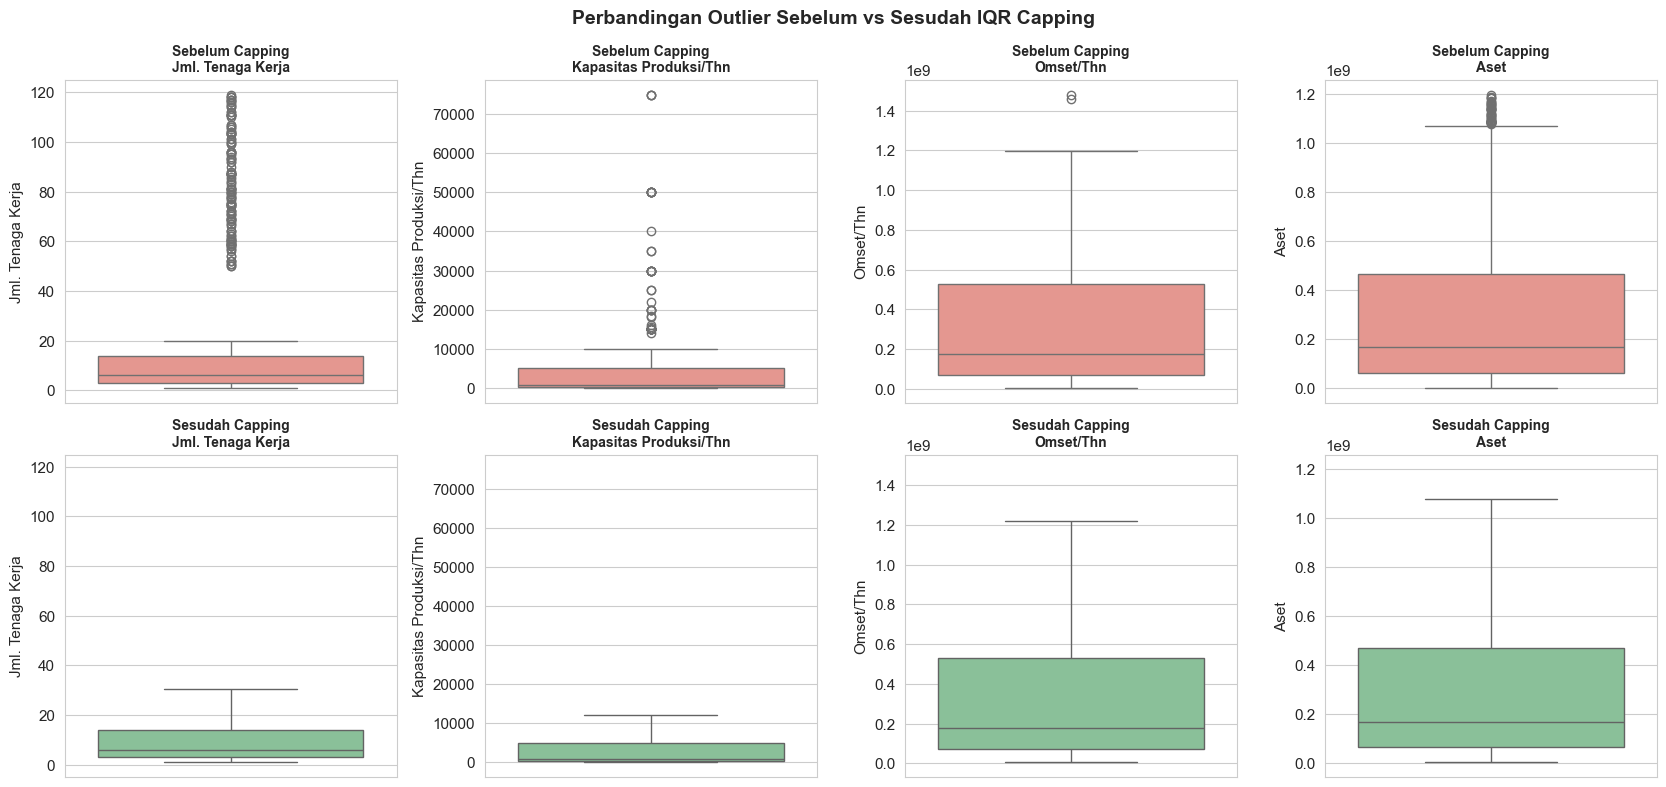

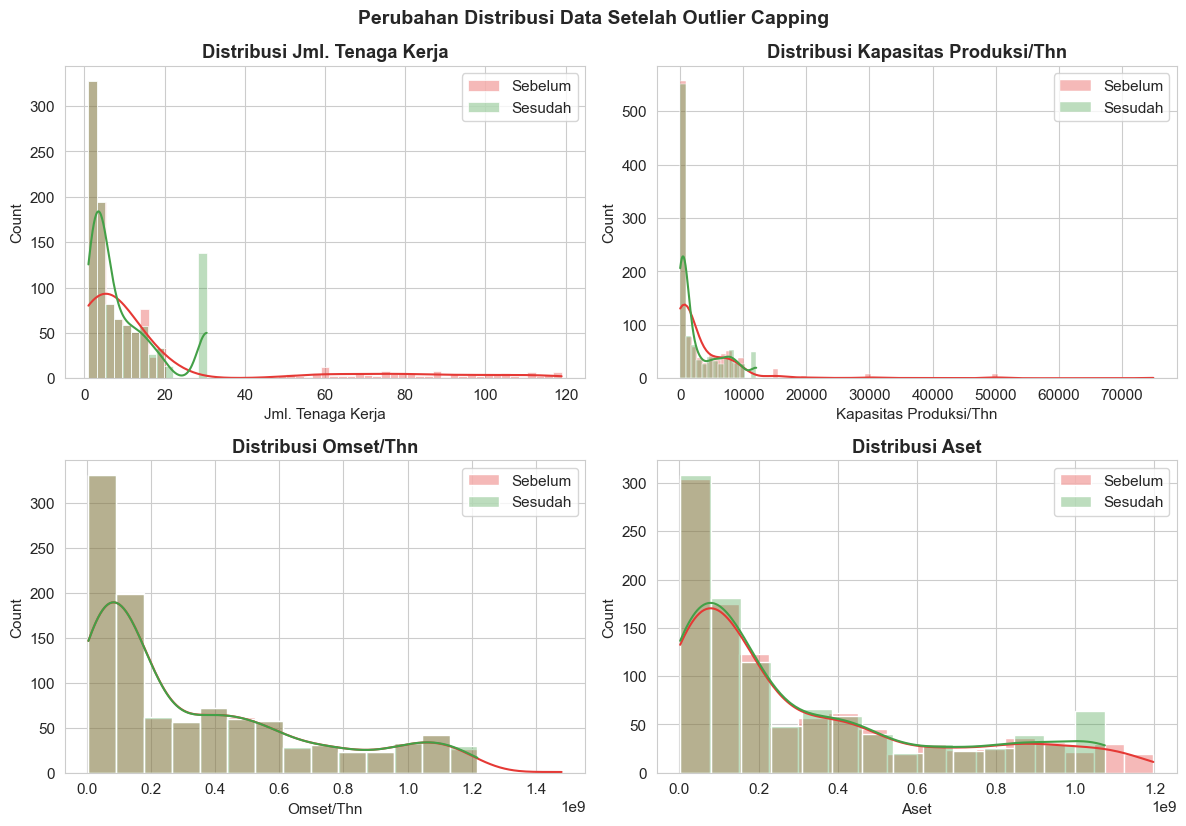

Ringkasan jumlah outlier (acuan batas dari data sebelum capping):


,Kolom,Batas Bawah,Batas Atas,Outlier Sebelum,Outlier Sesudah
0,Jml. Tenaga Kerja,-13.5000,30.5000,138,0
1,Kapasitas Produksi/Thn,-6750.0000,12050.0000,49,0
2,Omset/Thn,-615625000.0000,1217375000.0000,2,0
3,Aset,-543250000.0000,1074750000.0000,39,0


In [10]:
# ============================================================
# VISUALISASI PENANGANAN OUTLIER (SEBELUM vs SESUDAH CAPPING)
# Syarat:
# - df_enc   : data sebelum outlier handling
# - df_clean : data sesudah outlier handling (hasil clip/capping)
# - OUTLIER_COLS (opsional). Jika belum ada, pakai default 4 kolom numerik.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fallback kolom outlier jika belum didefinisikan
if "OUTLIER_COLS" not in globals():
    OUTLIER_COLS = ["Jml. Tenaga Kerja", "Kapasitas Produksi/Thn", "Omset/Thn", "Aset"]

# Validasi variabel wajib
if "df_enc" not in globals() or "df_clean" not in globals():
    raise ValueError("df_enc atau df_clean belum tersedia. Jalankan cell preprocessing/handling outlier dulu.")

# Pastikan kolom tersedia di kedua dataframe
missing_cols = [c for c in OUTLIER_COLS if c not in df_enc.columns or c not in df_clean.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Kolom berikut tidak ditemukan di df_enc/df_clean: {missing_cols}")

sns.set_style("whitegrid")

# ------------------------------------------------------------
# 1) BOXPLOT: sebelum vs sesudah
# ------------------------------------------------------------
n_cols = len(OUTLIER_COLS)
fig, axes = plt.subplots(2, n_cols, figsize=(4.2 * n_cols, 8), sharey="col")

if n_cols == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, col in enumerate(OUTLIER_COLS):
    sns.boxplot(y=df_enc[col], ax=axes[0, i], color="#f28b82")
    axes[0, i].set_title(f"Sebelum Capping\n{col}", fontsize=10, fontweight="bold")
    axes[0, i].set_xlabel("")

    sns.boxplot(y=df_clean[col], ax=axes[1, i], color="#81c995")
    axes[1, i].set_title(f"Sesudah Capping\n{col}", fontsize=10, fontweight="bold")
    axes[1, i].set_xlabel("")

plt.suptitle("Perbandingan Outlier Sebelum vs Sesudah IQR Capping", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) HISTOGRAM OVERLAY: distribusi sebelum vs sesudah
# ------------------------------------------------------------
n = len(OUTLIER_COLS)
ncol = 2
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 4.2 * nrow))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(OUTLIER_COLS):
    sns.histplot(df_enc[col], kde=True, color="#e53935", alpha=0.35, label="Sebelum", ax=axes[i])
    sns.histplot(df_clean[col], kde=True, color="#43a047", alpha=0.35, label="Sesudah", ax=axes[i])
    axes[i].set_title(f"Distribusi {col}", fontweight="bold")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Perubahan Distribusi Data Setelah Outlier Capping", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) RINGKASAN JUMLAH OUTLIER: sebelum vs sesudah
# ------------------------------------------------------------
rows = []
for col in OUTLIER_COLS:
    q1 = df_enc[col].quantile(0.25)
    q3 = df_enc[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    out_before = ((df_enc[col] < lower) | (df_enc[col] > upper)).sum()
    out_after  = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    rows.append({
        "Kolom": col,
        "Batas Bawah": round(lower, 2),
        "Batas Atas": round(upper, 2),
        "Outlier Sebelum": int(out_before),
        "Outlier Sesudah": int(out_after)
    })

df_outlier_summary = pd.DataFrame(rows)
print("Ringkasan jumlah outlier (acuan batas dari data sebelum capping):")
display(df_outlier_summary)

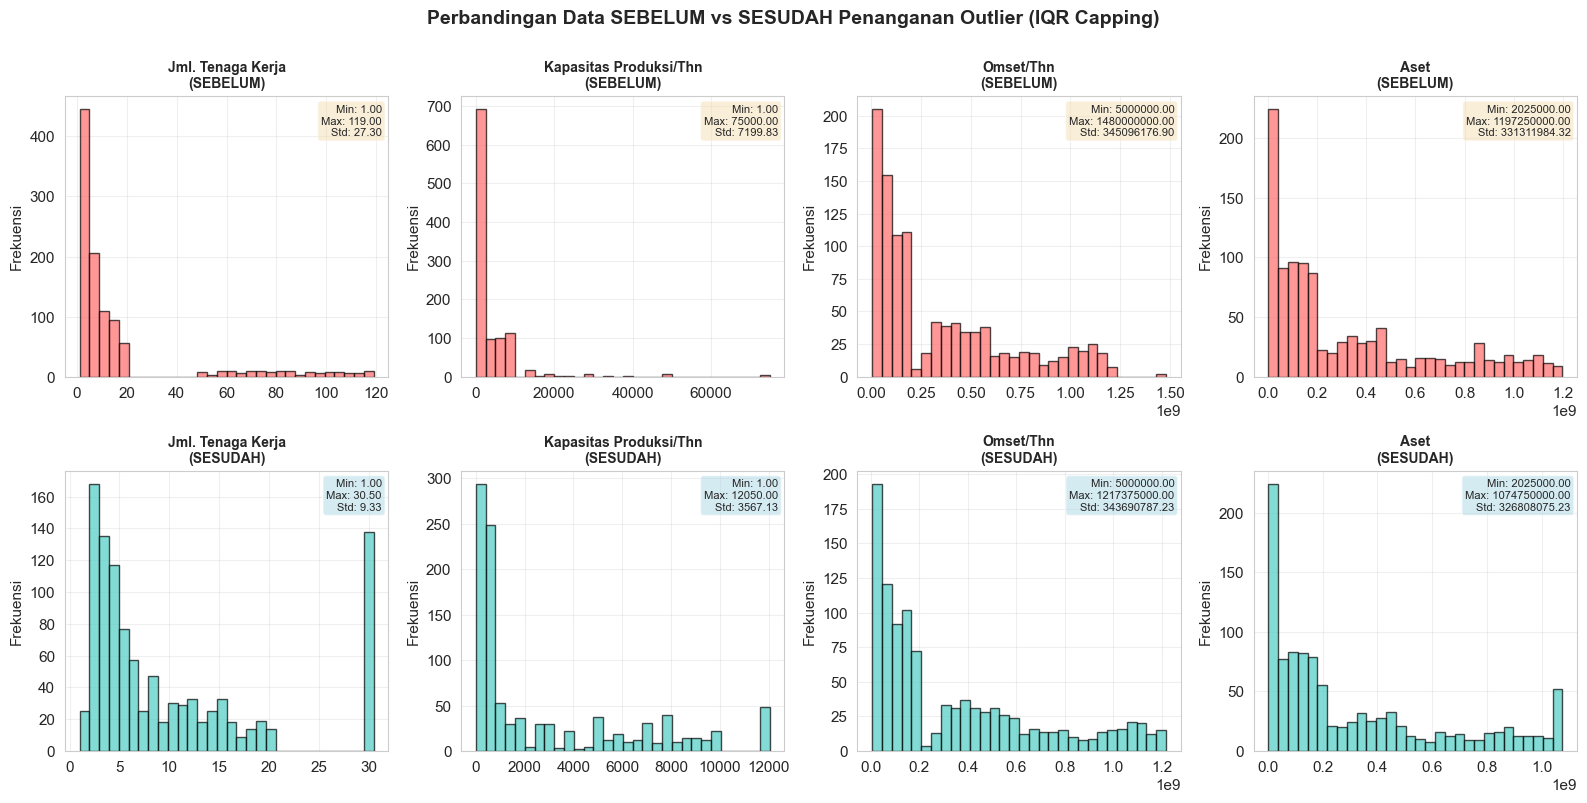

OK Visualisasi outlier before-after berhasil ditampilkan.

PERBANDINGAN STATISTIK SEBELUM DAN SESUDAH PENANGANAN OUTLIER

Perubahan Mean:
   Jml. Tenaga Kerja        :      16.77 ->       9.83 (Delta -6.94, -41.4%)
   Kapasitas Produksi/Thn   :    3614.91 ->    2858.43 (Delta -756.48, -20.9%)
   Omset/Thn                : 340188822.69 -> 339707173.50 (Delta -481649.19, -0.1%)
   Aset                     : 317865181.12 -> 316004122.97 (Delta -1861058.15, -0.6%)

Perubahan Std Dev:
   Jml. Tenaga Kerja        :      27.30 ->       9.33 (Delta -17.97, -65.8%)
   Kapasitas Produksi/Thn   :    7199.83 ->    3567.13 (Delta -3632.71, -50.5%)
   Omset/Thn                : 345096176.90 -> 343690787.23 (Delta -1405389.68, -0.4%)
   Aset                     : 331311984.32 -> 326808075.23 (Delta -4503909.09, -1.4%)


In [11]:
# ============================================================
# CELL 6B: VISUALISASI OUTLIER SEBELUM vs SESUDAH CAPPING
# Menampilkan perbandingan distribusi data sebelum dan sesudah
# penanganan outlier dengan capping method
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Perbandingan Data SEBELUM vs SESUDAH Penanganan Outlier (IQR Capping)', 
             fontsize=14, fontweight='bold', y=1.00)

for idx, col in enumerate(OUTLIER_COLS):
    ax_before = axes[0, idx]
    ax_after = axes[1, idx]
    
    # Before
    ax_before.hist(df_before_outlier[col], bins=30, color='#FF6B6B', alpha=0.7, edgecolor='black')
    ax_before.set_title(f'{col}\n(SEBELUM)', fontweight='bold', fontsize=10)
    ax_before.set_ylabel('Frekuensi')
    ax_before.grid(True, alpha=0.3)
    
    # After
    ax_after.hist(df_clean[col], bins=30, color='#4ECDC4', alpha=0.7, edgecolor='black')
    ax_after.set_title(f'{col}\n(SESUDAH)', fontweight='bold', fontsize=10)
    ax_after.set_ylabel('Frekuensi')
    ax_after.grid(True, alpha=0.3)
    
    # Add statistics
    stats_before = f"Min: {df_before_outlier[col].min():.2f}\nMax: {df_before_outlier[col].max():.2f}\nStd: {df_before_outlier[col].std():.2f}"
    stats_after = f"Min: {df_clean[col].min():.2f}\nMax: {df_clean[col].max():.2f}\nStd: {df_clean[col].std():.2f}"
    
    ax_before.text(0.98, 0.97, stats_before, transform=ax_before.transAxes,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)
    ax_after.text(0.98, 0.97, stats_after, transform=ax_after.transAxes,
                  verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5), fontsize=8)

plt.tight_layout()
plt.savefig('outlier_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("OK Visualisasi outlier before-after berhasil ditampilkan.")

# Tabel perbandingan statistik
print("\n" + "="*70)
print("PERBANDINGAN STATISTIK SEBELUM DAN SESUDAH PENANGANAN OUTLIER")
print("="*70)

stats_comparison = []
for col in OUTLIER_COLS:
    stats_comparison.append({
        'Kolom': col,
        'Mean (Sebelum)': df_before_outlier[col].mean(),
        'Mean (Sesudah)': df_clean[col].mean(),
        'Std (Sebelum)': df_before_outlier[col].std(),
        'Std (Sesudah)': df_clean[col].std(),
        'Min (Sebelum)': df_before_outlier[col].min(),
        'Min (Sesudah)': df_clean[col].min(),
        'Max (Sebelum)': df_before_outlier[col].max(),
        'Max (Sesudah)': df_clean[col].max(),
    })

df_stats_comp = pd.DataFrame(stats_comparison)
print("\nPerubahan Mean:")
for idx, row in df_stats_comp.iterrows():
    change = row['Mean (Sesudah)'] - row['Mean (Sebelum)']
    pct_change = (change / row['Mean (Sebelum)'] * 100) if row['Mean (Sebelum)'] != 0 else 0
    print(f"   {row['Kolom']:25s}: {row['Mean (Sebelum)']:10.2f} -> {row['Mean (Sesudah)']:10.2f} (Delta {change:+.2f}, {pct_change:+.1f}%)")

print("\nPerubahan Std Dev:")
for idx, row in df_stats_comp.iterrows():
    change = row['Std (Sesudah)'] - row['Std (Sebelum)']
    pct_change = (change / row['Std (Sebelum)'] * 100) if row['Std (Sebelum)'] != 0 else 0
    print(f"   {row['Kolom']:25s}: {row['Std (Sebelum)']:10.2f} -> {row['Std (Sesudah)']:10.2f} (Delta {change:+.2f}, {pct_change:+.1f}%)")

In [12]:
# ============================================================
# CELL 7: PREPROCESSING MIN-MAX SCALING NORMALISASI
# Data dinormalisasi dengan MinMaxScaler (range 0-1)
# untuk kebutuhan clustering CLARA dan Entropy Weight Method
# df_prepared = dataset siap analisis (encoded + clean)
# X_scaled    = array fitur hasil normalisasi MinMax
# df_scaled   = DataFrame hasil normalisasi
# ============================================================

from sklearn.preprocessing import MinMaxScaler

feature_names = FEATURE_COLS.copy()

# Ambil data numerik
X_raw = df_clean[feature_names].values.astype(float)

# Min-Max Scaling (0-1 range)
scaler   = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_raw)

# DataFrame hasil scaling (untuk analisis & visualisasi)
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
df_scaled.insert(0, 'Identitas_UMKM', df_clean['Identitas_UMKM'].values)

# Dataset sebelum scaling (untuk referensi / pembobotan)
df_prepared = df_clean.copy()

print("OK MinMaxScaler selesai (range 0-1).")
print("   Catatan: Metode normalisasi yang digunakan HANYA Min-Max Scaling")
print("           untuk semua proses (clustering & entropy).\n")

print("Statistik X_scaled (MinMax - range 0 hingga 1):")
display(df_scaled[feature_names].describe().round(4))

print(f"\ndf_prepared: {df_prepared.shape[0]} baris x {df_prepared.shape[1]} kolom")
display(df_prepared.head())

OK MinMaxScaler selesai (range 0-1).
   Catatan: Metode normalisasi yang digunakan HANYA Min-Max Scaling
           untuk semua proses (clustering & entropy).

Statistik X_scaled (MinMax - range 0 hingga 1):


,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
count,1049.0000,1049.0000,1049.0000,1049.0000,1049.0000,1049.0000,1049.0000,1049.0000
mean,0.9514,0.2993,0.2372,0.2761,0.2927,0.3759,0.3751,0.8418
std,0.2152,0.3164,0.2961,0.2835,0.3047,0.1907,0.2493,0.3651
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,1.0000,0.0678,0.0248,0.0551,0.0573,0.3333,0.0000,1.0000
50%,1.0000,0.1695,0.0622,0.1413,0.1547,0.3333,0.5000,1.0000
75%,1.0000,0.4407,0.4149,0.4330,0.4344,0.3333,0.5000,1.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



df_prepared: 1049 baris x 9 kolom


,Identitas_UMKM,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
0,Owner-0001 - MSME-0001,1,8.0000,5000,22250000,13000000,2,1,1
1,Owner-0002 - MSME-0002,1,5.0000,170,81250000,132750000,1,1,1
2,Owner-0003 - MSME-0003,1,4.0000,3000,6250000,27250000,2,1,1
3,Owner-0004 - MSME-0004,1,2.0000,1500,27750000,29250000,1,1,1
4,Owner-0005 - MSME-0003,1,3.0000,550,54750000,92000000,0,1,1


In [13]:
# ============================================================
# TAMPILKAN HASIL NORMALISASI MINMAX
# Syarat: X_raw sudah ada (dibuat di tahap preprocessing)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Validasi variabel wajib
if "X_raw" not in globals():
    raise ValueError("X_raw belum ada. Jalankan preprocessing hingga pembentukan X_raw.")

# Nama fitur
if "feature_names" in globals():
    cols = feature_names
elif "FEATURE_COLS" in globals():
    cols = FEATURE_COLS
else:
    cols = [f"Fitur_{i+1}" for i in range(X_raw.shape[1])]

# MinMax normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

# DataFrame hasil normalisasi
df_scaled_norm = pd.DataFrame(X_scaled, columns=cols)

# Jika ada identitas UMKM, tampilkan juga
if "df_clean" in globals() and "Identitas_UMKM" in df_clean.columns and len(df_clean) == len(df_scaled_norm):
    df_scaled_norm.insert(0, "Identitas_UMKM", df_clean["Identitas_UMKM"].values)

print("✅ Normalisasi MinMax selesai.")
print("\n📊 Preview data hasil normalisasi (10 baris):")
display(df_scaled_norm.head(10))

print("\n📈 Statistik hasil normalisasi:")
display(df_scaled_norm[cols].describe().T)

# Cek min dan max tiap fitur (harus di rentang 0–1)
df_range_check = pd.DataFrame({
    "Feature": cols,
    "Min": df_scaled_norm[cols].min().values,
    "Max": df_scaled_norm[cols].max().values
})
print("\n🔎 Cek rentang Min-Max per fitur:")
display(df_range_check)

✅ Normalisasi MinMax selesai.

📊 Preview data hasil normalisasi (10 baris):


,Identitas_UMKM,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
0,Owner-0001 - MSME-0001,1.0000,0.2373,0.4149,0.0142,0.0102,0.6667,0.5000,1.0000
1,Owner-0002 - MSME-0002,1.0000,0.1356,0.0140,0.0629,0.1219,0.3333,0.5000,1.0000
2,Owner-0003 - MSME-0003,1.0000,0.1017,0.2489,0.0010,0.0235,0.6667,0.5000,1.0000
3,Owner-0004 - MSME-0004,1.0000,0.0339,0.1244,0.0188,0.0254,0.3333,0.5000,1.0000
4,Owner-0005 - MSME-0003,1.0000,0.0678,0.0456,0.0410,0.0839,0.0000,0.5000,1.0000
5,Owner-0006 - MSME-0005,1.0000,0.0678,0.4149,0.1505,0.1538,0.3333,0.5000,1.0000
6,Owner-0007 - MSME-0005,1.0000,0.0678,0.6639,0.0039,0.0100,0.3333,0.5000,1.0000
7,Owner-0008 - MSME-0006,1.0000,0.1017,0.0497,0.0412,0.1484,0.3333,0.0000,1.0000
8,Owner-0009 - MSME-0006,1.0000,0.2712,0.0829,0.0134,0.0258,0.6667,0.0000,1.0000
9,Owner-0010 - MSME-0007,1.0000,0.0339,0.0360,0.0004,0.0163,0.6667,0.5000,1.0000



📈 Statistik hasil normalisasi:


,count,mean,std,min,25%,50%,75%,max
NIB/SKU,1049.0000,0.9514,0.2152,0.0000,1.0000,1.0000,1.0000,1.0000
Jml. Tenaga Kerja,1049.0000,0.2993,0.3164,0.0000,0.0678,0.1695,0.4407,1.0000
Kapasitas Produksi/Thn,1049.0000,0.2372,0.2961,0.0000,0.0248,0.0622,0.4149,1.0000
Omset/Thn,1049.0000,0.2761,0.2835,0.0000,0.0551,0.1413,0.4330,1.0000
Aset,1049.0000,0.2927,0.3047,0.0000,0.0573,0.1547,0.4344,1.0000
Sosmed,1049.0000,0.3759,0.1907,0.0000,0.3333,0.3333,0.3333,1.0000
Marketplace,1049.0000,0.3751,0.2493,0.0000,0.0000,0.5000,0.5000,1.0000
Kepemilikan Lahan,1049.0000,0.8418,0.3651,0.0000,1.0000,1.0000,1.0000,1.0000



🔎 Cek rentang Min-Max per fitur:


,Feature,Min,Max
0,NIB/SKU,0.0000,1.0000
1,Jml. Tenaga Kerja,0.0000,1.0000
2,Kapasitas Produksi/Thn,0.0000,1.0000
3,Omset/Thn,0.0000,1.0000
4,Aset,0.0000,1.0000
5,Sosmed,0.0000,1.0000
6,Marketplace,0.0000,1.0000
7,Kepemilikan Lahan,0.0000,1.0000


In [14]:
# ============================================================
# CELL TAMBAHAN: EXPORT PREPROCESSING KE EXCEL
# ============================================================
# Instruksi:
# 1. Copy seluruh kode di bawah
# 2. Paste di notebook Anda (tambah cell baru)
# 3. Pastikan nama variable sesuai dengan notebook Anda
# 4. Jalankan cell
# ============================================================

import pandas as pd
import os
from pathlib import Path
from datetime import datetime

# ─────────────────────────────────────────────────────────────────
# FUNGSI EXPORT KE EXCEL
# ─────────────────────────────────────────────────────────────────

def export_preprocessing_to_excel(
    df_original,
    df_preprocessing,
    filename="hasil_preprocessing.xlsx",
    output_path=None,
    auto_download=True
):
    """
    Export hasil preprocessing ke Excel dengan 2 sheet.
    
    Parameter:
    - df_original: DataFrame sebelum preprocessing
    - df_preprocessing: DataFrame setelah preprocessing
    - filename: nama file output
    - output_path: path folder penyimpanan (default: current directory)
    - auto_download: auto-download jika di Google Colab
    """
    
    try:
        # Tentukan path output
        if output_path is None:
            output_path = os.getcwd()
        
        Path(output_path).mkdir(parents=True, exist_ok=True)
        file_path = os.path.join(output_path, filename)
        
        # Cek file existing
        if os.path.exists(file_path):
            print(f"⚠️  File '{filename}' sudah ada, akan ditimpa...")
            os.remove(file_path)
        
        # Export ke Excel dengan 2 sheet
        with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
            # Sheet 1: Data Original
            df_original.to_excel(
                writer,
                sheet_name='Data_Original',
                index=False
            )
            
            # Sheet 2: Data Preprocessing
            df_preprocessing.to_excel(
                writer,
                sheet_name='Data_Preprocessing',
                index=False
            )
            
            # Format Excel (opsional)
            try:
                from openpyxl.styles import Font, PatternFill, Alignment
                from openpyxl.utils import get_column_letter
                
                workbook = writer.book
                
                for sheet_name in ['Data_Original', 'Data_Preprocessing']:
                    worksheet = workbook[sheet_name]
                    
                    # Format header
                    header_fill = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
                    header_font = Font(bold=True, color="FFFFFF", size=11)
                    
                    for cell in worksheet[1]:
                        cell.fill = header_fill
                        cell.font = header_font
                        cell.alignment = Alignment(horizontal="center", vertical="center")
                    
                    # Auto-adjust column width
                    for col_num, column_cells in enumerate(worksheet.columns, 1):
                        max_length = 0
                        column_letter = get_column_letter(col_num)
                        
                        for cell in column_cells:
                            try:
                                if len(str(cell.value)) > max_length:
                                    max_length = len(str(cell.value))
                            except:
                                pass
                        
                        adjusted_width = min(max_length + 2, 50)
                        worksheet.column_dimensions[column_letter].width = adjusted_width
                    
                    # Center alignment untuk data
                    for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row):
                        for cell in row:
                            cell.alignment = Alignment(horizontal="center", vertical="center")
                            
            except:
                pass  # Jika openpyxl tidak tersedia untuk styling
        
        # Info hasil export
        file_size = os.path.getsize(file_path) / 1024
        
        print("\n" + "="*70)
        print("✅ EXPORT BERHASIL!")
        print("="*70)
        print(f"📁 Nama file       : {filename}")
        print(f"📂 Lokasi          : {file_path}")
        print(f"💾 Ukuran file     : {file_size:.2f} KB")
        print(f"⏰ Waktu export    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"\n📊 Sheet tersimpan:")
        print(f"   • Data_Original: {len(df_original)} baris × {len(df_original.columns)} kolom")
        print(f"   • Data_Preprocessing: {len(df_preprocessing)} baris × {len(df_preprocessing.columns)} kolom")
        print("="*70)
        
        # Auto-download Colab
        if auto_download:
            try:
                from google.colab import files
                print("\n📥 Mengunduh file dari Google Colab...")
                files.download(file_path)
                print("✅ Download berhasil!")
            except ImportError:
                pass
        
        return file_path
    
    except Exception as e:
        print(f"❌ ERROR: {e}")
        import traceback
        traceback.print_exc()
        return None


# ─────────────────────────────────────────────────────────────────
# JALANKAN EXPORT
# ─────────────────────────────────────────────────────────────────

# ⚠️  PERHATIAN: Sesuaikan nama variable di bawah dengan notebook Anda

# Contoh (ubah sesuai variable di notebook Anda):
export_preprocessing_to_excel(
    df_original=df,              # Variable data original
    df_preprocessing=df_scaled,  # Variable data preprocessing/normalisasi
    filename="hasil_preprocessing.xlsx",
    auto_download=True
)

# ─────────────────────────────────────────────────────────────────
# VARIASI PENGGUNAAN:
# ─────────────────────────────────────────────────────────────────

# Jika menggunakan variable berbeda:
# export_preprocessing_to_excel(df_original=df_enc, df_preprocessing=df_norm)

# Jika ingin menyimpan di folder khusus:
# export_preprocessing_to_excel(
#     df_original=df,
#     df_preprocessing=df_scaled,
#     filename="hasil_preprocessing.xlsx",
#     output_path="E:/hasil_export",
#     auto_download=True
# )

print("\n✨ Selesai! Cek file hasil_preprocessing.xlsx di folder project Anda.")


⚠️  File 'hasil_preprocessing.xlsx' sudah ada, akan ditimpa...

✅ EXPORT BERHASIL!
📁 Nama file       : hasil_preprocessing.xlsx
📂 Lokasi          : e:\SEMESTER 8 - SKRIPSI\PROGRAM IPYNB\MethodsX_Repro_NoImage\01_notebook\hasil_preprocessing.xlsx
💾 Ukuran file     : 164.93 KB
⏰ Waktu export    : 2026-06-26 01:30:19

📊 Sheet tersimpan:
   • Data_Original: 1056 baris × 17 kolom
   • Data_Preprocessing: 1049 baris × 9 kolom

✨ Selesai! Cek file hasil_preprocessing.xlsx di folder project Anda.


## 5. CLARA Baseline Clustering

**CLARA (Clustering Large Applications)** adalah algoritma clustering berbasis medoid yang robust terhadap outlier.

- Matriks jarak: **Gower Distance** (data campuran numerik + biner)
- Pengujian: **k = 2 sampai 10**
- Evaluasi: Silhouette Score + Davies Bouldin Index + Calinski-Harabasz Index
- k_best ditentukan dari skor gabungan Silhouette + DBI; CH dilaporkan sebagai metrik tambahan

In [15]:
# ============================================================
# CELL 8: FUNGSI GOWER DISTANCE
#
# compute_gower_matrix          : tanpa bobot (untuk Baseline)
# compute_gower_matrix_weighted : bobot diterapkan DI DALAM
#                                 formula Gower (untuk Weighted
#                                 dan Top-N)
#
# Formula Gower per fitur j:
#   Numerik : sij = |xi - xj| / Rj
#   Biner   : sij = 0 (sama) | 1 (berbeda)
#
# Formula Gower BERBOBOT:
#   d(i,j) = Σ wj * sij   (weights sum = 1)
#
# PENTING: Untuk Weighted/Top-N:
#   - Input X adalah X_scaled ASLI (TANPA pre-multiply)
#   - Bobot masuk ke dalam formula: dist += w * diff
# ============================================================

def compute_gower_matrix(X, feat_names, feat_types_dict):
    """
    Gower Distance tanpa bobot (untuk Baseline).
    d(i,j) = (1/p) * Σ sij
    """
    n, p        = X.shape
    ftypes      = [feat_types_dict.get(f, 'num') for f in feat_names]
    dist_matrix = np.zeros((n, n), dtype=float)

    for j, ftype in enumerate(ftypes):
        col = X[:, j]
        if ftype == 'num':
            rng  = col.max() - col.min()
            rng  = rng if rng > 0 else 1.0
            diff = np.abs(col[:, None] - col[None, :]) / rng
        else:
            diff = (col[:, None] != col[None, :]).astype(float)
        dist_matrix += diff

    dist_matrix /= p
    np.fill_diagonal(dist_matrix, 0.0)
    return dist_matrix


def compute_gower_matrix_weighted(X, feat_names, feat_types_dict, weights_dict):
    """
    Gower Distance BERBOBOT — bobot EWM diterapkan di dalam formula.
    d(i,j) = Σ wj * sij   (weights_dict harus sum = 1)

    PENTING: X harus X_scaled ASLI (bukan pre-multiplied).
    Bobot dimasukkan sebagai koefisien:  dist += w * diff
    """
    n, p        = X.shape
    ftypes      = [feat_types_dict.get(f, 'num') for f in feat_names]
    w_arr       = np.array([weights_dict.get(f, 1.0 / p) for f in feat_names])
    dist_matrix = np.zeros((n, n), dtype=float)

    for j, (ftype, w) in enumerate(zip(ftypes, w_arr)):
        col = X[:, j]
        if ftype == 'num':
            rng  = col.max() - col.min()
            rng  = rng if rng > 0 else 1.0
            diff = np.abs(col[:, None] - col[None, :]) / rng
        else:
            diff = (col[:, None] != col[None, :]).astype(float)
        dist_matrix += w * diff    # ← bobot diterapkan di sini

    np.fill_diagonal(dist_matrix, 0.0)
    return dist_matrix


# --- Hitung Gower Distance Baseline ---
print("⚙️  Menghitung Gower Distance Matrix (Baseline)...")
print(f"   Data: {X_scaled.shape[0]} observasi × {X_scaled.shape[1]} fitur")

gower_dist_baseline = compute_gower_matrix(X_scaled, feature_names, FEATURE_TYPES)

upper = gower_dist_baseline[np.triu_indices(len(gower_dist_baseline), k=1)]
print(f"✅ Selesai. Shape: {gower_dist_baseline.shape}")
print(f"   Min  : {upper.min():.4f}")
print(f"   Max  : {upper.max():.4f}")
print(f"   Mean : {upper.mean():.4f}")

⚙️  Menghitung Gower Distance Matrix (Baseline)...
   Data: 1049 observasi × 8 fitur
✅ Selesai. Shape: (1049, 1049)
   Min  : 0.0001
   Max  : 0.7805
   Mean : 0.2515


In [16]:
def clara_fit(dist_matrix, n_clusters, n_sampling_iter=120, random_state=42, debug=False):
    """
    Implementasi CLARA (Clustering Large Applications).

    Parameters
    ----------
    dist_matrix     : np.ndarray (n, n) — matriks jarak precomputed
    n_clusters      : int               — jumlah cluster k
    n_sampling_iter : int               — jumlah iterasi sampling
    random_state    : int               — seed reproduktibilitas
    debug           : bool              — tampilkan info debug (sample size)

    Returns
    -------
    best_labels  : np.ndarray (n,)
    best_medoids : np.ndarray (k,)
    """

    import numpy as np
    from sklearn_extra.cluster import KMedoids

    rng = np.random.RandomState(random_state)
    n   = dist_matrix.shape[0]

    # ============================================================
    # UKURAN SAMPLE (FIXED & ADAPTIF)
    # - 25% dari data
    # - minimal 50 + 5*k
    # ============================================================
    sample_size = max(int(0.25 * n), 50 + 5 * n_clusters)
    sample_size = min(sample_size, n)

    # DEBUG (opsional)
    if debug:
        print(f"[DEBUG] sample_size (k={n_clusters}): {sample_size}")

    best_cost    = np.inf
    best_labels  = None
    best_medoids = None

    # ============================================================
    # ITERASI SAMPLING CLARA
    # ============================================================
    for itr in range(n_sampling_iter):

        # Ambil sampel acak
        sample_idx  = rng.choice(n, size=sample_size, replace=False)
        sample_dist = dist_matrix[np.ix_(sample_idx, sample_idx)]

        # K-Medoids (PAM)
        kmed = KMedoids(
            n_clusters=n_clusters,
            metric='precomputed',
            method='pam',
            init='build',
            random_state=random_state + itr
        )
        kmed.fit(sample_dist)

        # Ambil medoid ke indeks asli
        medoid_indices = sample_idx[kmed.medoid_indices_]

        # Assign semua data ke medoid terdekat
        labels = np.argmin(dist_matrix[:, medoid_indices], axis=1)

        # Hitung total cost
        cost = np.sum([
            dist_matrix[i, medoid_indices[labels[i]]] for i in range(n)
        ])

        # Simpan solusi terbaik
        if cost < best_cost:
            best_cost    = cost
            best_labels  = labels.copy()
            best_medoids = medoid_indices.copy()

    return best_labels, best_medoids


# ============================================================
# CEK FUNGSI
# ============================================================
print("✅ Fungsi clara_fit() siap digunakan!")

✅ Fungsi clara_fit() siap digunakan!


In [17]:
import numpy as np

def davies_bouldin_gower(distance_matrix, labels, medoids):
    labels = np.array(labels)
    k = len(np.unique(labels))
    
    # Hitung S_i (intra-cluster distance ke medoid)
    S = np.zeros(k)
    for i in range(k):
        cluster_idx = np.where(labels == i)[0]
        medoid_idx = medoids[i]
        
        if len(cluster_idx) > 0:
            S[i] = np.mean(distance_matrix[cluster_idx][:, medoid_idx])
        else:
            S[i] = 0

    # Hitung DBI
    dbi = 0
    for i in range(k):
        max_ratio = 0
        for j in range(k):
            if i != j:
                Mij = distance_matrix[medoids[i], medoids[j]]
                
                if Mij == 0:
                    continue
                
                ratio = (S[i] + S[j]) / Mij
                max_ratio = max(max_ratio, ratio)
        
        dbi += max_ratio

    return dbi / k


def safe_calinski_harabasz(X_features, labels):
    """
    Menghitung Calinski-Harabasz Index dengan aman.
    CH harus dihitung dari feature matrix, bukan dari distance matrix.
    Semakin tinggi nilai CH, semakin baik separasi cluster.
    """
    labels = np.asarray(labels)
    n_samples = len(labels)
    n_clusters = len(np.unique(labels))

    if n_clusters <= 1 or n_clusters >= n_samples:
        return np.nan

    try:
        return calinski_harabasz_score(X_features, labels)
    except Exception:
        return np.nan


🔄 CLARA Baseline: k = 2 hingga 10

   k   Silhouette Score  Davies Bouldin Index    Calinski-Harabasz Index
------------------------------------------------------------------------------
k= 2             0.3086                2.0058                   261.6347
k= 3             0.3916                1.4331                   299.9791
k= 4             0.4183                1.2393                   357.7787
k= 5             0.3418                1.4411                   321.3318
k= 6             0.3207                1.4276                   300.1871
k= 7             0.3318                1.6370                   279.5559
k= 8             0.3002                1.3821                   254.5392
k= 9             0.3166                1.3628                   257.7128
k=10             0.2958                1.5458                   256.1853

📊 Tabel Evaluasi CLARA Baseline:


,Silhouette Score,Davies Bouldin Index,Calinski Harabasz Index
k,,,
2,0.3086,2.0058,261.6347
3,0.3916,1.4331,299.9791
4,0.4183,1.2393,357.7787
5,0.3418,1.4411,321.3318
6,0.3207,1.4276,300.1871
7,0.3318,1.6370,279.5559
8,0.3002,1.3821,254.5392
9,0.3166,1.3628,257.7128
10,0.2958,1.5458,256.1853


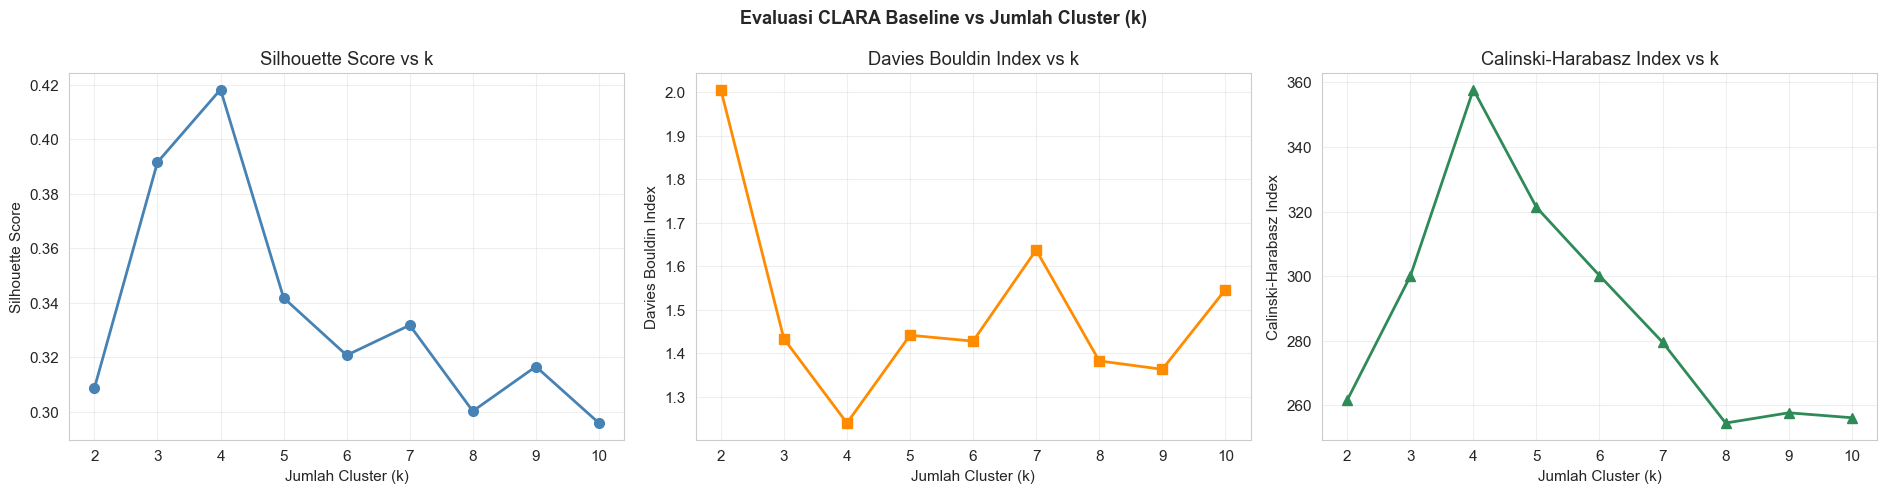

✅ Grafik evaluasi baseline berhasil ditampilkan.


In [18]:
# ============================================================
# CELL 10: CLARA BASELINE — Iterasi k = 2 sampai 10
# Untuk setiap k: hitung Silhouette Score, Davies Bouldin Index, dan Calinski-Harabasz Index
# Simpan ke df_evaluation
# ============================================================

k_range = range(2, 11)  # k = 2 sampai 10
results_baseline = {}

print("🔄 CLARA Baseline: k = 2 hingga 10\n")
print(f"{'k':>4}  {'Silhouette Score':>17}  {'Davies Bouldin Index':>20}  {'Calinski-Harabasz Index':>25}")
print("-" * 78)

for k in k_range:
    labels, medoids = clara_fit(gower_dist_baseline, n_clusters=k)

    if len(np.unique(labels)) > 1:
        sil = silhouette_score(gower_dist_baseline, labels, metric='precomputed')
        dbi = davies_bouldin_gower(gower_dist_baseline, labels, medoids)
        chi = safe_calinski_harabasz(X_scaled, labels)
    else:
        sil, dbi, chi = -1.0, np.nan, np.nan

    results_baseline[k] = {
        'labels'    : labels,
        'medoids'   : medoids,
        'silhouette': sil,
        'dbi'       : dbi,
        'chi'       : chi
    }
    print(f"k={k:2d}  {sil:>17.4f}  {dbi:>20.4f}  {chi:>25.4f}")

# Tabel evaluasi
df_evaluation = pd.DataFrame([
    {'k': k,
     'Silhouette Score'       : v['silhouette'],
     'Davies Bouldin Index'   : v['dbi'],
     'Calinski Harabasz Index': v['chi']}
    for k, v in results_baseline.items()
]).set_index('k')

print("\n📊 Tabel Evaluasi CLARA Baseline:")
display(df_evaluation)

# Visualisasi Silhouette, DBI, dan CH vs k
k_vals   = list(k_range)
sil_vals = [results_baseline[k]['silhouette'] for k in k_vals]
dbi_vals = [results_baseline[k]['dbi'] for k in k_vals]
chi_vals = [results_baseline[k]['chi'] for k in k_vals]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Evaluasi CLARA Baseline vs Jumlah Cluster (k)', fontsize=13, fontweight='bold')

ax1.plot(k_vals, sil_vals, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.set_xlabel('Jumlah Cluster (k)'); ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs k'); ax1.grid(True, alpha=0.3); ax1.set_xticks(k_vals)

ax2.plot(k_vals, dbi_vals, 's-', color='darkorange', linewidth=2, markersize=7)
ax2.set_xlabel('Jumlah Cluster (k)'); ax2.set_ylabel('Davies Bouldin Index')
ax2.set_title('Davies Bouldin Index vs k'); ax2.grid(True, alpha=0.3); ax2.set_xticks(k_vals)

ax3.plot(k_vals, chi_vals, '^-', color='seagreen', linewidth=2, markersize=7)
ax3.set_xlabel('Jumlah Cluster (k)'); ax3.set_ylabel('Calinski-Harabasz Index')
ax3.set_title('Calinski-Harabasz Index vs k'); ax3.grid(True, alpha=0.3); ax3.set_xticks(k_vals)

plt.tight_layout()
plt.savefig('evaluasi_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik evaluasi baseline berhasil ditampilkan.")


📊 Evaluasi Multi-Metric:


,Silhouette Score,Davies Bouldin Index,Calinski Harabasz Index,score
k,,,,
2,0.3086,2.0058,261.6347,0.0522
3,0.3916,1.4331,299.9791,0.7645
4,0.4183,1.2393,357.7787,1.0000
5,0.3418,1.4411,321.3318,0.5561
6,0.3207,1.4276,300.1871,0.4788
7,0.3318,1.6370,279.5559,0.3873
8,0.3002,1.3821,254.5392,0.4247
9,0.3166,1.3628,257.7128,0.5041
10,0.2958,1.5458,256.1853,0.3001



✅ k terbaik (gabungan Silhouette + DBI): k = 4

📊 Hasil CLARA Baseline (k=4):


,Identitas_UMKM,Cluster_Baseline
0,Owner-0001 - MSME-0001,1
1,Owner-0429 - MSME-0061,1
2,Owner-0431 - MSME-0205,1
3,Owner-0432 - MSME-0199,1
4,Owner-0434 - MSME-0206,1
5,Owner-0435 - MSME-0004,1
6,Owner-0436 - MSME-0004,1
7,Owner-0437 - MSME-0193,1
8,Owner-0440 - MSME-0004,1
9,Owner-0442 - MSME-0004,1



📦 Distribusi Cluster Baseline:
   Cluster 1: 496 UMKM  (47.3%)
   Cluster 2: 140 UMKM  (13.3%)
   Cluster 3: 285 UMKM  (27.2%)
   Cluster 4: 128 UMKM  (12.2%)


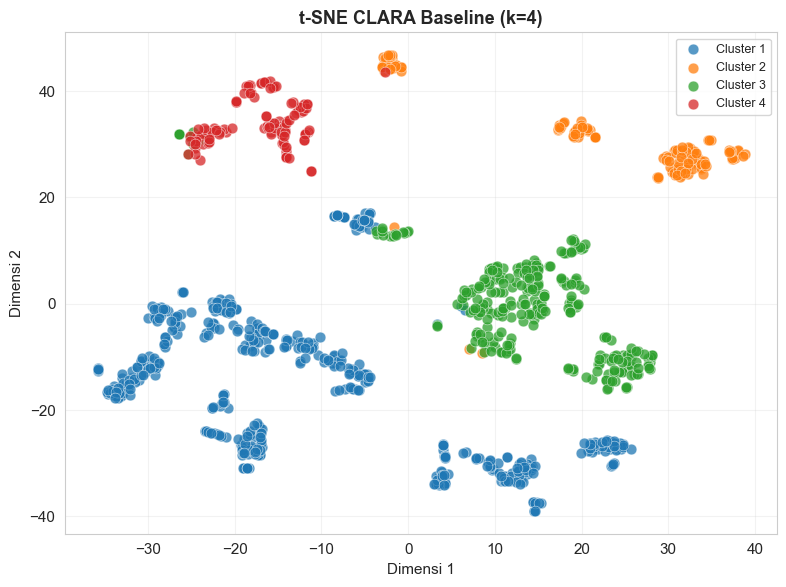

✅ t-SNE Baseline berhasil ditampilkan.


In [19]:
# ============================================================
# CELL 11: TENTUKAN k_best + BASELINE CLUSTERING FINAL + t-SNE
# k_best: ditentukan dari skor gabungan Silhouette + DBI; CH dilaporkan sebagai metrik tambahan
# df_cluster_baseline: hasil akhir dengan kolom Cluster_Baseline
# ============================================================

# ============================================================
# MULTI-METRIC (Silhouette + DBI; CH sebagai metrik tambahan)
# ============================================================

df_eval = df_evaluation.copy()

sil_min, sil_max = df_eval['Silhouette Score'].min(), df_eval['Silhouette Score'].max()
dbi_min, dbi_max = df_eval['Davies Bouldin Index'].min(), df_eval['Davies Bouldin Index'].max()

if np.isclose(sil_max - sil_min, 0):
    df_eval['sil_norm'] = 0.5
else:
    df_eval['sil_norm'] = (df_eval['Silhouette Score'] - sil_min) / (sil_max - sil_min)

if np.isclose(dbi_max - dbi_min, 0):
    df_eval['dbi_norm'] = 0.5
else:
    df_eval['dbi_norm'] = (dbi_max - df_eval['Davies Bouldin Index']) / (dbi_max - dbi_min)

df_eval['score'] = 0.5 * df_eval['sil_norm'] + 0.5 * df_eval['dbi_norm']
k_best = int(df_eval['score'].idxmax())

print("📊 Evaluasi Multi-Metric:")
display(df_eval[['Silhouette Score', 'Davies Bouldin Index', 'Calinski Harabasz Index', 'score']])

print(f"\n✅ k terbaik (gabungan Silhouette + DBI): k = {k_best}")

labels_baseline = results_baseline[k_best]['labels']

# df_cluster_baseline
df_cluster_baseline = pd.DataFrame({
    'Identitas_UMKM'  : df_scaled['Identitas_UMKM'].values,
    'Cluster_Baseline': labels_baseline + 1
}).sort_values('Cluster_Baseline').reset_index(drop=True)

print(f"\n📊 Hasil CLARA Baseline (k={k_best}):")
display(df_cluster_baseline.head(10))

print(f"\n📦 Distribusi Cluster Baseline:")
dist = df_cluster_baseline['Cluster_Baseline'].value_counts().sort_index()
for cid, cnt in dist.items():
    print(f"   Cluster {cid}: {cnt:3d} UMKM  ({cnt/len(df_cluster_baseline)*100:.1f}%)")

# --- t-SNE Visualisasi Baseline ---
perp   = min(30, max(5, len(X_scaled) // 3))
tsne   = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
X_2d   = tsne.fit_transform(X_scaled)
palette = sns.color_palette('tab10', n_colors=k_best)

plt.figure(figsize=(8, 6))
for cid in range(k_best):
    mask = labels_baseline == cid
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[cid]],
                s=60, alpha=0.75, edgecolors='white', linewidths=0.4,
                label=f'Cluster {cid+1}')
plt.title(f't-SNE CLARA Baseline (k={k_best})', fontsize=13, fontweight='bold')
plt.xlabel('Dimensi 1'); plt.ylabel('Dimensi 2')
plt.legend(loc='best', fontsize=9); plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('tsne_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE Baseline berhasil ditampilkan.")

## 6. Entropy Weight Method (EWM)

Menghitung bobot objektif setiap fitur berdasarkan tingkat diversifikasinya.

| Langkah | Rumus |
|---|---|
| Proporsi | $p_{ij} = x_{ij} / \sum_i x_{ij}$ |
| Entropy | $e_j = -k \sum_i p_{ij} \cdot \ln(p_{ij})$, &nbsp; $k = 1/\ln(n)$ |
| Diversifikasi | $d_j = 1 - e_j$ |
| Bobot | $w_j = d_j / \sum_j d_j$ |

📊 Tabel Entropy Weight Method (bobot terbesar → terkecil):



,Feature,Entropy,Diversification,Weight
0,Kapasitas Produksi/Thn,0.8972,0.1028,0.2424
1,Aset,0.9260,0.0740,0.1744
2,Omset/Thn,0.9271,0.0729,0.1719
3,Jml. Tenaga Kerja,0.9291,0.0709,0.1672
4,Marketplace,0.9506,0.0494,0.1165
5,Kepemilikan Lahan,0.9752,0.0248,0.0584
6,Sosmed,0.9778,0.0222,0.0524
7,NIB/SKU,0.9928,0.0072,0.0169



✅ Total bobot: 1.000000  (harus = 1.0)


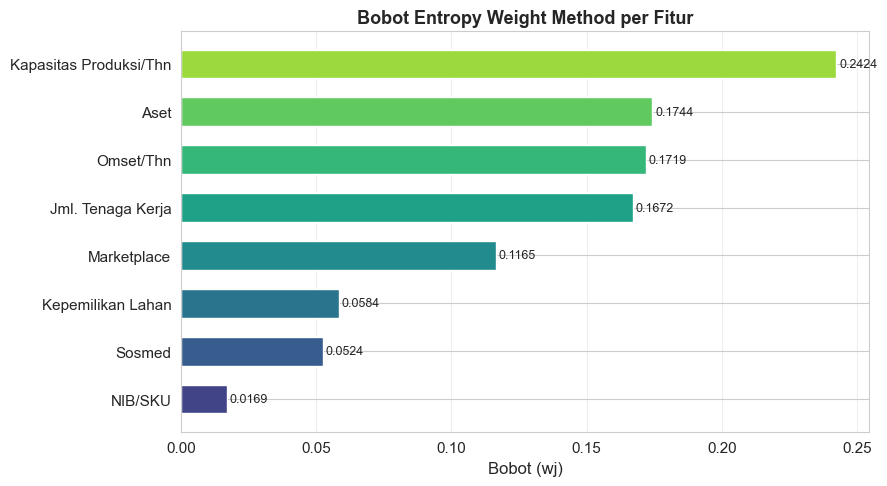

✅ Visualisasi bobot EWM berhasil ditampilkan.


In [20]:
# ============================================================
# CELL 12: ENTROPY WEIGHT METHOD (EWM)
# Input : X_ewm (hasil MinMaxScaler dari X_raw, khusus untuk EWM)
# Output: df_entropy_weights (Feature, Entropy, Diversification, Weight)
#         weights (dict {fitur: bobot})
#         sorted_features (list fitur, urutan bobot desc)
# Tidak ada pembulatan di tengah proses.
# ============================================================

# ============================================================
# DATA KHUSUS UNTUK EWM (WAJIB NON-NEGATIF)
# ============================================================

from sklearn.preprocessing import MinMaxScaler

scaler_ewm = MinMaxScaler()
X_ewm = scaler_ewm.fit_transform(X_raw)

def entropy_weight_method(X_norm, feat_names):
    """
    EWM: hitung bobot objektif tiap fitur berbasis Shannon Entropy.

    Parameters
    ----------
    X_norm     : np.ndarray (n, p) — data ternormalisasi [0, 1]
    feat_names : list[str]

    Returns
    -------
    df_ewm       : DataFrame kolom [Fitur, Entropy, Diversification, Weight]
    weights_dict : dict {fitur: bobot}
    """
    n, p    = X_norm.shape
    k_const = 1.0 / np.log(n)    # k = 1/ln(n)
    ej_list, dj_list = [], []

    for j in range(p):
        col     = X_norm[:, j]
        col_sum = col.sum()

        # Proporsi: pij = xij / Σxij
        pij = col / col_sum if col_sum > 0 else np.zeros(n)

        # Entropy: ej = -k * Σ(pij * ln(pij)), pij=0 → 0
        log_pij = np.where(pij > 0, np.log(pij), 0.0)
        ej      = float(np.clip(-k_const * np.sum(pij * log_pij), 0.0, 1.0))

        dj = 1.0 - ej
        ej_list.append(ej)
        dj_list.append(dj)

    sum_dj  = sum(dj_list)
    wj_list = [dj / sum_dj for dj in dj_list] if sum_dj > 0 else [1.0 / p] * p

    df_ewm = pd.DataFrame({
        'Feature'        : feat_names,
        'Entropy'        : ej_list,
        'Diversification': dj_list,
        'Weight'         : wj_list
    }).sort_values('Weight', ascending=False).reset_index(drop=True)

    return df_ewm, dict(zip(feat_names, wj_list))


df_entropy_weights, weights = entropy_weight_method(X_ewm, feature_names)

print("📊 Tabel Entropy Weight Method (bobot terbesar → terkecil):\n")
display(df_entropy_weights)
print(f"\n✅ Total bobot: {df_entropy_weights['Weight'].sum():.6f}  (harus = 1.0)")

sorted_features = df_entropy_weights['Feature'].tolist()
sorted_weights  = df_entropy_weights['Weight'].tolist()

# --- Visualisasi Bobot EWM ---
fig, ax = plt.subplots(figsize=(9, 5))
colors  = plt.cm.viridis(np.linspace(0.2, 0.85, len(sorted_features)))
rev_f   = sorted_features[::-1]
rev_w   = [weights[f] for f in rev_f]
bars    = ax.barh(rev_f, rev_w, color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Bobot (wj)', fontsize=12)
ax.set_title('Bobot Entropy Weight Method per Fitur', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, rev_w):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('bobot_ewm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi bobot EWM berhasil ditampilkan.")

In [21]:
# ============================================================
# TAMPILKAN HASIL NORMALISASI MINMAX UNTUK EWM
# Syarat: X_raw sudah ada (dibuat di tahap preprocessing)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Validasi variabel wajib
if "X_raw" not in globals():
    raise ValueError("X_raw belum ada. Jalankan dulu preprocessing sampai pembentukan X_raw.")

# Nama fitur
if "feature_names" in globals():
    cols = feature_names
elif "FEATURE_COLS" in globals():
    cols = FEATURE_COLS
else:
    cols = [f"Fitur_{i+1}" for i in range(X_raw.shape[1])]

# MinMax normalisasi untuk EWM
scaler_ewm = MinMaxScaler()
X_ewm = scaler_ewm.fit_transform(X_raw)

# DataFrame hasil normalisasi
df_ewm_norm = pd.DataFrame(X_ewm, columns=cols)

# Kalau ada identitas, tampilkan juga
if "df_clean" in globals() and "Identitas_UMKM" in df_clean.columns and len(df_clean) == len(df_ewm_norm):
    df_ewm_norm.insert(0, "Identitas_UMKM", df_clean["Identitas_UMKM"].values)

print("✅ Normalisasi MinMax untuk EWM selesai.")
print("\n📊 Preview data hasil normalisasi (10 baris):")
display(df_ewm_norm.head(10))

print("\n📈 Statistik hasil normalisasi:")
display(df_ewm_norm[cols].describe().T)

# Cek min dan max tiap fitur (harus di rentang 0-1)
df_range_check = pd.DataFrame({
    "Feature": cols,
    "Min": df_ewm_norm[cols].min().values,
    "Max": df_ewm_norm[cols].max().values
})

print("\n🔎 Cek rentang Min-Max per fitur:")
display(df_range_check)

# (Opsional) bandingkan data sebelum vs sesudah normalisasi untuk 5 baris pertama
df_before = pd.DataFrame(X_raw, columns=cols)
df_compare = pd.concat(
    [df_before.head(5).add_suffix(" (Before)"),
     df_ewm_norm[cols].head(5).add_suffix(" (After MinMax)")],
    axis=1
)
print("\n🆚 Perbandingan sebelum vs sesudah normalisasi (5 baris):")
display(df_compare)

✅ Normalisasi MinMax untuk EWM selesai.

📊 Preview data hasil normalisasi (10 baris):


,Identitas_UMKM,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
0,Owner-0001 - MSME-0001,1.0000,0.2373,0.4149,0.0142,0.0102,0.6667,0.5000,1.0000
1,Owner-0002 - MSME-0002,1.0000,0.1356,0.0140,0.0629,0.1219,0.3333,0.5000,1.0000
2,Owner-0003 - MSME-0003,1.0000,0.1017,0.2489,0.0010,0.0235,0.6667,0.5000,1.0000
3,Owner-0004 - MSME-0004,1.0000,0.0339,0.1244,0.0188,0.0254,0.3333,0.5000,1.0000
4,Owner-0005 - MSME-0003,1.0000,0.0678,0.0456,0.0410,0.0839,0.0000,0.5000,1.0000
5,Owner-0006 - MSME-0005,1.0000,0.0678,0.4149,0.1505,0.1538,0.3333,0.5000,1.0000
6,Owner-0007 - MSME-0005,1.0000,0.0678,0.6639,0.0039,0.0100,0.3333,0.5000,1.0000
7,Owner-0008 - MSME-0006,1.0000,0.1017,0.0497,0.0412,0.1484,0.3333,0.0000,1.0000
8,Owner-0009 - MSME-0006,1.0000,0.2712,0.0829,0.0134,0.0258,0.6667,0.0000,1.0000
9,Owner-0010 - MSME-0007,1.0000,0.0339,0.0360,0.0004,0.0163,0.6667,0.5000,1.0000



📈 Statistik hasil normalisasi:


,count,mean,std,min,25%,50%,75%,max
NIB/SKU,1049.0000,0.9514,0.2152,0.0000,1.0000,1.0000,1.0000,1.0000
Jml. Tenaga Kerja,1049.0000,0.2993,0.3164,0.0000,0.0678,0.1695,0.4407,1.0000
Kapasitas Produksi/Thn,1049.0000,0.2372,0.2961,0.0000,0.0248,0.0622,0.4149,1.0000
Omset/Thn,1049.0000,0.2761,0.2835,0.0000,0.0551,0.1413,0.4330,1.0000
Aset,1049.0000,0.2927,0.3047,0.0000,0.0573,0.1547,0.4344,1.0000
Sosmed,1049.0000,0.3759,0.1907,0.0000,0.3333,0.3333,0.3333,1.0000
Marketplace,1049.0000,0.3751,0.2493,0.0000,0.0000,0.5000,0.5000,1.0000
Kepemilikan Lahan,1049.0000,0.8418,0.3651,0.0000,1.0000,1.0000,1.0000,1.0000



🔎 Cek rentang Min-Max per fitur:


,Feature,Min,Max
0,NIB/SKU,0.0000,1.0000
1,Jml. Tenaga Kerja,0.0000,1.0000
2,Kapasitas Produksi/Thn,0.0000,1.0000
3,Omset/Thn,0.0000,1.0000
4,Aset,0.0000,1.0000
5,Sosmed,0.0000,1.0000
6,Marketplace,0.0000,1.0000
7,Kepemilikan Lahan,0.0000,1.0000



🆚 Perbandingan sebelum vs sesudah normalisasi (5 baris):


,NIB/SKU (Before),Jml. Tenaga Kerja (Before),Kapasitas Produksi/Thn (Before),Omset/Thn (Before),Aset (Before),Sosmed (Before),Marketplace (Before),Kepemilikan Lahan (Before),NIB/SKU (After MinMax),Jml. Tenaga Kerja (After MinMax),Kapasitas Produksi/Thn (After MinMax),Omset/Thn (After MinMax),Aset (After MinMax),Sosmed (After MinMax),Marketplace (After MinMax),Kepemilikan Lahan (After MinMax)
0,1.0000,8.0000,5000.0000,22250000.0000,13000000.0000,2.0000,1.0000,1.0000,1.0000,0.2373,0.4149,0.0142,0.0102,0.6667,0.5000,1.0000
1,1.0000,5.0000,170.0000,81250000.0000,132750000.0000,1.0000,1.0000,1.0000,1.0000,0.1356,0.0140,0.0629,0.1219,0.3333,0.5000,1.0000
2,1.0000,4.0000,3000.0000,6250000.0000,27250000.0000,2.0000,1.0000,1.0000,1.0000,0.1017,0.2489,0.0010,0.0235,0.6667,0.5000,1.0000
3,1.0000,2.0000,1500.0000,27750000.0000,29250000.0000,1.0000,1.0000,1.0000,1.0000,0.0339,0.1244,0.0188,0.0254,0.3333,0.5000,1.0000
4,1.0000,3.0000,550.0000,54750000.0000,92000000.0000,0.0000,1.0000,1.0000,1.0000,0.0678,0.0456,0.0410,0.0839,0.0000,0.5000,1.0000


In [22]:
# ============================================================
# CELL A: EWM STEP-BY-STEP (RINCI UNTUK DOSEN)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# 0) Validasi variabel wajib
# -----------------------------
if "feature_names" not in globals():
    raise ValueError("feature_names belum ada. Jalankan cell preprocessing sebelumnya.")

if "X_raw" not in globals():
    raise ValueError("X_raw belum ada. Jalankan cell preprocessing sebelumnya.")

# Jika X_ewm belum ada, buat otomatis
if "X_ewm" not in globals():
    scaler_ewm = MinMaxScaler()
    X_ewm = scaler_ewm.fit_transform(X_raw)

n, p = X_ewm.shape
k_const = 1.0 / np.log(n)

print("=" * 80)
print("EWM STEP-BY-STEP")
print("=" * 80)
print(f"Jumlah data (n): {n}")
print(f"Jumlah fitur (p): {p}")
print(f"Konstanta k = 1/ln(n): {k_const:.8f}")

# -----------------------------
# 1) Perhitungan per fitur
# -----------------------------
rows_summary = []
detail_tables = {}   # simpan tabel detail tiap fitur (opsional ditampilkan)

for j, feat in enumerate(feature_names):
    xj = X_ewm[:, j]
    sum_xj = np.sum(xj)

    # p_ij = x_ij / sum_i x_ij
    if sum_xj > 0:
        pij = xj / sum_xj
    else:
        pij = np.zeros_like(xj, dtype=float)

    # ln(p_ij), untuk p_ij = 0 dianggap 0 pada p_ij * ln(p_ij)
    ln_pij = np.where(pij > 0, np.log(pij), 0.0)
    pij_ln_pij = pij * ln_pij

    # e_j = -k * sum_i (p_ij * ln(p_ij))
    sum_term = np.sum(pij_ln_pij)
    ej = float(np.clip(-k_const * sum_term, 0.0, 1.0))

    # d_j = 1 - e_j
    dj = 1.0 - ej

    rows_summary.append({
        "Feature": feat,
        "sum_xij": sum_xj,
        "sum(pij*ln(pij))": sum_term,
        "Entropy_ej": ej,
        "Diversification_dj": dj
    })

    # Simpan detail tabel observasi
    detail_df = pd.DataFrame({
        "x_ij": xj,
        "p_ij": pij,
        "ln(p_ij)": ln_pij,
        "p_ij*ln(p_ij)": pij_ln_pij
    })
    detail_tables[feat] = detail_df

df_entropy_steps = pd.DataFrame(rows_summary)

# -----------------------------
# 2) Bobot akhir
# -----------------------------
sum_dj = df_entropy_steps["Diversification_dj"].sum()
if sum_dj > 0:
    df_entropy_steps["Weight_wj"] = df_entropy_steps["Diversification_dj"] / sum_dj
else:
    df_entropy_steps["Weight_wj"] = 1.0 / p

df_entropy_steps = df_entropy_steps.sort_values("Weight_wj", ascending=False).reset_index(drop=True)

print("\nTABEL RINGKAS EWM (SEMUA FITUR):")
display(df_entropy_steps)

print(f"Total bobot = {df_entropy_steps['Weight_wj'].sum():.8f} (harus 1.0)")

# -----------------------------
# 3) Detail langkah 1 fitur (untuk presentasi)
# -----------------------------
# Pilih fitur yang bobotnya terbesar agar mudah dijelaskan
feature_detail = df_entropy_steps.loc[0, "Feature"]

print("\n" + "-" * 80)
print(f"DETAIL PERHITUNGAN OBSERVASI UNTUK FITUR: {feature_detail}")
print("-" * 80)

df_detail = detail_tables[feature_detail].copy()
print("Preview 15 baris pertama:")
display(df_detail.head(15))

print("Ringkasan detail fitur:")
print(f"sum_xij            = {df_detail['x_ij'].sum():.8f}")
print(f"sum(p_ij)          = {df_detail['p_ij'].sum():.8f}")
print(f"sum(p_ij*ln(p_ij)) = {df_detail['p_ij*ln(p_ij)'].sum():.8f}")

# Cocokkan dengan tabel ringkas
row = df_entropy_steps[df_entropy_steps["Feature"] == feature_detail].iloc[0]
print(f"Entropy e_j        = {row['Entropy_ej']:.8f}")
print(f"Diversification d_j= {row['Diversification_dj']:.8f}")
print(f"Weight w_j         = {row['Weight_wj']:.8f}")

# Simpan variabel kompatibel dengan alur notebook kamu
df_entropy_weights = df_entropy_steps[["Feature", "Entropy_ej", "Diversification_dj", "Weight_wj"]].rename(
    columns={
        "Entropy_ej": "Entropy",
        "Diversification_dj": "Diversification",
        "Weight_wj": "Weight"
    }
)
weights = dict(zip(df_entropy_weights["Feature"], df_entropy_weights["Weight"]))
sorted_features = df_entropy_weights["Feature"].tolist()
sorted_weights = df_entropy_weights["Weight"].tolist()

print("\nSelesai: EWM step-by-step sudah ditampilkan lengkap.")

EWM STEP-BY-STEP
Jumlah data (n): 1049
Jumlah fitur (p): 8
Konstanta k = 1/ln(n): 0.14376920

TABEL RINGKAS EWM (SEMUA FITUR):


,Feature,sum_xij,sum(pij*ln(pij)),Entropy_ej,Diversification_dj,Weight_wj
0,Kapasitas Produksi/Thn,248.7713,-6.2402,0.8972,0.1028,0.2424
1,Aset,307.0350,-6.4411,0.9260,0.0740,0.1744
2,Omset/Thn,289.6033,-6.4484,0.9271,0.0729,0.1719
3,Jml. Tenaga Kerja,313.9661,-6.4623,0.9291,0.0709,0.1672
4,Marketplace,393.5000,-6.6119,0.9506,0.0494,0.1165
5,Kepemilikan Lahan,883.0000,-6.7833,0.9752,0.0248,0.0584
6,Sosmed,394.3333,-6.8010,0.9778,0.0222,0.0524
7,NIB/SKU,998.0000,-6.9058,0.9928,0.0072,0.0169


Total bobot = 1.00000000 (harus 1.0)

--------------------------------------------------------------------------------
DETAIL PERHITUNGAN OBSERVASI UNTUK FITUR: Kapasitas Produksi/Thn
--------------------------------------------------------------------------------
Preview 15 baris pertama:


,x_ij,p_ij,ln(p_ij),p_ij*ln(p_ij)
0,0.4149,0.0017,-6.3963,-0.0107
1,0.0140,0.0001,-9.7834,-0.0006
2,0.2489,0.0010,-6.9072,-0.0069
3,0.1244,0.0005,-7.6007,-0.0038
4,0.0456,0.0002,-8.6052,-0.0016
5,0.4149,0.0017,-6.3963,-0.0107
6,0.6639,0.0027,-5.9262,-0.0158
7,0.0497,0.0002,-8.5180,-0.0017
8,0.0829,0.0003,-8.0065,-0.0027
9,0.0360,0.0001,-8.8402,-0.0013


Ringkasan detail fitur:
sum_xij            = 248.77126733
sum(p_ij)          = 1.00000000
sum(p_ij*ln(p_ij)) = -6.24024027
Entropy e_j        = 0.89715436
Diversification d_j= 0.10284564
Weight w_j         = 0.24242960

Selesai: EWM step-by-step sudah ditampilkan lengkap.


## 8. CLARA Clustering Berbasis Fitur Berbobot

CLARA dijalankan menggunakan **Gower Distance berbobot** dari EWM.

- Bobot diterapkan **di dalam formula Gower**: $d(i,j) = \sum_j w_j \cdot s_{ij}$
- Menggunakan `k_best` dari Baseline — **tidak ada pengujian ulang k**

In [23]:
# ============================================================
# CELL 14: CLARA WEIGHTED
# Gower Distance berbobot dihitung dengan compute_gower_matrix_weighted.
# Input ke Gower: X_scaled ASLI (bukan X_weighted).
# Bobot masuk ke dalam formula: dist += w * diff.
# Menggunakan k_best — TIDAK ada pengujian ulang k.
# ============================================================

# Hitung Gower Distance Berbobot
# Input: X_scaled (asli), weights (dict hasil EWM, sum=1)
print(f"⚙️  Menghitung Gower Distance Berbobot (EWM)...")
gower_dist_weighted = compute_gower_matrix_weighted(
    X_scaled, feature_names, FEATURE_TYPES, weights
)
print(f"✅ Selesai. Shape: {gower_dist_weighted.shape}")

# Jalankan CLARA Weighted (k_best, tanpa uji ulang k)
print(f"\n🔄 Menjalankan CLARA Weighted (k={k_best})...")
labels_weighted, medoids_weighted = clara_fit(gower_dist_weighted, n_clusters=k_best)

# Evaluasi (dengan guard cluster tunggal)
# Silhouette & DBI: menggunakan distance matrix Gower berbobot
# CH: menggunakan feature matrix X_scaled, bukan distance matrix
if len(np.unique(labels_weighted)) > 1:
    sil_weighted = silhouette_score(gower_dist_weighted, labels_weighted, metric='precomputed')
    dbi_weighted = davies_bouldin_gower(gower_dist_weighted, labels_weighted, medoids_weighted)
    chi_weighted = safe_calinski_harabasz(X_scaled, labels_weighted)
else:
    sil_weighted, dbi_weighted, chi_weighted = -1.0, np.nan, np.nan

print(f"\n📊 Evaluasi CLARA Weighted (k={k_best}):")
print(f"   Silhouette Score          : {sil_weighted:.4f}")
print(f"   Davies Bouldin Index      : {dbi_weighted:.4f}")
print(f"   Calinski-Harabasz Index   : {chi_weighted:.4f}")

# Simpan hasil
df_cluster_weighted = pd.DataFrame({
    'Identitas_UMKM'   : df_scaled['Identitas_UMKM'].values,
    'Cluster_Weighted' : labels_weighted + 1
}).sort_values('Cluster_Weighted').reset_index(drop=True)

print(f"\n📦 Distribusi Cluster Weighted:")
dist = df_cluster_weighted['Cluster_Weighted'].value_counts().sort_index()
for cid, cnt in dist.items():
    print(f"   Cluster {cid}: {cnt:3d} UMKM  ({cnt/len(df_cluster_weighted)*100:.1f}%)")


⚙️  Menghitung Gower Distance Berbobot (EWM)...
✅ Selesai. Shape: (1049, 1049)

🔄 Menjalankan CLARA Weighted (k=4)...

📊 Evaluasi CLARA Weighted (k=4):
   Silhouette Score          : 0.4637
   Davies Bouldin Index      : 0.9258
   Calinski-Harabasz Index   : 253.9949

📦 Distribusi Cluster Weighted:
   Cluster 1: 523 UMKM  (49.9%)
   Cluster 2: 289 UMKM  (27.6%)
   Cluster 3: 144 UMKM  (13.7%)
   Cluster 4:  93 UMKM  (8.9%)


PENGUJIAN K OPTIMAL UNTUK CLARA WEIGHTED (EWM)

Menguji nilai k dari 2 hingga 10 untuk menemukan k optimal.
Menggunakan metrik evaluasi: Silhouette Score, Davies Bouldin Index, dan Calinski-Harabasz Index

   k   Silhouette Score  Davies Bouldin Index    Calinski-Harabasz Index
------------------------------------------------------------------------------


k= 2             0.4070                0.8426                   178.1001
k= 3             0.4589                1.0757                   296.2747
k= 4             0.4637                0.9258                   253.9949
k= 5             0.3574                1.3356                   230.0798
k= 6             0.3452                1.1965                   195.4725
k= 7             0.3160                1.4169                   172.9545
k= 8             0.3347                1.4981                   162.3985
k= 9             0.3221                1.3436                   144.2637
k=10             0.3159                1.3301                   133.9074

Tabel Evaluasi CLARA Weighted (k=2-10):


,Silhouette Score,Davies Bouldin Index,Calinski Harabasz Index
k,,,
2,0.4070,0.8426,178.1001
3,0.4589,1.0757,296.2747
4,0.4637,0.9258,253.9949
5,0.3574,1.3356,230.0798
6,0.3452,1.1965,195.4725
7,0.3160,1.4169,172.9545
8,0.3347,1.4981,162.3985
9,0.3221,1.3436,144.2637
10,0.3159,1.3301,133.9074


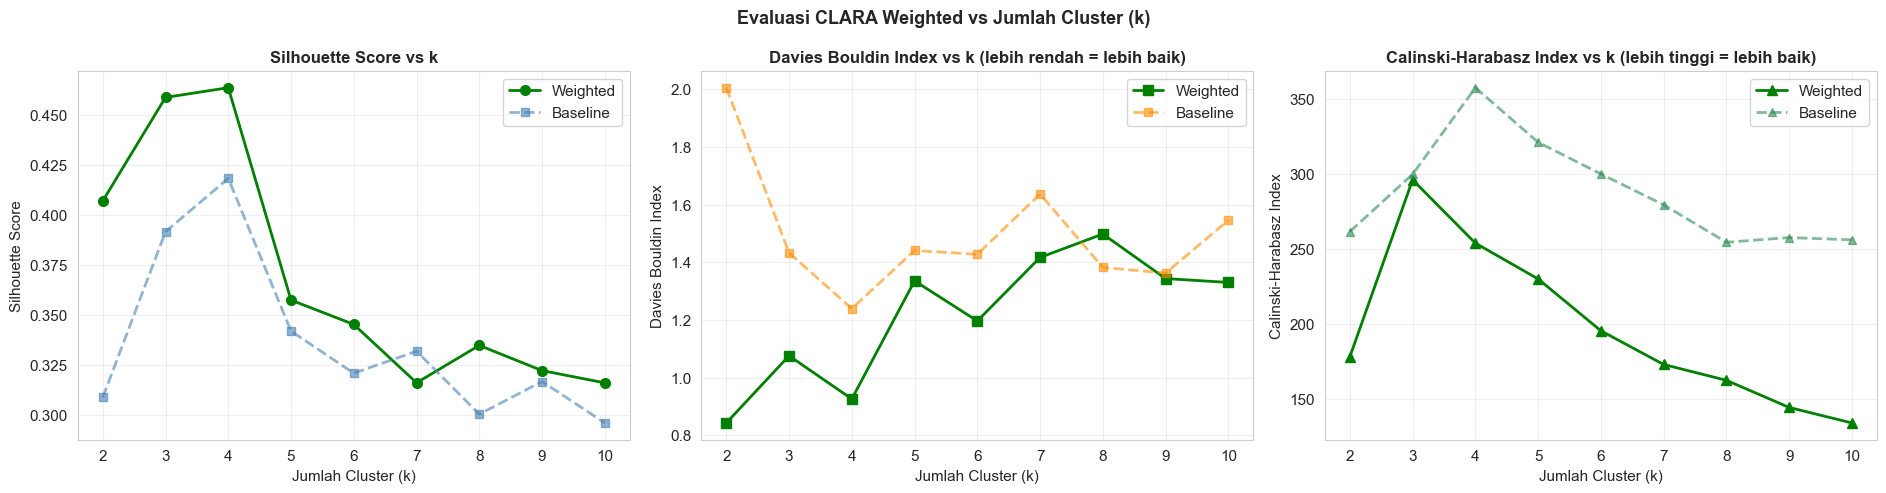


OK Grafik evaluasi CLARA Weighted berhasil ditampilkan.

📊 Evaluasi Multi-Metric CLARA Weighted:


,Silhouette Score,Davies Bouldin Index,Calinski Harabasz Index,score
k,,,,
2,0.4070,0.8426,178.1001,0.8082
3,0.4589,1.0757,296.2747,0.8057
4,0.4637,0.9258,253.9949,0.9366
5,0.3574,1.3356,230.0798,0.2641
6,0.3452,1.1965,195.4725,0.3290
7,0.3160,1.4169,172.9545,0.0620
8,0.3347,1.4981,162.3985,0.0635
9,0.3221,1.3436,144.2637,0.1386
10,0.3159,1.3301,133.9074,0.1281



✅ k optimal CLARA Weighted (SC + DBI): k = 4


In [24]:
# ============================================================
# CELL 14B: CLARA WEIGHTED K OPTIMAL TESTING (k=2 hingga 10)
# Testing k optimal untuk CLARA Weighted dengan Gower Distance berbobot
# Evaluasi: Silhouette Score, Davies Bouldin Index, dan Calinski-Harabasz Index
# ============================================================

print("=" * 70)
print("PENGUJIAN K OPTIMAL UNTUK CLARA WEIGHTED (EWM)")
print("=" * 70)
print("\nMenguji nilai k dari 2 hingga 10 untuk menemukan k optimal.")
print("Menggunakan metrik evaluasi: Silhouette Score, Davies Bouldin Index, dan Calinski-Harabasz Index\n")

k_range = range(2, 11)
results_weighted_kopt = {}

print(f"{'k':>4}  {'Silhouette Score':>17}  {'Davies Bouldin Index':>20}  {'Calinski-Harabasz Index':>25}")
print("-" * 78)

for k in k_range:
    labels_k, medoids_k = clara_fit(gower_dist_weighted, n_clusters=k)
    
    if len(np.unique(labels_k)) > 1:
        sil_k = silhouette_score(gower_dist_weighted, labels_k, metric='precomputed')
        dbi_k = davies_bouldin_gower(gower_dist_weighted, labels_k, medoids_k)
        chi_k = safe_calinski_harabasz(X_scaled, labels_k)
    else:
        sil_k, dbi_k, chi_k = -1.0, np.nan, np.nan
    
    results_weighted_kopt[k] = {
        'labels': labels_k,
        'medoids': medoids_k,
        'silhouette': sil_k,
        'dbi': dbi_k,
        'chi': chi_k
    }
    print(f"k={k:2d}  {sil_k:>17.4f}  {dbi_k:>20.4f}  {chi_k:>25.4f}")

# Tabel evaluasi
df_evaluation_weighted_kopt = pd.DataFrame([
    {'k': k,
     'Silhouette Score': v['silhouette'],
     'Davies Bouldin Index': v['dbi'],
     'Calinski Harabasz Index': v['chi']}
    for k, v in results_weighted_kopt.items()
]).set_index('k')

print("\nTabel Evaluasi CLARA Weighted (k=2-10):")
display(df_evaluation_weighted_kopt)

# Visualisasi: Silhouette, DBI, dan CH vs k
k_vals     = list(k_range)
sil_vals_w = [results_weighted_kopt[k]['silhouette'] for k in k_vals]
dbi_vals_w = [results_weighted_kopt[k]['dbi'] for k in k_vals]
chi_vals_w = [results_weighted_kopt[k]['chi'] for k in k_vals]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Evaluasi CLARA Weighted vs Jumlah Cluster (k)', fontsize=13, fontweight='bold')

# Plot Silhouette
ax1.plot(k_vals, sil_vals_w, 'o-', color='green', linewidth=2, markersize=7, label='Weighted')
sil_vals_b = [results_baseline[k]['silhouette'] for k in k_vals]
ax1.plot(k_vals, sil_vals_b, 's--', color='steelblue', linewidth=2, markersize=6, alpha=0.6, label='Baseline')
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=11)
ax1.set_ylabel('Silhouette Score', fontsize=11)
ax1.set_title('Silhouette Score vs k', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_vals)
ax1.legend(loc='best')

# Plot DBI
ax2.plot(k_vals, dbi_vals_w, 's-', color='green', linewidth=2, markersize=7, label='Weighted')
dbi_vals_b = [results_baseline[k]['dbi'] for k in k_vals]
ax2.plot(k_vals, dbi_vals_b, 's--', color='darkorange', linewidth=2, markersize=6, alpha=0.6, label='Baseline')
ax2.set_xlabel('Jumlah Cluster (k)', fontsize=11)
ax2.set_ylabel('Davies Bouldin Index', fontsize=11)
ax2.set_title('Davies Bouldin Index vs k (lebih rendah = lebih baik)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_vals)
ax2.legend(loc='best')

# Plot CH
ax3.plot(k_vals, chi_vals_w, '^-', color='green', linewidth=2, markersize=7, label='Weighted')
chi_vals_b = [results_baseline[k]['chi'] for k in k_vals]
ax3.plot(k_vals, chi_vals_b, '^--', color='seagreen', linewidth=2, markersize=6, alpha=0.6, label='Baseline')
ax3.set_xlabel('Jumlah Cluster (k)', fontsize=11)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=11)
ax3.set_title('Calinski-Harabasz Index vs k (lebih tinggi = lebih baik)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xticks(k_vals)
ax3.legend(loc='best')

plt.tight_layout()
plt.savefig('evaluasi_weighted_koptimal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOK Grafik evaluasi CLARA Weighted berhasil ditampilkan.")
# ============================================================
# MULTI-METRIC UNTUK CLARA WEIGHTED (SC + DBI; CH metrik tambahan)
# ============================================================

df_eval_w = df_evaluation_weighted_kopt.copy()

sil_min, sil_max = df_eval_w['Silhouette Score'].min(), df_eval_w['Silhouette Score'].max()
dbi_min, dbi_max = df_eval_w['Davies Bouldin Index'].min(), df_eval_w['Davies Bouldin Index'].max()

# Normalisasi SC
if np.isclose(sil_max - sil_min, 0):
    df_eval_w['sil_norm'] = 0.5
else:
    df_eval_w['sil_norm'] = (df_eval_w['Silhouette Score'] - sil_min) / (sil_max - sil_min)

# Normalisasi DBI (dibalik karena lebih kecil lebih baik)
if np.isclose(dbi_max - dbi_min, 0):
    df_eval_w['dbi_norm'] = 0.5
else:
    df_eval_w['dbi_norm'] = (dbi_max - df_eval_w['Davies Bouldin Index']) / (dbi_max - dbi_min)

# Score gabungan tetap SC + DBI agar konsisten dengan analisis sebelumnya
# CH hanya dilaporkan sebagai metrik tambahan.
df_eval_w['score'] = 0.5 * df_eval_w['sil_norm'] + 0.5 * df_eval_w['dbi_norm']

# Ambil k terbaik
k_opt_weighted = int(df_eval_w['score'].idxmax())

print("\n📊 Evaluasi Multi-Metric CLARA Weighted:")
display(df_eval_w[['Silhouette Score', 'Davies Bouldin Index', 'Calinski Harabasz Index', 'score']])

print(f"\n✅ k optimal CLARA Weighted (SC + DBI): k = {k_opt_weighted}")


In [25]:
# ============================================================
# CELL TAMBAHAN A: UTILITAS TRACE CLARA WEIGHTED + EXPLAIN GOWER
# ============================================================

import numpy as np
import pandas as pd
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

def explain_weighted_gower_pair(X, feat_names, feat_types_dict, weights_dict, i, j):
    """
    Menjelaskan perhitungan jarak Gower berbobot untuk 1 pasangan observasi (i, j).
    Output:
      - total_distance: nilai d(i,j)
      - detail_df: tabel kontribusi per fitur
    """
    n, p = X.shape
    rows = []
    total = 0.0

    for col_idx, f in enumerate(feat_names):
        xi = X[i, col_idx]
        xj = X[j, col_idx]
        ftype = feat_types_dict.get(f, "num")
        w = float(weights_dict.get(f, 1.0 / p))

        if ftype == "num":
            col = X[:, col_idx]
            rng = col.max() - col.min()
            rng = rng if rng > 0 else 1.0
            diff_norm = abs(xi - xj) / rng
        else:
            diff_norm = 0.0 if xi == xj else 1.0

        contrib = w * diff_norm
        total += contrib

        rows.append({
            "Feature": f,
            "Type": ftype,
            "x_i": xi,
            "x_j": xj,
            "Weight (w_j)": w,
            "s_ij (normalized diff)": diff_norm,
            "Contribution (w_j*s_ij)": contrib
        })

    detail_df = pd.DataFrame(rows).sort_values("Contribution (w_j*s_ij)", ascending=False).reset_index(drop=True)
    return total, detail_df


def clara_fit_with_trace(dist_matrix, n_clusters, n_sampling_iter=120, random_state=42):
    """
    CLARA dengan jejak iterasi:
    - menyimpan cost tiap iterasi
    - menyimpan medoid terbaik
    """
    rng = np.random.RandomState(random_state)
    n = dist_matrix.shape[0]

    sample_size = max(int(0.25 * n), 50 + 5 * n_clusters)
    sample_size = min(sample_size, n)

    best_cost = np.inf
    best_labels = None
    best_medoids = None
    trace_rows = []

    for itr in range(n_sampling_iter):
        sample_idx = rng.choice(n, size=sample_size, replace=False)
        sample_dist = dist_matrix[np.ix_(sample_idx, sample_idx)]

        kmed = KMedoids(
            n_clusters=n_clusters,
            metric="precomputed",
            method="pam",
            init="build",
            random_state=random_state + itr
        )
        kmed.fit(sample_dist)

        medoid_indices = sample_idx[kmed.medoid_indices_]
        labels = np.argmin(dist_matrix[:, medoid_indices], axis=1)

        cost = float(np.sum([dist_matrix[r, medoid_indices[labels[r]]] for r in range(n)]))

        trace_rows.append({
            "iterasi": itr + 1,
            "sample_size": sample_size,
            "cost": cost,
            "medoids_index": medoid_indices.tolist()
        })

        if cost < best_cost:
            best_cost = cost
            best_labels = labels.copy()
            best_medoids = medoid_indices.copy()

    trace_df = pd.DataFrame(trace_rows).sort_values("cost", ascending=True).reset_index(drop=True)
    return best_labels, best_medoids, best_cost, trace_df

In [26]:
# ============================================================
# CELL TAMBAHAN B: DEMO PROSES PERHITUNGAN + HASIL CLARA WEIGHTED
# ============================================================

# ---- Validasi variabel wajib ----
required_vars = [
    "X_scaled", "feature_names", "FEATURE_TYPES", "weights",
    "k_best", "df_scaled", "compute_gower_matrix_weighted",
    "davies_bouldin_gower"
]
missing = [v for v in required_vars if v not in globals()]
if len(missing) > 0:
    raise ValueError(f"Variabel berikut belum ada: {missing}. Jalankan cell sebelumnya terlebih dahulu.")

print("✅ Semua variabel wajib tersedia.")

# 1) Hitung ulang Gower berbobot (supaya eksplisit prosesnya)
gower_dist_weighted_demo = compute_gower_matrix_weighted(
    X_scaled, feature_names, FEATURE_TYPES, weights
)
print(f"\n📐 Gower berbobot selesai: shape = {gower_dist_weighted_demo.shape}")

# 2) Jalankan CLARA dengan trace iterasi
labels_w_demo, medoids_w_demo, best_cost_demo, trace_df = clara_fit_with_trace(
    gower_dist_weighted_demo,
    n_clusters=k_best,
    n_sampling_iter=120,
    random_state=42
)

sil_w_demo = silhouette_score(gower_dist_weighted_demo, labels_w_demo, metric="precomputed")
dbi_w_demo = davies_bouldin_gower(gower_dist_weighted_demo, labels_w_demo, medoids_w_demo)

print("\n🏁 HASIL CLARA WEIGHTED (dengan trace):")
print(f"   k                     : {k_best}")
print(f"   Best total cost       : {best_cost_demo:.6f}")
print(f"   Silhouette Score      : {sil_w_demo:.4f}")
print(f"   Davies Bouldin Index  : {dbi_w_demo:.4f}")

# 3) Tampilkan top iterasi terbaik
print("\n📊 Top-10 iterasi terbaik berdasarkan cost:")
display(trace_df.head(10))

# 4) Tampilkan medoid terbaik + identitas UMKM
df_medoid = pd.DataFrame({
    "Cluster": np.arange(1, len(medoids_w_demo) + 1),
    "Medoid Index": medoids_w_demo,
    "Identitas_UMKM": df_scaled.loc[medoids_w_demo, "Identitas_UMKM"].values
}).sort_values("Cluster").reset_index(drop=True)

print("\n🎯 Medoid terbaik per cluster:")
display(df_medoid)

# 5) Tabel assignment dan jarak ke medoid
dist_to_medoids = gower_dist_weighted_demo[:, medoids_w_demo]  # (n, k)
df_assign = pd.DataFrame({
    "Identitas_UMKM": df_scaled["Identitas_UMKM"].values,
    "Cluster": labels_w_demo + 1,
    "Distance_to_assigned_medoid": dist_to_medoids[np.arange(len(labels_w_demo)), labels_w_demo]
})

for c in range(dist_to_medoids.shape[1]):
    df_assign[f"d_to_medoid_{c+1}"] = dist_to_medoids[:, c]

print("\n🧾 Preview assignment (20 baris pertama):")
display(df_assign.head(20))

print("\n📦 Distribusi anggota cluster:")
display(df_assign["Cluster"].value_counts().sort_index().rename("Jumlah UMKM").to_frame())

# 6) Contoh detail perhitungan jarak berbobot untuk 2 pasangan observasi:
#    - pasangan paling dekat (non-diagonal)
#    - pasangan paling jauh
n = gower_dist_weighted_demo.shape[0]
tri_r, tri_c = np.triu_indices(n, k=1)
tri_vals = gower_dist_weighted_demo[tri_r, tri_c]

idx_min = np.argmin(tri_vals)  # pasangan terdekat
idx_max = np.argmax(tri_vals)  # pasangan terjauh

i_min, j_min = int(tri_r[idx_min]), int(tri_c[idx_min])
i_max, j_max = int(tri_r[idx_max]), int(tri_c[idx_max])

print("\n🔍 DETAIL PERHITUNGAN GOWER BERBOBOT (pasangan terdekat):")
print(f"   Observasi i={i_min}, j={j_min}, distance={gower_dist_weighted_demo[i_min, j_min]:.6f}")
dist_close, df_detail_close = explain_weighted_gower_pair(
    X_scaled, feature_names, FEATURE_TYPES, weights, i_min, j_min
)
print(f"   Verifikasi total kontribusi: {dist_close:.6f}")
display(df_detail_close)

print("\n🔍 DETAIL PERHITUNGAN GOWER BERBOBOT (pasangan terjauh):")
print(f"   Observasi i={i_max}, j={j_max}, distance={gower_dist_weighted_demo[i_max, j_max]:.6f}")
dist_far, df_detail_far = explain_weighted_gower_pair(
    X_scaled, feature_names, FEATURE_TYPES, weights, i_max, j_max
)
print(f"   Verifikasi total kontribusi: {dist_far:.6f}")
display(df_detail_far)

print("\n✅ Selesai. Cell ini sudah menampilkan proses perhitungan dan hasil akhir CLARA Weighted secara rinci.")

✅ Semua variabel wajib tersedia.

📐 Gower berbobot selesai: shape = (1049, 1049)

🏁 HASIL CLARA WEIGHTED (dengan trace):
   k                     : 4
   Best total cost       : 117.556964
   Silhouette Score      : 0.4637
   Davies Bouldin Index  : 0.9258

📊 Top-10 iterasi terbaik berdasarkan cost:


,iterasi,sample_size,cost,medoids_index
0,98,262,117.5570,"[297, 937, 653, 187]"
1,8,262,117.6070,"[333, 665, 880, 327]"
2,49,262,117.7897,"[297, 739, 937, 327]"
3,2,262,117.8285,"[297, 880, 671, 69]"
4,106,262,117.8993,"[208, 880, 995, 125]"
5,113,262,117.9718,"[297, 665, 958, 327]"
6,63,262,117.9961,"[297, 958, 995, 327]"
7,68,262,118.0134,"[333, 674, 880, 63]"
8,23,262,118.0279,"[297, 653, 880, 638]"
9,55,262,118.0938,"[208, 653, 880, 238]"



🎯 Medoid terbaik per cluster:


,Cluster,Medoid Index,Identitas_UMKM
0,1,297,Owner-0288 - MSME-0118
1,2,937,Owner-0839 - MSME-0392
2,3,653,Owner-0593 - MSME-0285
3,4,187,Owner-0182 - MSME-0037



🧾 Preview assignment (20 baris pertama):


...


🔍 DETAIL PERHITUNGAN GOWER BERBOBOT (pasangan terdekat):
   Observasi i=143, j=329, distance=0.000193
   Verifikasi total kontribusi: 0.000193


,Feature,Type,x_i,x_j,Weight (w_j),s_ij (normalized diff),Contribution (w_j*s_ij)
0,Aset,num,0.0144,0.0151,0.1744,0.0007,0.0001
1,Omset/Thn,num,0.0186,0.0190,0.1719,0.0004,0.0001
2,NIB/SKU,bin,1.0000,1.0000,0.0169,0.0000,0.0000
3,Jml. Tenaga Kerja,num,0.0678,0.0678,0.1672,0.0000,0.0000
4,Kapasitas Produksi/Thn,num,0.0248,0.0248,0.2424,0.0000,0.0000
5,Sosmed,num,0.3333,0.3333,0.0524,0.0000,0.0000
6,Marketplace,num,0.5000,0.5000,0.1165,0.0000,0.0000
7,Kepemilikan Lahan,bin,1.0000,1.0000,0.0584,0.0000,0.0000



🔍 DETAIL PERHITUNGAN GOWER BERBOBOT (pasangan terjauh):
   Observasi i=210, j=893, distance=0.795824
   Verifikasi total kontribusi: 0.795824


,Feature,Type,x_i,x_j,Weight (w_j),s_ij (normalized diff),Contribution (w_j*s_ij)
0,Kapasitas Produksi/Thn,num,0.0086,0.7177,0.2424,0.7090,0.1719
1,Aset,num,0.0247,1.0000,0.1744,0.9753,0.1701
2,Jml. Tenaga Kerja,num,0.0339,1.0000,0.1672,0.9661,0.1615
3,Omset/Thn,num,0.0192,0.9401,0.1719,0.9209,0.1583
4,Kepemilikan Lahan,bin,0.0000,1.0000,0.0584,1.0000,0.0584
5,Marketplace,num,0.0000,0.5000,0.1165,0.5000,0.0582
6,Sosmed,num,0.6667,0.3333,0.0524,0.3333,0.0175
7,NIB/SKU,bin,1.0000,1.0000,0.0169,0.0000,0.0000



✅ Selesai. Cell ini sudah menampilkan proses perhitungan dan hasil akhir CLARA Weighted secara rinci.


## 9. Seleksi Fitur Top-N & CLARA Top-N Berbobot

Seleksi fitur berdasarkan bobot EWM:

| Skenario | Fitur yang Digunakan |
|---|---|
| Top-8 | 8 fitur bobot tertinggi |
| Top-7 | 7 fitur bobot tertinggi |
| Top-6 | 6 fitur bobot tertinggi |
| Top-5 | 5 fitur bobot tertinggi |
| Top-4 | 4 fitur bobot tertinggi |
| Top-3 | 3 fitur bobot tertinggi |

**Catatan penting:**
- Bobot subset **dinormalisasi ulang** agar total = 1 (karena jumlah fitur berkurang)
- Gower Distance berbobot dihitung dari fitur subset menggunakan bobot ternormalisasi
- Menggunakan `k_best` — tidak ada pengujian ulang k

In [27]:
# ============================================================
# CELL 15: SELEKSI FITUR TOP-N + CLARA TOP-N BERBOBOT
# Untuk setiap skenario (Top-8, Top-7, Top-6, Top-5, Top-4, Top-3):
#   1. Ambil N fitur teratas (urutan bobot EWM)
#   2. Normalisasi ulang bobot subset → total = 1
#   3. Hitung Gower Distance berbobot (X_scaled subset, bobot norm)
#   4. Jalankan CLARA (k_best)
#   5. Hitung Silhouette Score, Davies Bouldin Index, dan Calinski-Harabasz Index
# ============================================================

top_n_scenarios = [8, 7, 6, 5, 4, 3]
results_topn    = {}

for n_top in top_n_scenarios:
    print(f"\n{'='*62}")
    print(f"  SKENARIO: CLARA Top-{n_top}  (k={k_best})")
    print(f"{'='*62}")

    # Ambil N fitur teratas berdasarkan urutan bobot EWM
    top_features    = sorted_features[:n_top]
    top_feat_idx    = [feature_names.index(f) for f in top_features]
    top_feat_types  = {f: FEATURE_TYPES[f] for f in top_features}

    # Normalisasi ulang bobot subset agar total = 1
    raw_w        = {f: weights[f] for f in top_features}
    total_w      = sum(raw_w.values())
    top_w_norm   = {f: w / total_w for f, w in raw_w.items()}

    print(f"  {'Fitur':<25}  {'wj asli':>10}  {'wj norm':>10}")
    print(f"  {'-'*50}")
    for tf in top_features:
        print(f"  {tf:<25}  {weights[tf]:>10.6f}  {top_w_norm[tf]:>10.6f}")
    print(f"  {'Total':.<25}  {sum(raw_w.values()):>10.6f}  {sum(top_w_norm.values()):>10.6f}")

    # Subset X_scaled (tanpa pre-multiply)
    X_topn_raw = X_scaled[:, top_feat_idx]

    # Gower Distance berbobot (bobot ternormalisasi di dalam formula)
    gower_topn = compute_gower_matrix_weighted(
        X_topn_raw, top_features, top_feat_types, top_w_norm
    )

    # Jalankan CLARA Top-N (k_best, tanpa uji ulang k)
    labels_topn, medoids_topn = clara_fit(gower_topn, n_clusters=k_best)

    # Evaluasi konsisten dengan skenario lain (dengan guard cluster tunggal)
    # CH dihitung dari matriks fitur Top-N, bukan dari distance matrix.
    if len(np.unique(labels_topn)) > 1:
        sil_topn = silhouette_score(gower_topn, labels_topn, metric='precomputed')
        dbi_topn = davies_bouldin_gower(gower_topn, labels_topn, medoids_topn)
        chi_topn = safe_calinski_harabasz(X_topn_raw, labels_topn)
    else:
        sil_topn, dbi_topn, chi_topn = -1.0, np.nan, np.nan

    print(f"\n  📊 Evaluasi CLARA Top-{n_top} (k={k_best}):")
    print(f"     Silhouette Score          : {sil_topn:.4f}")
    print(f"     Davies Bouldin Index      : {dbi_topn:.4f}")
    print(f"     Calinski-Harabasz Index   : {chi_topn:.4f}")
    print(f"\n  🔥 Score gabungan akan dihitung di tabel perbandingan akhir.")

    unique, counts = np.unique(labels_topn, return_counts=True)
    print(f"\n  📦 Distribusi Cluster:")
    for u, c in zip(unique, counts):
        print(f"     Cluster {u+1}: {c} UMKM")

    results_topn[f'Top-{n_top}'] = {
        'features'     : top_features,
        'weights_norm' : top_w_norm,
        'labels'       : labels_topn,
        'medoids'      : medoids_topn,
        'silhouette'   : sil_topn,
        'dbi'          : dbi_topn,
        'chi'          : chi_topn,
        'X_raw'        : X_topn_raw,
        'gower'        : gower_topn
    }

print(f"\n{'='*62}")
print("✅ Semua skenario CLARA Top-N selesai.")



  SKENARIO: CLARA Top-8  (k=4)
  Fitur                         wj asli     wj norm
  --------------------------------------------------
  Kapasitas Produksi/Thn       0.242430    0.242430
  Aset                         0.174355    0.174355
  Omset/Thn                    0.171878    0.171878
  Jml. Tenaga Kerja            0.167171    0.167171
  Marketplace                  0.116489    0.116489
  Kepemilikan Lahan            0.058381    0.058381
  Sosmed                       0.052406    0.052406
  NIB/SKU                      0.016890    0.016890
  Total....................    1.000000    1.000000

  📊 Evaluasi CLARA Top-8 (k=4):
     Silhouette Score          : 0.4637
     Davies Bouldin Index      : 0.9258
     Calinski-Harabasz Index   : 253.9949

  🔥 Score gabungan akan dihitung di tabel perbandingan akhir.

  📦 Distribusi Cluster:
     Cluster 1: 523 UMKM
     Cluster 2: 289 UMKM
     Cluster 3: 144 UMKM
     Cluster 4: 93 UMKM

  SKENARIO: CLARA Top-7  (k=4)
  Fitur              

## 11. Perbandingan Hasil Semua Skenario Clustering

Membandingkan kualitas clustering dari semua metode:

| Metode | Deskripsi |
|---|---|
| CLARA Baseline | Gower Distance tanpa bobot |
| CLARA Weighted | Gower Distance berbobot EWM, semua fitur |
| CLARA Top-8/7/6/5/4/3 | Gower Distance berbobot EWM, subset fitur |

📊 Tabel Perbandingan Evaluasi Semua Skenario (k=4):



,Silhouette Score,Davies Bouldin Index,Calinski Harabasz Index
Skenario,,,
CLARA Baseline,0.4183,1.2393,357.7787
CLARA Weighted,0.4637,0.9258,253.9949
CLARA Top-8,0.4637,0.9258,253.9949
CLARA Top-7,0.4653,0.9141,288.4188
CLARA Top-6,0.4802,0.8681,324.9926
CLARA Top-5,0.5070,0.9295,610.6572
CLARA Top-4,0.5588,0.6181,992.3958
CLARA Top-3,0.5555,0.8772,1214.3638



🏆 Skenario terbaik (Multi-Metric SC + DBI): CLARA Top-4 (score = 1.0000)


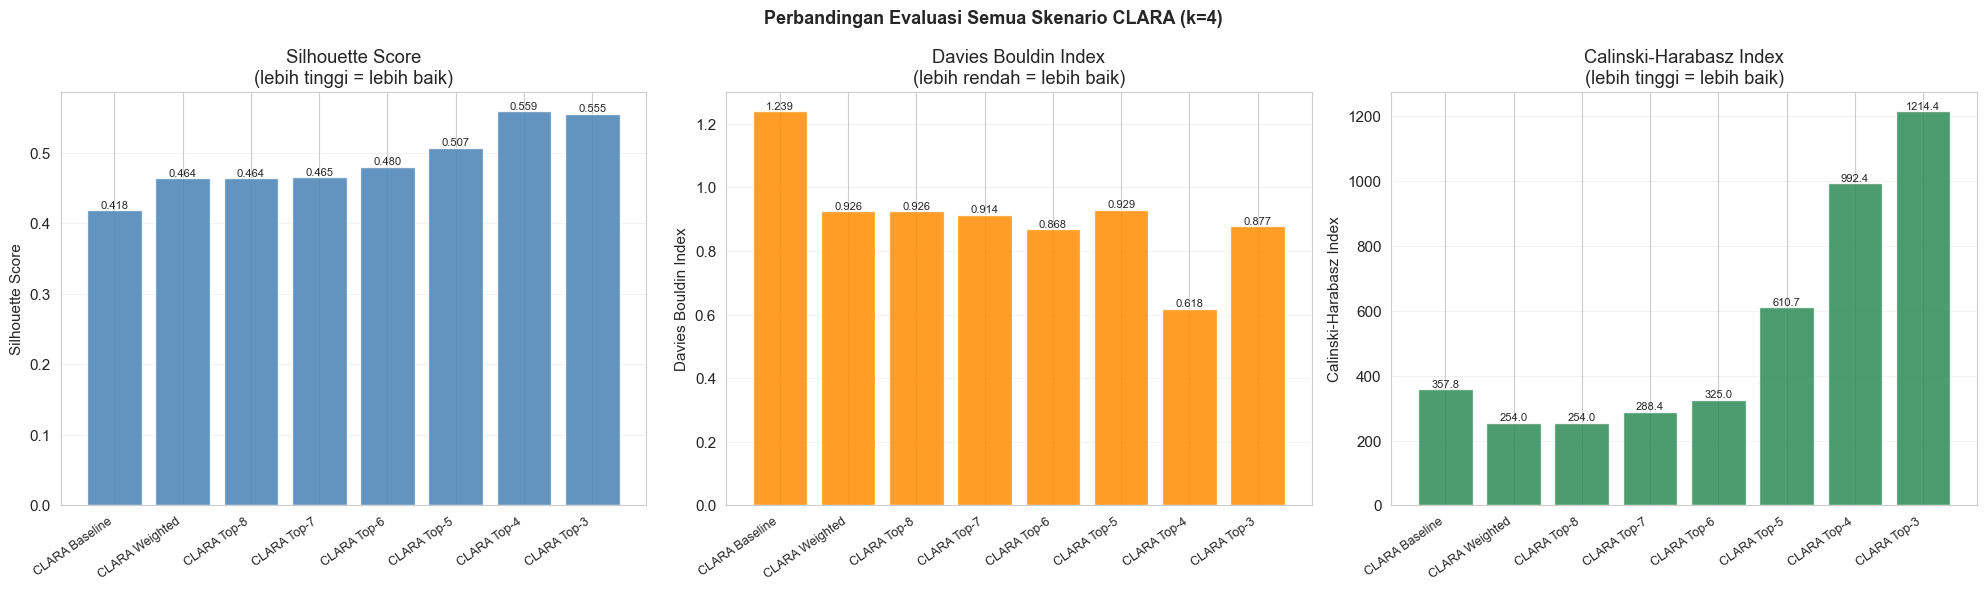

✅ Bar chart perbandingan berhasil ditampilkan.


In [28]:
# ============================================================
# CELL 16: TABEL PERBANDINGAN EVALUASI + VISUALISASI
# Silhouette Score (lebih tinggi = lebih baik)
# Davies Bouldin Index (lebih rendah = lebih baik)
# Calinski-Harabasz Index (lebih tinggi = lebih baik)
# ============================================================

comparison_data = [
    {'Skenario'                 : 'CLARA Baseline',
     'Silhouette Score'         : results_baseline[k_best]['silhouette'],
     'Davies Bouldin Index'     : results_baseline[k_best]['dbi'],
     'Calinski Harabasz Index'  : results_baseline[k_best]['chi']},
    {'Skenario'                 : 'CLARA Weighted',
     'Silhouette Score'         : sil_weighted,
     'Davies Bouldin Index'     : dbi_weighted,
     'Calinski Harabasz Index'  : chi_weighted},
]
for n_top in [8, 7, 6, 5, 4, 3]:
    key = f'Top-{n_top}'
    comparison_data.append({
        'Skenario'                 : f'CLARA {key}',
        'Silhouette Score'         : results_topn[key]['silhouette'],
        'Davies Bouldin Index'     : results_topn[key]['dbi'],
        'Calinski Harabasz Index'  : results_topn[key]['chi']
    })

df_comparison = pd.DataFrame(comparison_data).set_index('Skenario')


# Styling: highlight nilai terbaik
def highlight_best(s):
    if s.name == 'Silhouette Score':
        best = s.max()
        return ['background-color: #2e7d32; color: white; font-weight: bold' if v == best else '' for v in s]
    elif s.name == 'Davies Bouldin Index':
        best = s.min()
        return ['background-color: #1565c0; color: white; font-weight: bold' if v == best else '' for v in s]
    elif s.name == 'Calinski Harabasz Index':
        best = s.max()
        return ['background-color: #6a1b9a; color: white; font-weight: bold' if v == best else '' for v in s]
    return ['' for _ in s]

print(f"📊 Tabel Perbandingan Evaluasi Semua Skenario (k={k_best}):\n")
display(df_comparison.style.apply(highlight_best).format("{:.4f}"))

df_comp = df_comparison.copy()

sil_min, sil_max = df_comp['Silhouette Score'].min(), df_comp['Silhouette Score'].max()
dbi_min, dbi_max = df_comp['Davies Bouldin Index'].min(), df_comp['Davies Bouldin Index'].max()

if np.isclose(sil_max - sil_min, 0):
    df_comp['sil_norm'] = 0.5
else:
    df_comp['sil_norm'] = (df_comp['Silhouette Score'] - sil_min) / (sil_max - sil_min)

if np.isclose(dbi_max - dbi_min, 0):
    df_comp['dbi_norm'] = 0.5
else:
    df_comp['dbi_norm'] = (dbi_max - df_comp['Davies Bouldin Index']) / (dbi_max - dbi_min)

# Score gabungan tetap menggunakan SC + DBI agar konsisten dengan analisis sebelumnya.
# CH dilaporkan sebagai metrik evaluasi tambahan.
df_comp['score'] = 0.5 * df_comp['sil_norm'] + 0.5 * df_comp['dbi_norm']
best_overall = df_comp['score'].idxmax()

print(f"\n🏆 Skenario terbaik (Multi-Metric SC + DBI): {best_overall} "
      f"(score = {df_comp.loc[best_overall,'score']:.4f})")

# --- Bar Chart Perbandingan ---
methods    = df_comparison.index.tolist()
sil_scores = df_comparison['Silhouette Score'].values
dbi_scores = df_comparison['Davies Bouldin Index'].values
chi_scores = df_comparison['Calinski Harabasz Index'].values
x     = np.arange(len(methods))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Perbandingan Evaluasi Semua Skenario CLARA (k={k_best})',
             fontsize=13, fontweight='bold')

bar1 = ax1.bar(x, sil_scores, color='steelblue', alpha=0.85)
ax1.set_title('Silhouette Score\n(lebih tinggi = lebih baik)')
ax1.set_ylabel('Silhouette Score')
ax1.set_xticks(x); ax1.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
ax1.grid(True, alpha=0.25, axis='y')
for bar in bar1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

bar2 = ax2.bar(x, dbi_scores, color='darkorange', alpha=0.85)
ax2.set_title('Davies Bouldin Index\n(lebih rendah = lebih baik)')
ax2.set_ylabel('Davies Bouldin Index')
ax2.set_xticks(x); ax2.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
ax2.grid(True, alpha=0.25, axis='y')
for bar in bar2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

bar3 = ax3.bar(x, chi_scores, color='seagreen', alpha=0.85)
ax3.set_title('Calinski-Harabasz Index\n(lebih tinggi = lebih baik)')
ax3.set_ylabel('Calinski-Harabasz Index')
ax3.set_xticks(x); ax3.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
ax3.grid(True, alpha=0.25, axis='y')
for bar in bar3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('perbandingan_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart perbandingan berhasil ditampilkan.")


## 12. Analisis Hasil Cluster

Menghitung rata-rata setiap variabel per cluster dari **skenario terbaik** (skor gabungan Silhouette + DBI; CH dilaporkan sebagai metrik tambahan).  
Digunakan data setelah encoding (sebelum normalisasi) agar lebih mudah diinterpretasi.

📊 Rata-rata Variabel per Cluster — CLARA Top-4 (k=4):



,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
Cluster,,,,,,,,
1,0.9490,6.9780,1202.7830,109621395.1310,99599485.0190,1.1220,0.7210,0.8330
2,0.9930,29.5100,7486.4140,427525000.0000,337107931.0340,1.0900,0.7030,0.8070
3,0.9640,7.0150,1040.0990,791286040.1460,765337591.2410,1.1680,0.7920,0.8690
4,0.8650,4.0000,10267.6150,198036458.3330,205406770.8330,1.1040,0.8650,0.8650


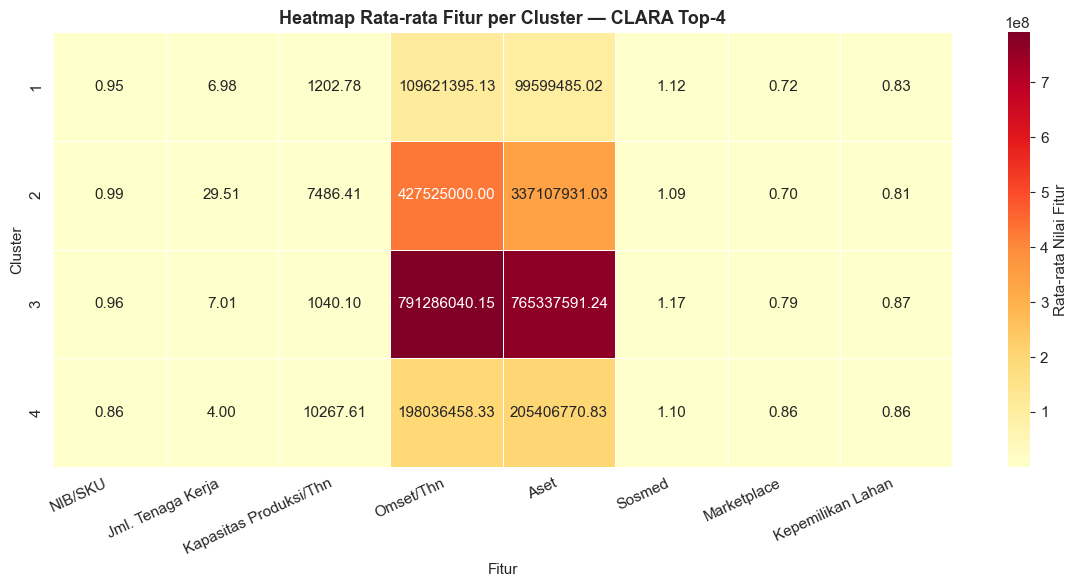


  KARAKTERISTIK TIAP CLUSTER — CLARA Top-4 (k=4)

CLUSTER 1  —  534 UMKM (50.9%)
  NIB/SKU Legal      : 94.9%
  Tenaga Kerja       : 7.0 orang
  Kap. Produksi/Thn  : 1,203 unit
  Omset/Tahun        : Rp 109,621,395
  Aset               : Rp 99,599,485
  Sosmed             : 1.1 platform
  Marketplace        : 0.7 platform
  Kepemilikan Lahan  : 83.3% milik sendiri
  ✅ Profil          : 🔴 UMKM Skala Kecil / Pemula
  📱 Digitalisasi    : Adopsi terbatas

CLUSTER 2  —  145 UMKM (13.8%)
  NIB/SKU Legal      : 99.3%
  Tenaga Kerja       : 29.5 orang
  Kap. Produksi/Thn  : 7,486 unit
  Omset/Tahun        : Rp 427,525,000
  Aset               : Rp 337,107,931
  Sosmed             : 1.1 platform
  Marketplace        : 0.7 platform
  Kepemilikan Lahan  : 80.7% milik sendiri
  ✅ Profil          : 🟡 UMKM Skala Menengah / Berkembang
  📱 Digitalisasi    : Adopsi terbatas

CLUSTER 3  —  274 UMKM (26.1%)
  NIB/SKU Legal      : 96.4%
  Tenaga Kerja       : 7.0 orang
  Kap. Produksi/Thn  : 1,040 unit
 

In [29]:
# ============================================================
# CELL 17: ANALISIS HASIL CLUSTER
# Menggunakan skenario terbaik berdasarkan multi-metric score.
# Tampilkan rata-rata fitur per cluster + heatmap.
# ============================================================

# Pilih label skenario terbaik
if best_overall == 'CLARA Baseline':
    best_labels = labels_baseline
elif best_overall == 'CLARA Weighted':
    best_labels = labels_weighted
else:
    best_labels = results_topn[best_overall.replace('CLARA ', '')]['labels']

# Gabungkan data encoded + label cluster
df_analysis                   = df_clean[FEATURE_COLS].copy()
df_analysis['Identitas_UMKM'] = df_scaled['Identitas_UMKM'].values
df_analysis['Cluster']        = best_labels + 1

# Rata-rata per cluster
df_cluster_means = df_analysis.groupby('Cluster')[FEATURE_COLS].mean()
global_mean      = df_analysis[FEATURE_COLS].mean()

print(f"📊 Rata-rata Variabel per Cluster — {best_overall} (k={k_best}):\n")
display(df_cluster_means.round(3))

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(12, max(4, k_best * 1.5)))
sns.heatmap(df_cluster_means, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Rata-rata Nilai Fitur'})
ax.set_title(f'Heatmap Rata-rata Fitur per Cluster — {best_overall}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fitur', fontsize=11); ax.set_ylabel('Cluster', fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('heatmap_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Karakteristik tiap cluster ---
print(f"\n{'='*65}")
print(f"  KARAKTERISTIK TIAP CLUSTER — {best_overall} (k={k_best})")
print(f"{'='*65}")

for cid in range(1, k_best + 1):
    n_umkm = len(df_analysis[df_analysis['Cluster'] == cid])
    means  = df_cluster_means.loc[cid]

    omset_ratio = means['Omset/Thn'] / (global_mean['Omset/Thn'] + 1e-9)
    aset_ratio  = means['Aset']       / (global_mean['Aset']       + 1e-9)
    avg_ratio   = (omset_ratio + aset_ratio) / 2

    profil  = ("🟢 UMKM Skala Besar / Maju"          if avg_ratio >= 1.3
               else "🟡 UMKM Skala Menengah / Berkembang" if avg_ratio >= 0.75
               else "🔴 UMKM Skala Kecil / Pemula")
    digital = ("Aktif digital"       if means['Sosmed'] + means['Marketplace'] >= 3
               else "Adopsi terbatas" if means['Sosmed'] + means['Marketplace'] >= 1
               else "Belum digital")

    print(f"\nCLUSTER {cid}  —  {n_umkm} UMKM ({n_umkm/len(df_analysis)*100:.1f}%)")
    print(f"  NIB/SKU Legal      : {means['NIB/SKU']*100:.1f}%")
    print(f"  Tenaga Kerja       : {means['Jml. Tenaga Kerja']:.1f} orang")
    print(f"  Kap. Produksi/Thn  : {means['Kapasitas Produksi/Thn']:,.0f} unit")
    print(f"  Omset/Tahun        : Rp {means['Omset/Thn']:,.0f}")
    print(f"  Aset               : Rp {means['Aset']:,.0f}")
    print(f"  Sosmed             : {means['Sosmed']:.1f} platform")
    print(f"  Marketplace        : {means['Marketplace']:.1f} platform")
    print(f"  Kepemilikan Lahan  : {means['Kepemilikan Lahan']*100:.1f}% milik sendiri")
    print(f"  ✅ Profil          : {profil}")
    print(f"  📱 Digitalisasi    : {digital}")

print(f"\n{'='*65}")

# --- Uji Kruskal-Wallis ---
print("\n📐 UJI KRUSKAL-WALLIS (Signifikansi Perbedaan Antar Cluster)\n")
print(f"{'Fitur':<25}  {'H-Statistic':>13}  {'p-value':>10}  {'Signifikan':>12}")
print("-" * 68)
for col in FEATURE_COLS:
    groups = [df_analysis[df_analysis['Cluster'] == cid][col].values
              for cid in range(1, k_best + 1)]
    try:
        h, p = kruskal(*groups)
        sig  = "Ya  ✅" if p < 0.05 else "Tidak ❌"
        print(f"{col:<25}  {h:>13.4f}  {p:>10.6f}  {sig:>12}")
    except Exception:
        print(f"{col:<25}  {'N/A':>44}")

## 13. Visualisasi Cluster

Visualisasi distribusi cluster menggunakan:
- **PCA** (Principal Component Analysis) — reduksi dimensi linear
- **t-SNE** — reduksi dimensi non-linear

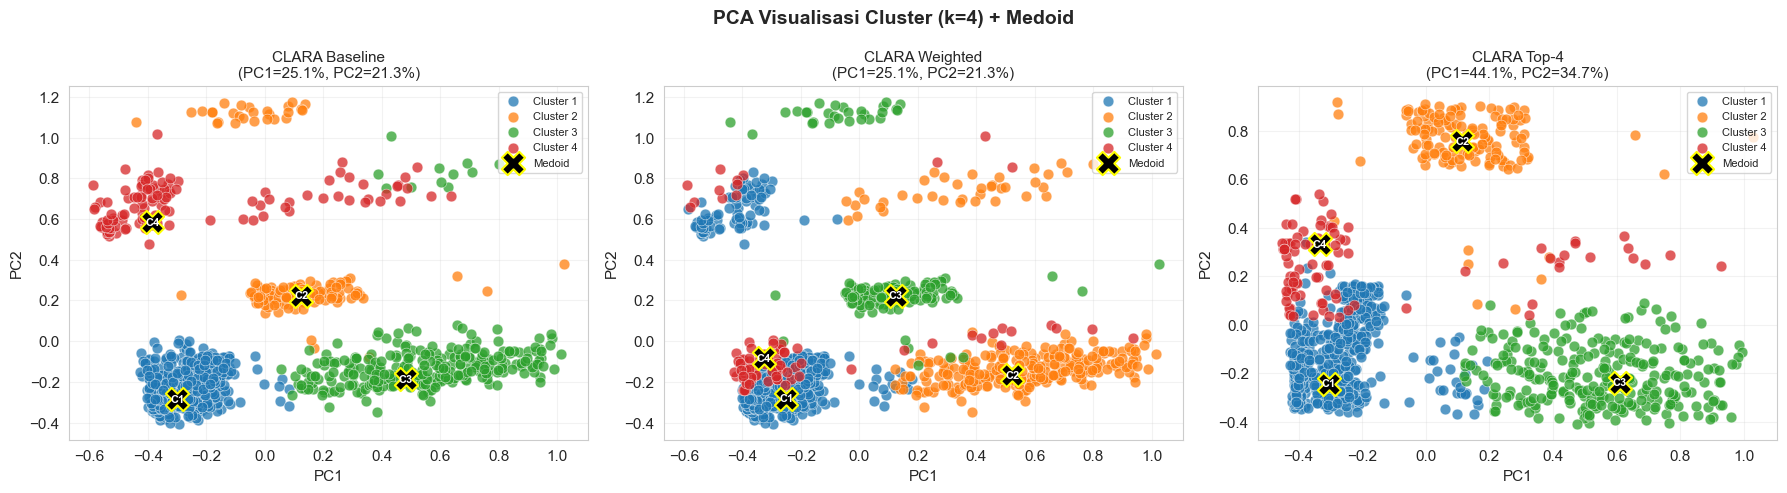

✅ Visualisasi PCA + medoid berhasil ditampilkan.


In [30]:
# ============================================================
# CELL 18: VISUALISASI CLUSTER — PCA + TITIK MEDOID
# ============================================================

# Validasi variabel wajib
required_vars = [
    "feature_names", "sorted_features", "X_scaled", "k_best",
    "labels_baseline", "labels_weighted", "medoids_weighted",
    "results_baseline", "results_topn"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Variabel belum tersedia: {missing}. Jalankan cell sebelumnya terlebih dahulu.")

# Data untuk skenario Top-4 (sesuai notebook Anda)
top4_features = results_topn["Top-4"]["features"]
top4_idx = [feature_names.index(f) for f in top4_features]
X_top4_raw = X_scaled[:, top4_idx]

# Skenario visualisasi + medoid
vis_scenarios = [
    ("CLARA Baseline", labels_baseline, X_scaled, results_baseline[k_best]["medoids"]),
    ("CLARA Weighted", labels_weighted, X_scaled, medoids_weighted),
    ("CLARA Top-4", results_topn["Top-4"]["labels"], X_top4_raw, results_topn["Top-4"]["medoids"]),
]

palette = sns.color_palette("tab10", n_colors=k_best)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"PCA Visualisasi Cluster (k={k_best}) + Medoid", fontsize=14, fontweight="bold")

for ax, (title, labels, X_vis, medoids) in zip(axes, vis_scenarios):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vis)
    expl = pca.explained_variance_ratio_

    # Titik anggota cluster
    for cid in range(k_best):
        mask = labels == cid
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=[palette[cid]], s=60, alpha=0.75,
            edgecolors="white", linewidths=0.4,
            label=f"Cluster {cid+1}"
        )

    # Titik medoid (X besar)
    medoids = np.asarray(medoids, dtype=int)
    ax.scatter(
        X_pca[medoids, 0], X_pca[medoids, 1],
        marker="X", s=280, c="black",
        edgecolors="yellow", linewidths=1.5,
        label="Medoid"
    )

    # Label nomor cluster di medoid
    for i, m in enumerate(medoids):
        ax.text(
            X_pca[m, 0], X_pca[m, 1],
            f"C{i+1}", fontsize=8, color="white",
            ha="center", va="center", fontweight="bold"
        )

    ax.set_title(f"{title}\n(PC1={expl[0]:.1%}, PC2={expl[1]:.1%})", fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig("pca_cluster_medoid.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi PCA + medoid berhasil ditampilkan.")

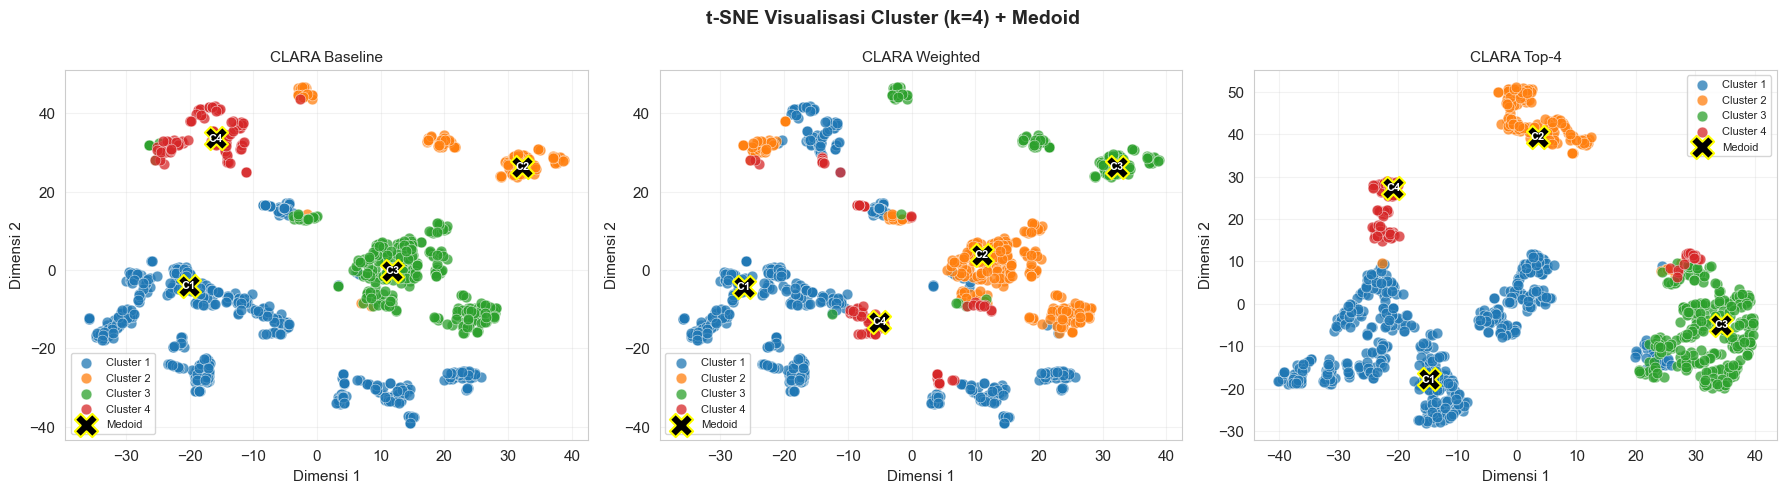

✅ Visualisasi t-SNE + medoid berhasil ditampilkan.


In [31]:
# ============================================================
# CELL 19: VISUALISASI CLUSTER — t-SNE + TITIK MEDOID
# ============================================================

# Pastikan vis_scenarios dari cell PCA sudah ada
if "vis_scenarios" not in globals():
    raise ValueError("vis_scenarios belum ada. Jalankan cell PCA (Cell 18) terlebih dahulu.")

palette = sns.color_palette("tab10", n_colors=k_best)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"t-SNE Visualisasi Cluster (k={k_best}) + Medoid", fontsize=14, fontweight="bold")

for ax, (title, labels, X_vis, medoids) in zip(axes, vis_scenarios):
    perp = min(30, max(5, len(X_vis) // 3))
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_2d = tsne.fit_transform(X_vis)

    # Titik anggota cluster
    for cid in range(k_best):
        mask = labels == cid
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=[palette[cid]], s=60, alpha=0.75,
            edgecolors="white", linewidths=0.4,
            label=f"Cluster {cid+1}"
        )

    # Titik medoid (X besar)
    medoids = np.asarray(medoids, dtype=int)
    ax.scatter(
        X_2d[medoids, 0], X_2d[medoids, 1],
        marker="X", s=280, c="black",
        edgecolors="yellow", linewidths=1.5,
        label="Medoid"
    )

    # Label nomor cluster di medoid
    for i, m in enumerate(medoids):
        ax.text(
            X_2d[m, 0], X_2d[m, 1],
            f"C{i+1}", fontsize=8, color="white",
            ha="center", va="center", fontweight="bold"
        )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Dimensi 1")
    ax.set_ylabel("Dimensi 2")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig("tsne_cluster_medoid.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi t-SNE + medoid berhasil ditampilkan.")

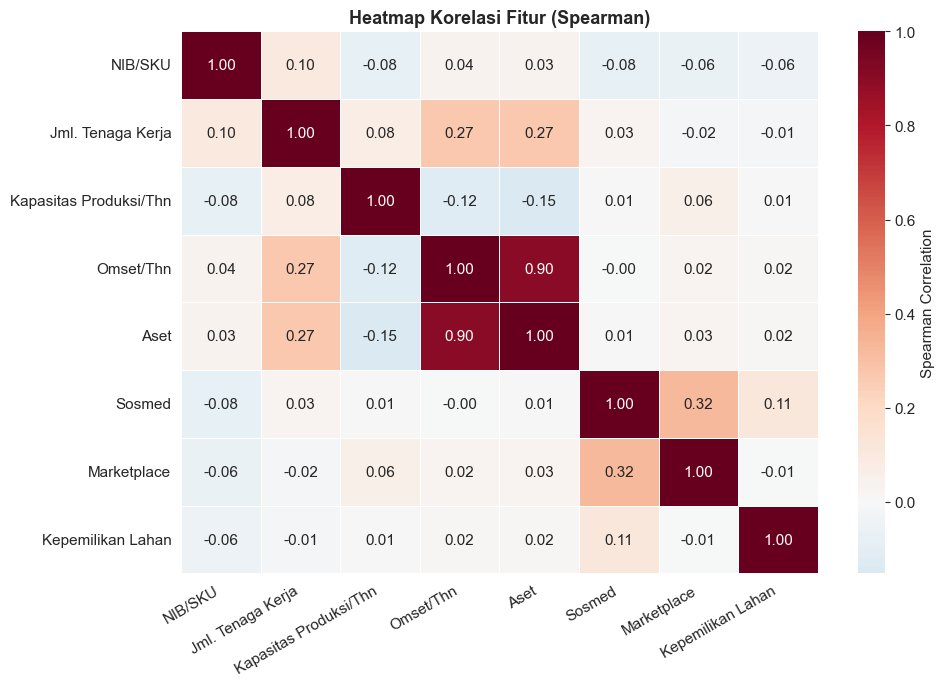

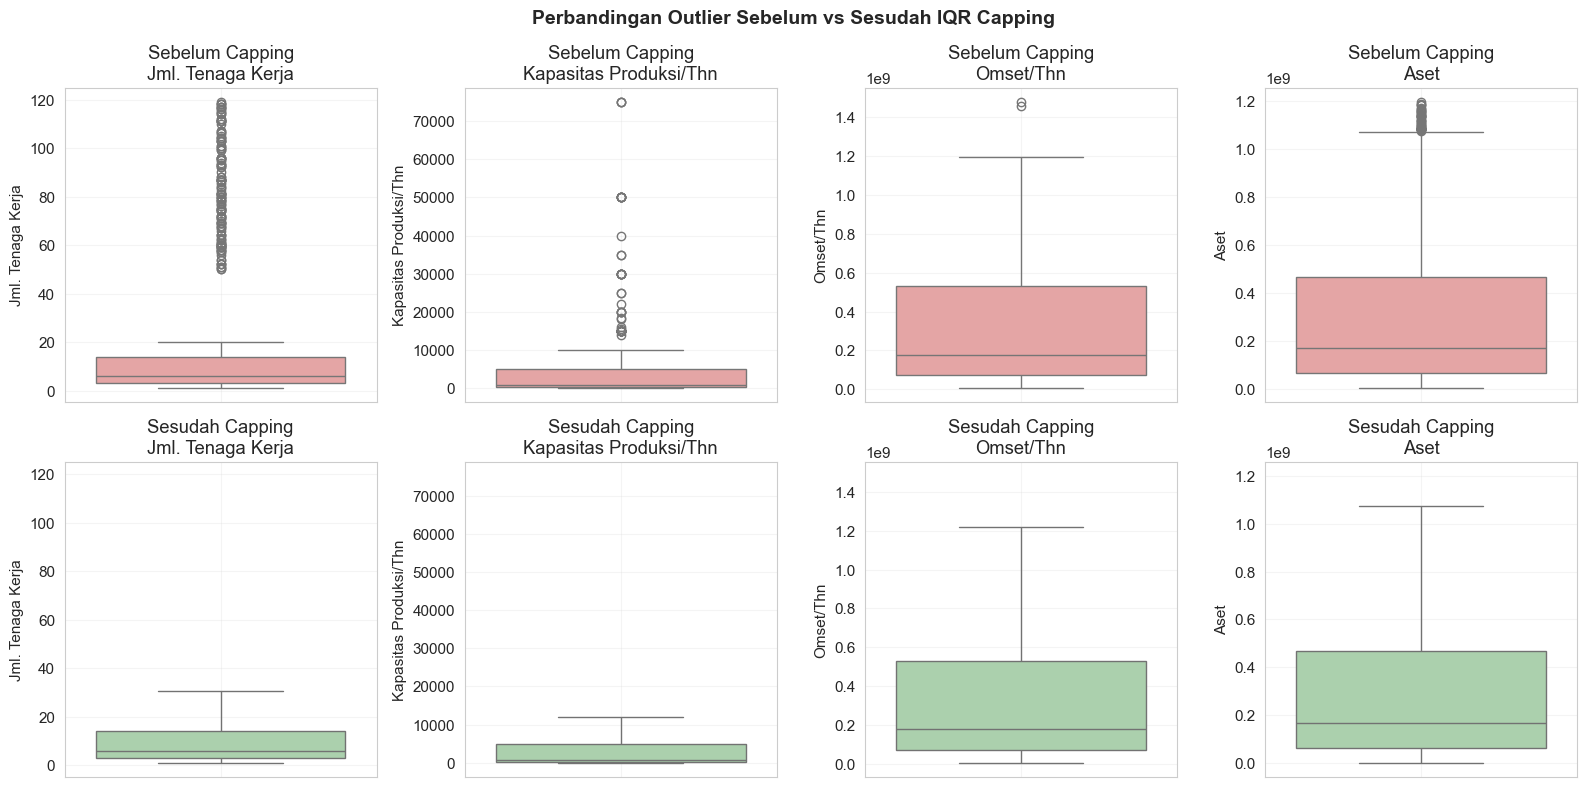

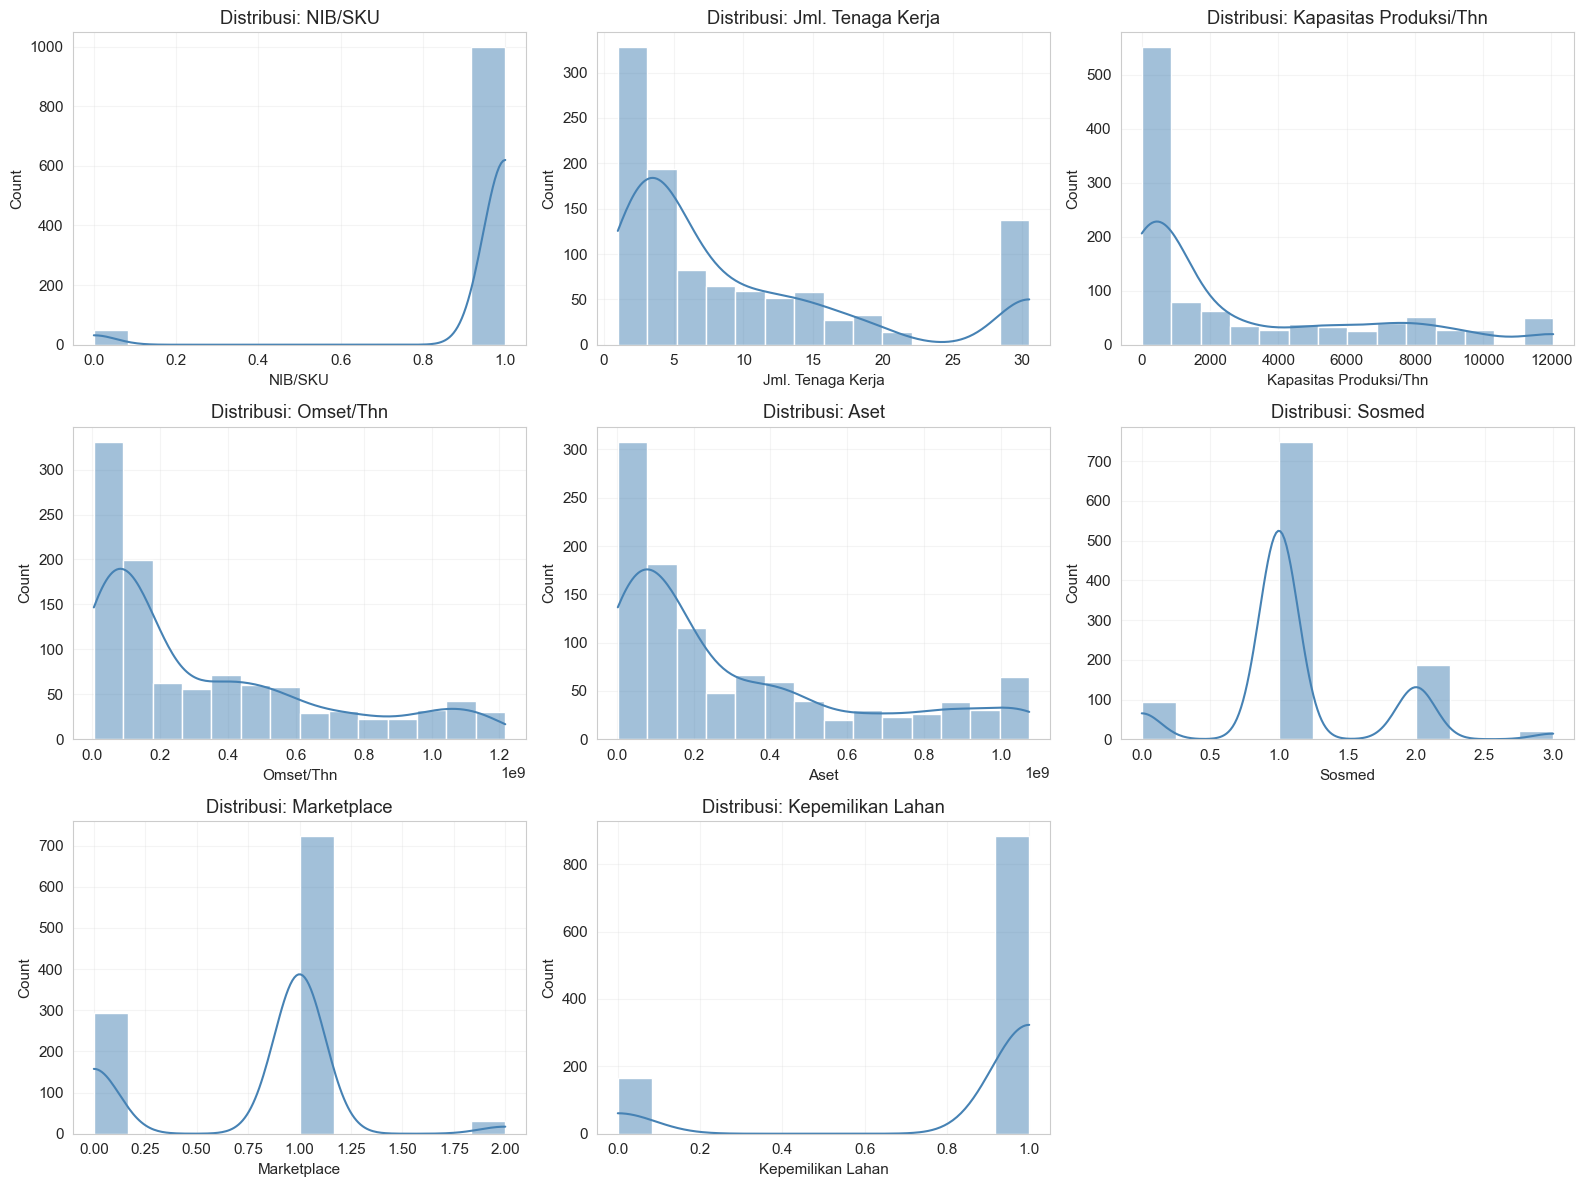

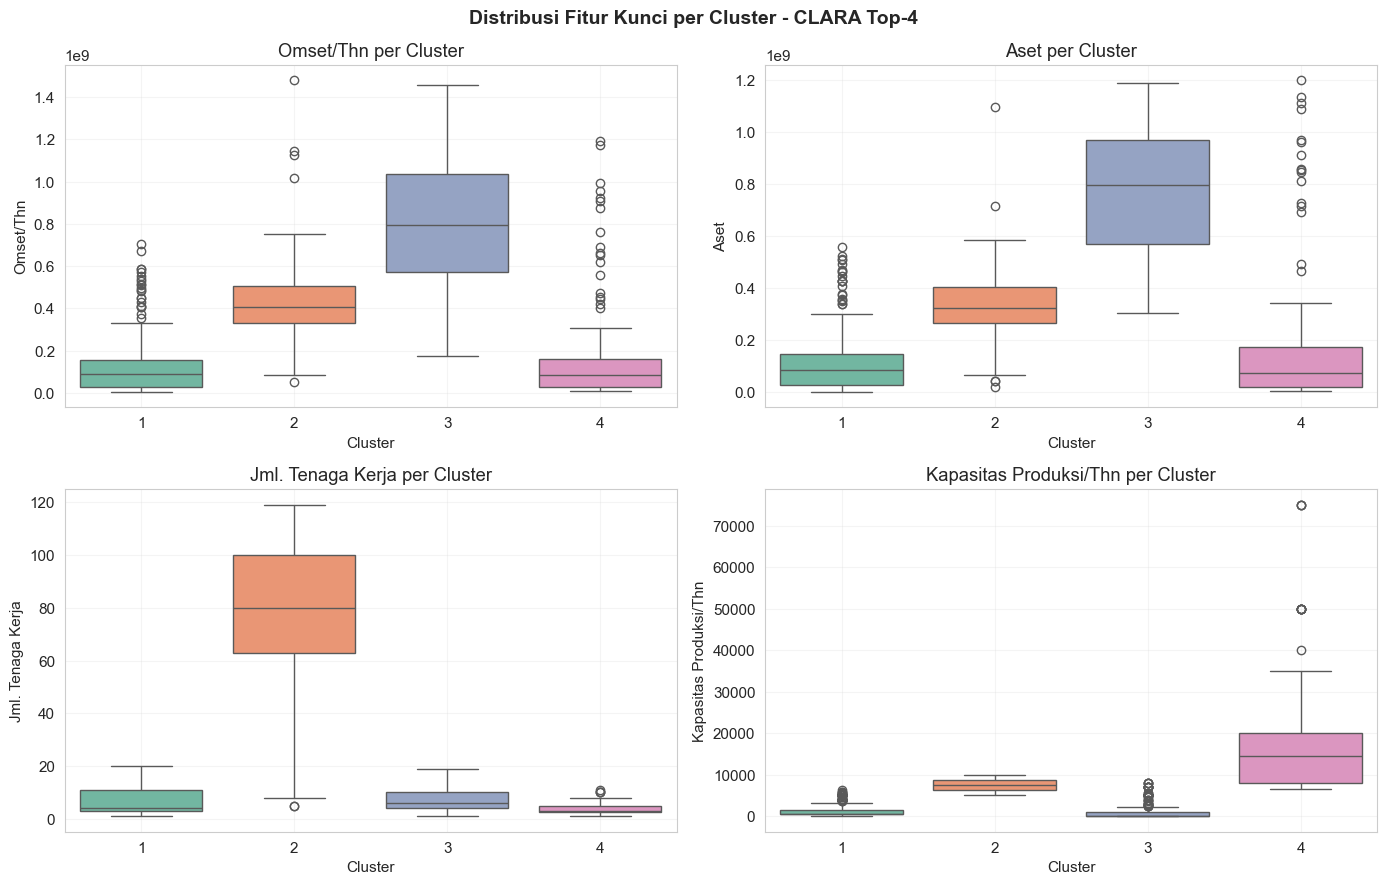


Medoid skenario terbaik: CLARA Top-4


,Cluster,Identitas_UMKM,NIB/SKU,Jml. Tenaga Kerja,Kapasitas Produksi/Thn,Omset/Thn,Aset,Sosmed,Marketplace,Kepemilikan Lahan
20,1,Owner-0021 - MSME-0012,1,4.0000,750,87500000,97750000,2,1,1
995,2,Owner-0891 - MSME-0407,1,30.5000,7076,405000000,324000000,1,1,1
688,3,Owner-0622 - MSME-0300,1,8.0000,35,863250000,785250000,1,0,1
585,4,Owner-0531 - MSME-0257,1,3.0000,12050,126500000,89000000,1,0,1



Selesai. File visual tersimpan:
 - heatmap_korelasi_fitur.png
 - outlier_before_after.png
 - distribusi_fitur.png
 - boxplot_fitur_per_cluster.png


In [32]:
# ============================================================
# CELL TAMBAHAN: VISUALISASI LENGKAP UNTUK TA (SIAP COPY-PASTE)
# - Heatmap korelasi fitur
# - Outlier before vs after capping
# - Distribusi tiap fitur
# - Distribusi fitur per cluster terbaik
# - Gambaran medoid cluster terbaik
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0) Validasi variabel wajib
# -----------------------------
required_vars = [
    "FEATURE_COLS", "df_enc", "df_clean", "df_scaled",
    "best_overall", "k_best", "results_baseline", "results_topn",
    "labels_baseline", "labels_weighted"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Variabel belum tersedia: {missing}. Jalankan cell sebelumnya terlebih dahulu.")

# OUTLIER_COLS fallback
if "OUTLIER_COLS" not in globals():
    OUTLIER_COLS = ['Jml. Tenaga Kerja', 'Kapasitas Produksi/Thn', 'Omset/Thn', 'Aset']

# Tentukan labels terbaik bila belum ada
if "best_labels" not in globals():
    if best_overall == "CLARA Baseline":
        best_labels = labels_baseline
    elif best_overall == "CLARA Weighted":
        best_labels = labels_weighted
    else:
        best_labels = results_topn[best_overall.replace("CLARA ", "")]["labels"]

saved_files = []

# ============================================================
# 1) Heatmap Korelasi Fitur (Spearman)
# ============================================================
try:
    plt.figure(figsize=(10, 7))
    corr = df_enc[FEATURE_COLS].corr(method="spearman")
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Spearman Correlation"}
    )
    plt.title("Heatmap Korelasi Fitur (Spearman)", fontsize=13, fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    fname = "heatmap_korelasi_fitur.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    saved_files.append(fname)
except Exception as e:
    print(f"[WARN] Heatmap korelasi gagal dibuat: {e}")

# ============================================================
# 2) Outlier Sebelum vs Sesudah Capping (IQR)
# ============================================================
try:
    fig, axes = plt.subplots(2, len(OUTLIER_COLS), figsize=(4 * len(OUTLIER_COLS), 8), sharey='col')
    if len(OUTLIER_COLS) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, col in enumerate(OUTLIER_COLS):
        sns.boxplot(y=df_enc[col], ax=axes[0, i], color="#ef9a9a")
        axes[0, i].set_title(f"Sebelum Capping\n{col}")
        axes[0, i].set_xlabel("")
        axes[0, i].grid(True, alpha=0.2)

        sns.boxplot(y=df_clean[col], ax=axes[1, i], color="#a5d6a7")
        axes[1, i].set_title(f"Sesudah Capping\n{col}")
        axes[1, i].set_xlabel("")
        axes[1, i].grid(True, alpha=0.2)

    plt.suptitle("Perbandingan Outlier Sebelum vs Sesudah IQR Capping", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fname = "outlier_before_after.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    saved_files.append(fname)
except Exception as e:
    print(f"[WARN] Visualisasi outlier gagal dibuat: {e}")

# ============================================================
# 3) Distribusi Tiap Fitur
# ============================================================
try:
    n_cols = 3
    n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(FEATURE_COLS):
        sns.histplot(df_clean[col], kde=True, ax=axes[i], color="steelblue")
        axes[i].set_title(f"Distribusi: {col}")
        axes[i].grid(True, alpha=0.2)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    fname = "distribusi_fitur.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    saved_files.append(fname)
except Exception as e:
    print(f"[WARN] Distribusi fitur gagal dibuat: {e}")

# ============================================================
# 4) Distribusi Fitur per Cluster Terbaik
# ============================================================
try:
    df_plot_cluster = df_enc[FEATURE_COLS].copy()
    df_plot_cluster["Cluster"] = best_labels + 1

    fitur_plot = ['Omset/Thn', 'Aset', 'Jml. Tenaga Kerja', 'Kapasitas Produksi/Thn']
    fitur_plot = [f for f in fitur_plot if f in FEATURE_COLS]

    if len(fitur_plot) > 0:
        n = len(fitur_plot)
        n_cols = 2
        n_rows = int(np.ceil(n / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(fitur_plot):
            sns.boxplot(data=df_plot_cluster, x="Cluster", y=col, ax=axes[i], palette="Set2")
            axes[i].set_title(f"{col} per Cluster")
            axes[i].grid(True, alpha=0.2)

        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        plt.suptitle(f"Distribusi Fitur Kunci per Cluster - {best_overall}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fname = "boxplot_fitur_per_cluster.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        saved_files.append(fname)
except Exception as e:
    print(f"[WARN] Boxplot fitur per cluster gagal dibuat: {e}")

# ============================================================
# 5) Gambaran Medoid Cluster Terbaik
# ============================================================
try:
    medoids_best = None
    if best_overall == "CLARA Baseline":
        medoids_best = results_baseline[k_best]["medoids"]
    elif best_overall == "CLARA Weighted":
        if "medoids_weighted" in globals():
            medoids_best = medoids_weighted
    else:
        key = best_overall.replace("CLARA ", "")
        if key in results_topn and "medoids" in results_topn[key]:
            medoids_best = results_topn[key]["medoids"]

    if medoids_best is not None:
        # pilih source data paling interpretatif
        source_df = df_clean.copy() if "df_clean" in globals() else df_enc.copy()
        if "Identitas_UMKM" not in source_df.columns and "Identitas_UMKM" in df_scaled.columns:
            source_df = source_df.copy()
            source_df.insert(0, "Identitas_UMKM", df_scaled["Identitas_UMKM"].values)

        cols_show = ["Identitas_UMKM"] + FEATURE_COLS if "Identitas_UMKM" in source_df.columns else FEATURE_COLS
        df_medoid_best = source_df.iloc[medoids_best][cols_show].copy()
        df_medoid_best.insert(0, "Cluster", np.arange(1, len(medoids_best) + 1))

        print(f"\nMedoid skenario terbaik: {best_overall}")
        display(df_medoid_best)
    else:
        print("\n[INFO] Medoid skenario terbaik belum tersedia (cek variabel medoid pada skenario terpilih).")
except Exception as e:
    print(f"[WARN] Ringkasan medoid gagal dibuat: {e}")

# ============================================================
# Ringkasan file output
# ============================================================
print("\nSelesai. File visual tersimpan:")
for f in saved_files:
    print(f" - {f}")

In [33]:
# ============================================================
# CELL 20: TABEL HASIL AKHIR CLUSTERING (VERSI ROBUST)
# Tampilkan Identitas_UMKM + Label Cluster dari skenario terbaik.
# ============================================================

# 1) Pastikan best_labels tersedia
if "best_labels" not in globals():
    if best_overall == "CLARA Baseline":
        best_labels = labels_baseline
    elif best_overall == "CLARA Weighted":
        best_labels = labels_weighted
    else:
        key_topn = best_overall.replace("CLARA ", "")
        if key_topn in results_topn:
            best_labels = results_topn[key_topn]["labels"]
        else:
            raise ValueError(f"Skenario terbaik '{best_overall}' tidak ditemukan di results_topn.")

print(f"🏆 Skenario terbaik: {best_overall}\n")

# 2) Bentuk tabel hasil akhir
df_hasil_akhir = pd.DataFrame({
    "Identitas_UMKM": df_scaled["Identitas_UMKM"].values,
    "Cluster": (best_labels + 1).astype(int)
}).sort_values("Cluster").reset_index(drop=True)

# Nomor urut dibuat setelah sorting agar urut rapi
df_hasil_akhir.insert(0, "No", np.arange(1, len(df_hasil_akhir) + 1))

print(f"📊 Hasil Clustering — {best_overall} (k={k_best}):")
display(df_hasil_akhir)

# 3) Distribusi cluster
print("\n📦 Distribusi Anggota per Cluster:")
dist = df_hasil_akhir["Cluster"].value_counts().sort_index()
for cid, cnt in dist.items():
    pct = cnt / len(df_hasil_akhir) * 100
    print(f"   Cluster {cid}: {cnt:3d} UMKM  ({pct:.1f}%)")

# 4) Simpan ke Excel
output_file = "hasil_clustering_umkm.xlsx"
df_hasil_akhir.to_excel(output_file, index=False)
print(f"\n💾 Hasil disimpan ke: {output_file}")

🏆 Skenario terbaik: CLARA Top-4

📊 Hasil Clustering — CLARA Top-4 (k=4):


,No,Identitas_UMKM,Cluster
0,1,Owner-0001 - MSME-0001,1
1,2,Owner-0456 - MSME-0012,1
2,3,Owner-0458 - MSME-0005,1
3,4,Owner-0459 - MSME-0017,1
4,5,Owner-0461 - MSME-0218,1
...,...,...,...
1044,1045,Owner-0466 - MSME-0143,4
1045,1046,Owner-0554 - MSME-0268,4
1046,1047,Owner-0209 - MSME-0004,4
1047,1048,Owner-0247 - MSME-0061,4



📦 Distribusi Anggota per Cluster:
   Cluster 1: 534 UMKM  (50.9%)
   Cluster 2: 145 UMKM  (13.8%)
   Cluster 3: 274 UMKM  (26.1%)
   Cluster 4:  96 UMKM  (9.2%)

💾 Hasil disimpan ke: hasil_clustering_umkm.xlsx


## 14. Kesimpulan Modeling

### Parameter Analisis
- **Jumlah data UMKM**: *ditentukan saat runtime*
- **Jumlah fitur**: 8 fitur (NIB/SKU, Jml. Tenaga Kerja, Kapasitas Produksi/Thn, Omset/Thn, Aset, Sosmed, Marketplace, Kepemilikan Lahan)
- **Metode clustering**: CLARA dengan Gower Distance
- **Pembobotan fitur**: Entropy Weight Method (EWM)
- **Evaluasi**: Silhouette Score + Davies Bouldin Index + Calinski-Harabasz Index

### Temuan
1. **Pengaruh pembobotan EWM**: Fitur dengan variasi lebih tinggi mendapat bobot lebih besar, memberikan kontribusi lebih signifikan terhadap penentuan cluster.
2. **Gower Distance berbobot**: Fitur yang lebih informatif (bobot tinggi) lebih memengaruhi pengelompokan UMKM.
3. **Skenario Top-N**: Dengan mengurangi fitur yang kurang informatif (bobot rendah), kualitas cluster dapat meningkat jika fitur yang tersisa lebih diskriminatif.

### Manfaat Segmentasi
Hasil segmentasi dapat digunakan sebagai dasar penyusunan program pemberdayaan UMKM yang lebih terarah — misalnya program digitalisasi untuk cluster UMKM yang belum menggunakan platform digital, atau pendampingan legalitas untuk cluster yang belum memiliki NIB/SKU.

In [34]:
# ============================================================
# CELL 21: RINGKASAN AKHIR (VERSI FINAL ROBUST)
# ============================================================

print("=" * 70)
print("        RINGKASAN ANALISIS SEGMENTASI UMKM")
print("=" * 70)

# ========================
# PARAMETER
# ========================
print("\n📌 PARAMETER:")
print(f"   Jumlah data UMKM      : {len(df_scaled)}")
print(f"   Jumlah fitur          : {len(FEATURE_COLS)}")
print(f"   k_best                : {k_best}")
print("   Dasar pemilihan k     : Multi-Metric (Silhouette + DBI; CH metrik tambahan)")

# ========================
# TABEL PERBANDINGAN
# ========================
print("\n📊 PERBANDINGAN EVALUASI:")
if "df_comp" in globals() and {"Silhouette Score", "Davies Bouldin Index", "score"}.issubset(df_comp.columns):
    display(df_comp[["Silhouette Score", "Davies Bouldin Index", "Calinski Harabasz Index", "score"]])
else:
    print("   [WARN] df_comp belum tersedia lengkap.")

# ========================
# METODE TERBAIK
# ========================
print("\n🏆 METODE TERBAIK (Multi-Metric):")
if "df_comp" in globals() and best_overall in df_comp.index and "score" in df_comp.columns:
    print(f"   {best_overall}  (score = {df_comp.loc[best_overall, 'score']:.4f})")
else:
    print(f"   {best_overall}")

# ========================
# PENGARUH EWM
# ========================
print("\n📈 PENGARUH PEMBOBOTAN EWM (Baseline → Weighted):")
if "df_comparison" in globals() and {"CLARA Baseline", "CLARA Weighted"}.issubset(df_comparison.index):
    delta_sil = (
        df_comparison.loc["CLARA Weighted", "Silhouette Score"]
        - df_comparison.loc["CLARA Baseline", "Silhouette Score"]
    )
    delta_dbi = (
        df_comparison.loc["CLARA Baseline", "Davies Bouldin Index"]
        - df_comparison.loc["CLARA Weighted", "Davies Bouldin Index"]
    )
    print(f"   Silhouette : {delta_sil:+.4f}  {'✅ meningkat' if delta_sil > 0 else '❌ menurun'}")
    print(f"   DBI        : {delta_dbi:+.4f}  {'✅ turun (lebih baik)' if delta_dbi > 0 else '❌ naik'}")
else:
    print("   [WARN] Data CLARA Baseline/Weighted di df_comparison belum lengkap.")

# ========================
# TOP FITUR
# ========================
print("\n📝 TOP-3 FITUR PALING BERPENGARUH (EWM):")
if "sorted_features" in globals() and "sorted_weights" in globals() and len(sorted_features) >= 3:
    for i, (f, w) in enumerate(zip(sorted_features[:3], sorted_weights[:3]), 1):
        print(f"   {i}. {f:<25}  wj = {w:.4f}")
elif "df_entropy_weights" in globals() and {"Feature", "Weight"}.issubset(df_entropy_weights.columns):
    df_top3 = df_entropy_weights.sort_values("Weight", ascending=False).head(3)
    for i, row in enumerate(df_top3.itertuples(index=False), 1):
        print(f"   {i}. {row.Feature:<25}  wj = {row.Weight:.4f}")
else:
    print("   [WARN] Bobot fitur EWM belum tersedia.")

# ========================
# DISTRIBUSI CLUSTER
# ========================
print(f"\n📦 DISTRIBUSI SEGMENTASI ({best_overall}):")
if "df_hasil_akhir" in globals() and "Cluster" in df_hasil_akhir.columns:
    dist_final = df_hasil_akhir["Cluster"].value_counts().sort_index()
    for cid, cnt in dist_final.items():
        pct = cnt / len(df_hasil_akhir) * 100
        print(f"   Cluster {cid}: {cnt:3d} UMKM  ({pct:.1f}%)")
else:
    print("   [WARN] df_hasil_akhir belum tersedia.")

print("\n" + "=" * 70)
print("  Analisis selesai. File hasil: hasil_clustering_umkm.xlsx")
print("=" * 70)

        RINGKASAN ANALISIS SEGMENTASI UMKM

📌 PARAMETER:
   Jumlah data UMKM      : 1049
   Jumlah fitur          : 8
   k_best                : 4
   Dasar pemilihan k     : Multi-Metric (Silhouette + DBI; CH metrik tambahan)

📊 PERBANDINGAN EVALUASI:


,Silhouette Score,Davies Bouldin Index,Calinski Harabasz Index,score
Skenario,,,,
CLARA Baseline,0.4183,1.2393,357.7787,0.0000
CLARA Weighted,0.4637,0.9258,253.9949,0.4139
CLARA Top-8,0.4637,0.9258,253.9949,0.4139
CLARA Top-7,0.4653,0.9141,288.4188,0.4289
CLARA Top-6,0.4802,0.8681,324.9926,0.5191
CLARA Top-5,0.5070,0.9295,610.6572,0.5650
CLARA Top-4,0.5588,0.6181,992.3958,1.0000
CLARA Top-3,0.5555,0.8772,1214.3638,0.7794



🏆 METODE TERBAIK (Multi-Metric):
   CLARA Top-4  (score = 1.0000)

📈 PENGARUH PEMBOBOTAN EWM (Baseline → Weighted):
   Silhouette : +0.0454  ✅ meningkat
   DBI        : +0.3135  ✅ turun (lebih baik)

📝 TOP-3 FITUR PALING BERPENGARUH (EWM):
   1. Kapasitas Produksi/Thn     wj = 0.2424
   2. Aset                       wj = 0.1744
   3. Omset/Thn                  wj = 0.1719

📦 DISTRIBUSI SEGMENTASI (CLARA Top-4):
   Cluster 1: 534 UMKM  (50.9%)
   Cluster 2: 145 UMKM  (13.8%)
   Cluster 3: 274 UMKM  (26.1%)
   Cluster 4:  96 UMKM  (9.2%)

  Analisis selesai. File hasil: hasil_clustering_umkm.xlsx


## 15. Ranking UMKM menggunakan TOPSIS

Setelah mendapatkan hasil clustering terbaik, kami menggunakan **TOPSIS** untuk melakukan ranking UMKM di dalam masing-masing cluster.

### Alur TOPSIS:
1. **Decision Matrix** - Data UMKM dalam cluster (Top-4 fitur)
2. **Normalisasi Vector** - Transformasi ke skala 0-1
3. **Weighted Matrix** - Kalikan dengan bobot entropy
4. **Ideal Solutions** - Tentukan solusi ideal positif dan negatif  
5. **Separation Measures** - Hitung jarak Euclidean
6. **Closeness Coefficient** - Hitung nilai preferensi (0-1)
7. **Ranking** - Urutkan berdasarkan preferensi


## TOPSIS - Technique for Order Preference by Similarity to Ideal Solution

### Deskripsi Umum
TOPSIS adalah metode pengambilan keputusan multi-kriteria yang mengukur jarak relatif dari alternatif (UMKM) terhadap solusi ideal positif dan negatif.

### Prinsip Dasar TOPSIS
1. **Solusi Ideal Positif (A+)**: Kombinasi nilai terbaik dari semua kriteria
2. **Solusi Ideal Negatif (A-)**: Kombinasi nilai terburuk dari semua kriteria
3. **UMKM Terbaik**: UMKM yang paling dekat ke A+ dan paling jauh dari A-

### Proses TOPSIS Step-by-Step
1. **Normalisasi Matrix**: Mengubah nilai ke skala 0-1 menggunakan Euclidean normalization
2. **Weighted Normalization**: Kalikan dengan bobot dari Entropy Weight Method
3. **Hitung Ideal Solutions**: Tentukan A+ (max) dan A- (min) untuk setiap kriteria
4. **Hitung Jarak**: D+ = jarak ke A+, D- = jarak ke A-
5. **Hitung Preferensi**: C_i = D- / (D+ + D-), range 0-1
6. **Ranking**: Urutkan berdasarkan preferensi (descending)

### Interpretasi Nilai Preferensi
- **C_i = 1.0**: UMKM paling unggul (identik dengan A+)
- **0.5 < C_i < 1.0**: UMKM unggul
- **C_i = 0.5**: UMKM berada di tengah
- **0.0 < C_i < 0.5**: UMKM lemah
- **C_i = 0.0**: UMKM paling lemah (identik dengan A-)

### Keuntungan TOPSIS
- Sederhana dan mudah dipahami
- Mempertimbangkan keseluruhan kriteria secara simultan
- Hasil unik dan stabil
- Cocok untuk ranking dengan banyak kriteria

### Catatan untuk Penelitian Ini
- Dilakukan **per cluster** secara independen
- Menggunakan bobot dari **Entropy Weight Method**
- Semua 4 kriteria adalah **BENEFIT** (semakin besar semakin baik)
- Hasil ranking hanya valid untuk UMKM dalam **cluster yang sama**


In [35]:
# ============================================================
# CELL 22: DEFINISI FUNGSI TOPSIS (Complete Implementation)
# ============================================================
# Implementasi TOPSIS untuk ranking UMKM dalam setiap cluster
# menggunakan bobot entropy yang sudah dihitung sebelumnya.
# Semua kriteria adalah BENEFIT (semakin besar semakin baik).
# ============================================================

import numpy as np
import pandas as pd
from typing import Dict, Tuple, List

def normalize_vector(matrix: np.ndarray) -> np.ndarray:
    """STEP 1: Normalisasi Vector menggunakan Euclidean normalization"""
    col_sums_squared = np.sum(matrix ** 2, axis=0)
    denominators = np.sqrt(col_sums_squared)
    denominators = np.where(denominators == 0, 1, denominators)
    normalized = matrix / denominators
    return normalized

def weighted_normalized_matrix(normalized: np.ndarray, weights: Dict, 
                               feature_names: List) -> Tuple:
    """STEP 2: Weighted Normalized Matrix - kalikan dengan bobot entropy"""
    weights_array = np.array([weights[f] for f in feature_names])
    weighted_matrix = normalized * weights_array
    return weighted_matrix, weights_array

def calculate_ideal_solutions(weighted_matrix: np.ndarray) -> Tuple:
    """STEP 3: Hitung Ideal Positive Solution (IPS) dan Ideal Negative Solution (INS)"""
    # Semua kriteria BENEFIT: IPS = max, INS = min
    ips = np.max(weighted_matrix, axis=0)
    ins = np.min(weighted_matrix, axis=0)
    return ips, ins

def calculate_distances(weighted_matrix: np.ndarray, ips: np.ndarray, 
                       ins: np.ndarray) -> Tuple:
    """STEP 4: Hitung jarak Euclidean ke IPS (D+) dan INS (D-)"""
    d_positive = np.sqrt(np.sum((weighted_matrix - ips) ** 2, axis=1))
    d_negative = np.sqrt(np.sum((weighted_matrix - ins) ** 2, axis=1))
    return d_positive, d_negative

def calculate_preference_values(d_positive: np.ndarray, d_negative: np.ndarray) -> np.ndarray:
    """STEP 5: Hitung Closeness Coefficient (Nilai Preferensi): C_i = D- / (D+ + D-)"""
    denominator = d_positive + d_negative
    denominator = np.where(denominator == 0, 1e-10, denominator)
    preference_values = d_negative / denominator
    preference_values = np.clip(preference_values, 0, 1)
    return preference_values

def rank_alternatives(preference_values: np.ndarray) -> np.ndarray:
    """STEP 6: Hitung Ranking berdasarkan nilai preferensi (descending)"""
    sorted_indices = np.argsort(-preference_values)
    rankings = np.empty_like(sorted_indices, dtype=int)
    for rank, idx in enumerate(sorted_indices, 1):
        rankings[idx] = rank
    return rankings

def topsis_ranking(df_cluster: pd.DataFrame, feature_cols: List,  
                   weights: Dict, cluster_id: int) -> pd.DataFrame:
    """Main TOPSIS - Complete Pipeline per Cluster"""
    X = df_cluster[feature_cols].values
    
    if X.shape[0] == 0:
        raise ValueError(f'Cluster {cluster_id} tidak memiliki data')
    
    if X.shape[0] == 1:
        result = df_cluster.copy()
        result['skor_topsis'] = 1.0
        result['ranking_topsis'] = 1
        return result
    
    X_normalized = normalize_vector(X)
    X_weighted, _ = weighted_normalized_matrix(X_normalized, weights, feature_cols)
    ips, ins = calculate_ideal_solutions(X_weighted)
    d_plus, d_minus = calculate_distances(X_weighted, ips, ins)
    preference = calculate_preference_values(d_plus, d_minus)
    rankings = rank_alternatives(preference)
    
    result = df_cluster.copy()
    result['skor_topsis'] = preference
    result['ranking_topsis'] = rankings
    return result

print('✓ TOPSIS functions loaded successfully')


✓ TOPSIS functions loaded successfully


In [36]:
# ============================================================
# CELL 23: EKSEKUSI TOPSIS DENGAN DETAIL OUTPUT PER CLUSTER
# ============================================================

# Informasi kriteria
print("=" * 70)
print("INFORMASI KRITERIA UNTUK ANALISIS TOPSIS")
print("=" * 70)
print("""
JENIS KRITERIA TOPSIS
────────────────────────────────────────────────────────────────────
 No | Kriteria                          | Jenis    | Interpretasi
────┼───────────────────────────────────┼──────────┼─────────────────
  1 | Kapasitas Produksi/Thn            | BENEFIT  | Semakin besar, semakin baik
  2 | Aset                              | BENEFIT  | Semakin besar, semakin baik
  3 | Omset/Thn                         | BENEFIT  | Semakin besar, semakin baik
  4 | Jml. Tenaga Kerja                 | BENEFIT  | Semakin besar, semakin baik
────┴───────────────────────────────────┴──────────┴─────────────────
""")
print("Catatan:")
print("- BENEFIT: Nilai yang lebih besar selalu lebih diinginkan")
print("- Semua kriteria dalam analisis ini adalah BENEFIT\n")

# Ambil 4 fitur teratas berdasarkan bobot entropy
topsis_features = sorted_features[:4]

print("=" * 70)
print("FITUR DAN BOBOT YANG DIGUNAKAN DALAM TOPSIS")
print("=" * 70)

for i, feat in enumerate(topsis_features, 1):
    print(f"{i}. {feat}")

# Hitung bobot normalisasi untuk TOPSIS features
topsis_weights_raw = {f: weights[f] for f in topsis_features}
total_weight = sum(topsis_weights_raw.values())
topsis_weights_norm = {f: w / total_weight for f, w in topsis_weights_raw.items()}

print(f"\nBobot Normalisasi TOPSIS (dari Entropy Weight Method):")
print(f"{'─'*50}")
for feat in topsis_features:
    print(f"  {feat:<35}: {topsis_weights_norm[feat]:.6f}")
print(f"  {'Total bobot':<35}: {sum(topsis_weights_norm.values()):.6f}")

# Siapkan data untuk TOPSIS
df_with_cluster = df_scaled[['Identitas_UMKM'] + topsis_features].copy()
df_with_cluster['Cluster'] = df_analysis['Cluster'].values

print(f"\nMelakukan TOPSIS untuk setiap cluster...\n")

# Dictionary untuk menyimpan hasil TOPSIS per cluster
topsis_results_per_cluster = {}

# Eksekusi TOPSIS untuk setiap cluster
for cluster_id in sorted(df_with_cluster['Cluster'].unique()):
    df_cluster_data = df_with_cluster[df_with_cluster['Cluster'] == cluster_id][['Identitas_UMKM'] + topsis_features].copy()
    df_cluster_data = df_cluster_data.reset_index(drop=True)
    
    # Extract data untuk display detail
    X = df_cluster_data[topsis_features].values.astype(float)
    n_umkm = len(X)
    n_kriteria = len(topsis_features)
    
    # Print header cluster
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}: PROSES TOPSIS DETAIL")
    print(f"{'='*70}")
    
    # [1] Matriks Keputusan
    print(f"\n[1] MATRIKS KEPUTUSAN (Decision Matrix)")
    print(f"    Jumlah UMKM (Alternatives): {n_umkm}")
    print(f"    Jumlah Kriteria: {n_kriteria}")
    print(f"    Kriteria: {topsis_features}")
    print(f"\n    Sample data (baris 1-3):")
    for i in range(min(3, len(X))):
        print(f"      {X[i]}")
    if len(X) > 3:
        print(f"      ... ({len(X)-3} baris lainnya)")
    
    # Normalisasi
    col_sums_squared = np.sum(X ** 2, axis=0)
    denominators = np.sqrt(col_sums_squared)
    denominators = np.where(denominators == 0, 1, denominators)
    normalized = X / denominators
    
    # [2] Matriks Normalisasi
    print(f"\n[2] MATRIKS NORMALISASI (Normalized Decision Matrix)")
    print(f"    Rumus: r_ij = x_ij / sqrt(sum(x_ij^2))")
    print(f"    Metode: Vector Normalization (Euclidean)")
    print(f"\n    Sample data (baris 1-3):")
    for i in range(min(3, len(normalized))):
        print(f"      {normalized[i]}")
    if len(normalized) > 3:
        print(f"      ... ({len(normalized)-3} baris lainnya)")
    
    # Weighted normalized
    weights_array = np.array([topsis_weights_norm[col] for col in topsis_features])
    weighted_matrix = normalized * weights_array
    
    # [3] Weighted Normalized Matrix
    print(f"\n[3] WEIGHTED NORMALIZED MATRIX")
    print(f"    Rumus: v_ij = w_j x r_ij")
    print(f"    Bobot (dari Entropy Weight Method):")
    for feat, w in zip(topsis_features, weights_array):
        print(f"      {feat:<35}: {w:.6f}")
    print(f"    Total bobot: {weights_array.sum():.6f}")
    print(f"\n    Sample data (baris 1-3):")
    for i in range(min(3, len(weighted_matrix))):
        print(f"      {weighted_matrix[i]}")
    if len(weighted_matrix) > 3:
        print(f"      ... ({len(weighted_matrix)-3} baris lainnya)")
    
    # Ideal solutions
    ips = np.max(weighted_matrix, axis=0)
    ins = np.min(weighted_matrix, axis=0)
    
    # [4] Solusi Ideal
    print(f"\n[4] SOLUSI IDEAL POSITIF (A+) & NEGATIF (A-)")
    print(f"    Semua kriteria BENEFIT: A+ = max(V), A- = min(V)")
    print(f"    Interpretasi:")
    print(f"      A+ = Kondisi terbaik pada setiap kriteria")
    print(f"      A- = Kondisi terburuk pada setiap kriteria")
    print(f"\n    A+ (Solusi Ideal Positif):")
    for feat, val in zip(topsis_features, ips):
        print(f"      {feat:<35}: {val:.6f}")
    print(f"\n    A- (Solusi Ideal Negatif):")
    for feat, val in zip(topsis_features, ins):
        print(f"      {feat:<35}: {val:.6f}")
    
    # Distances
    d_positive = np.sqrt(np.sum((weighted_matrix - ips) ** 2, axis=1))
    d_negative = np.sqrt(np.sum((weighted_matrix - ins) ** 2, axis=1))
    
    # [5] Jarak
    print(f"\n[5] JARAK KE SOLUSI IDEAL")
    print(f"    D+ (Jarak Positif): sqrt(sum((v_ij - a_j+)^2))")
    print(f"    D- (Jarak Negatif): sqrt(sum((v_ij - a_j-)^2))")
    print(f"\n    Statistik D+ (Jarak ke Solusi Ideal Positif):")
    print(f"      Min  : {d_positive.min():.6f}")
    print(f"      Max  : {d_positive.max():.6f}")
    print(f"      Mean : {d_positive.mean():.6f}")
    print(f"      Nilai 1-3: {d_positive[:min(3, len(d_positive))]}")
    print(f"\n    Statistik D- (Jarak ke Solusi Ideal Negatif):")
    print(f"      Min  : {d_negative.min():.6f}")
    print(f"      Max  : {d_negative.max():.6f}")
    print(f"      Mean : {d_negative.mean():.6f}")
    print(f"      Nilai 1-3: {d_negative[:min(3, len(d_negative))]}")
    
    # Preference
    total_distance = d_positive + d_negative
    preference = np.where(total_distance != 0, d_negative / total_distance, 0.0)
    
    # [6] Nilai Preferensi
    print(f"\n[6] NILAI PREFERENSI (Closeness Coefficient)")
    print(f"    Rumus: C_i = D- / (D+ + D-), dimana 0 <= C_i <= 1")
    print(f"\n    Interpretasi:")
    print(f"      C_i mendekati 1.0 = UMKM unggul (dekat A+, jauh dari A-)")
    print(f"      C_i mendekati 0.0 = UMKM lemah (jauh dari A+, dekat A-)")
    print(f"\n    Statistik Preferensi:")
    print(f"      Max      : {preference.max():.6f}")
    print(f"      Min      : {preference.min():.6f}")
    print(f"      Mean     : {preference.mean():.6f}")
    print(f"      Std Dev  : {preference.std():.6f}")
    
    # Rankings
    rankings = np.argsort(-preference) + 1
    
    # [7] Ranking
    print(f"\n[7] RANKING TOPSIS")
    print(f"    Rank 1 = UMKM dengan nilai preferensi tertinggi (terbaik)")
    
    print(f"\n{'─'*70}")
    print(f"TOP 5 UMKM TERBAIK DI CLUSTER {cluster_id}")
    print(f"{'─'*70}")
    
    # Build result
    result = df_cluster_data.copy()
    result['D_positive'] = d_positive
    result['D_negative'] = d_negative
    result['skor_topsis'] = preference
    result['ranking_topsis'] = rankings
    # Sort by skor_topsis descending (highest score first), then generate ranking
    result = result.sort_values('skor_topsis', ascending=False).reset_index(drop=True)
    result['ranking_topsis'] = range(1, len(result) + 1)
    
    # Display top 5
    top_5 = result.head(5)
    for _, row in top_5.iterrows():
        rank = int(row['ranking_topsis'])
        name = row['Identitas_UMKM']
        d_pos = row['D_positive']
        d_neg = row['D_negative']
        score = row['skor_topsis']
        print(f"Rank {rank}: {name:<40}")
        print(f"         D+={d_pos:.6f}  D-={d_neg:.6f}  Score={score:.6f}")
    
    topsis_results_per_cluster[cluster_id] = result.copy()

print(f"\n{'='*70}")
print(f"TOPSIS RANKING SELESAI!")
print(f"Total cluster yang diproses: {len(topsis_results_per_cluster)}")
print(f"{'='*70}")



INFORMASI KRITERIA UNTUK ANALISIS TOPSIS

JENIS KRITERIA TOPSIS
────────────────────────────────────────────────────────────────────
 No | Kriteria                          | Jenis    | Interpretasi
────┼───────────────────────────────────┼──────────┼─────────────────
  1 | Kapasitas Produksi/Thn            | BENEFIT  | Semakin besar, semakin baik
  2 | Aset                              | BENEFIT  | Semakin besar, semakin baik
  3 | Omset/Thn                         | BENEFIT  | Semakin besar, semakin baik
  4 | Jml. Tenaga Kerja                 | BENEFIT  | Semakin besar, semakin baik
────┴───────────────────────────────────┴──────────┴─────────────────

Catatan:
- BENEFIT: Nilai yang lebih besar selalu lebih diinginkan
- Semua kriteria dalam analisis ini adalah BENEFIT

FITUR DAN BOBOT YANG DIGUNAKAN DALAM TOPSIS
1. Kapasitas Produksi/Thn
2. Aset
3. Omset/Thn
4. Jml. Tenaga Kerja

Bobot Normalisasi TOPSIS (dari Entropy Weight Method):
─────────────────────────────────────────────────

In [37]:
import os
import pandas as pd
from datetime import datetime

def export_all_results_onefile(
    filename=None,
    output_path=".",
    auto_download=True
):
    if filename is None:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"hasil_all_clustering_topsis_{ts}.xlsx"

    os.makedirs(output_path, exist_ok=True)
    file_path = os.path.join(output_path, filename)

    with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
        # Sheet 1: hasil clustering final (jika ada)
        if "df_hasil_akhir" in globals() and isinstance(df_hasil_akhir, pd.DataFrame):
            df_hasil_akhir.to_excel(writer, sheet_name="Hasil_Clustering", index=False)

            if "Cluster" in df_hasil_akhir.columns:
                dist = df_hasil_akhir["Cluster"].value_counts().sort_index()
                summary_cluster = pd.DataFrame({
                    "Cluster": dist.index,
                    "Jumlah_UMKM": dist.values,
                    "Persentase": (dist.values / len(df_hasil_akhir) * 100).round(2)
                })
                summary_cluster.to_excel(writer, sheet_name="Ringkasan_Cluster", index=False)

        # Sheet 2+: hasil TOPSIS per cluster (jika ada)
        if "topsis_results_per_cluster" in globals() and isinstance(topsis_results_per_cluster, dict) and len(topsis_results_per_cluster) > 0:
            topsis_summary_rows = []

            for cluster_id in sorted(topsis_results_per_cluster.keys()):
                df_result = topsis_results_per_cluster[cluster_id].copy()

                if "skor_topsis" in df_result.columns:
                    df_result = df_result.sort_values("skor_topsis", ascending=False).reset_index(drop=True)

                if "ranking_topsis" in df_result.columns:
                    df_result["ranking_topsis"] = range(1, len(df_result) + 1)

                priority_cols = [c for c in ["Identitas_UMKM", "skor_topsis", "ranking_topsis"] if c in df_result.columns]
                other_cols = [c for c in df_result.columns if c not in priority_cols]
                df_out = df_result[priority_cols + other_cols]

                sheet_name = f"TOPSIS_C{cluster_id}"[:31]
                df_out.to_excel(writer, sheet_name=sheet_name, index=False)

                topsis_summary_rows.append({
                    "Cluster": cluster_id,
                    "Jumlah_UMKM": len(df_out),
                    "Skor_Min": float(df_out["skor_topsis"].min()) if "skor_topsis" in df_out.columns else None,
                    "Skor_Max": float(df_out["skor_topsis"].max()) if "skor_topsis" in df_out.columns else None,
                    "Skor_Mean": float(df_out["skor_topsis"].mean()) if "skor_topsis" in df_out.columns else None
                })

            pd.DataFrame(topsis_summary_rows).to_excel(writer, sheet_name="Ringkasan_TOPSIS", index=False)

    print("Sukses export file:")
    print(file_path)

    if auto_download:
        try:
            from google.colab import files
            files.download(file_path)
            print("Auto-download Colab: berhasil")
        except Exception:
            print("Bukan Colab, file tersimpan lokal")

    return file_path

# Jalankan
export_all_results_onefile(
    filename="hasil_all_clustering_topsis.xlsx",
    output_path=".",
    auto_download=True
)

Sukses export file:
.\hasil_all_clustering_topsis.xlsx
Bukan Colab, file tersimpan lokal


'.\\hasil_all_clustering_topsis.xlsx'

## PENJELASAN OUTPUT PROSES TOPSIS DETAIL

Output di bawah menunjukkan proses perhitungan TOPSIS secara detail untuk setiap cluster:

### 1. **Matriks Keputusan (Decision Matrix)**
- Data awal dari UMKM dengan 4 kriteria
- Format: UMKM × Kriteria

### 2. **Matriks Normalisasi (Normalized Decision Matrix)**
- **Rumus:** r_ij = x_ij / √(Σ x_ij²)
- **Tujuan:** Mengubah nilai dalam skala yang sama (0-1)
- **Metode:** Vector Normalization (Euclidean)

### 3. **Weighted Normalized Matrix**
- **Rumus:** v_ij = w_j × r_ij
- **Bobot (w_j):** Dari Entropy Weight Method yang sudah dihitung
- **Tujuan:** Memberikan kontribusi sesuai pentingnya setiap kriteria

### 4. **Solusi Ideal Positif (A+) & Negatif (A−)**
- **A+ (Positif):** max(V) - Kondisi terbaik pada setiap kriteria
- **A− (Negatif):** min(V) - Kondisi terburuk pada setiap kriteria
- **Interpretasi:** A+ adalah target ideal, A− adalah kondisi terburuk

### 5. **Jarak ke Solusi Ideal**
- **D+ (Jarak Positif):** √(Σ(v_ij - a_j+)²) - Jarak ke solusi ideal positif
- **D− (Jarak Negatif):** √(Σ(v_ij - a_j−)²) - Jarak ke solusi ideal negatif
- **Interpretasi:**
  - UMKM terbaik: D+ kecil + D− besar ✓
  - UMKM terburuk: D+ besar + D− kecil ✗

### 6. **Nilai Preferensi (Closeness Coefficient)**
- **Rumus:** C_i = D− / (D+ + D−), dimana 0 ≤ C_i ≤ 1
- **Interpretasi:**
  - C_i = 1.0 → UMKM paling unggul (sama dengan A+)
  - C_i = 0.5 → UMKM berada di tengah
  - C_i = 0.0 → UMKM paling lemah (sama dengan A−)
  - **Semakin mendekati 1, semakin baik UMKM**

### 7. **Ranking**
- Urutan UMKM berdasarkan nilai preferensi (dari tertinggi ke terendah)
- Rank 1 = UMKM terbaik di cluster

---

**Catatan Penting:**
- Proses TOPSIS dilakukan **per cluster** secara independen
- Bobot menggunakan hasil **Entropy Weight Method** yang sudah dihitung sebelumnya
- Semua kriteria adalah **BENEFIT** (semakin besar semakin baik)
- Ranking hanya membandingkan UMKM **dalam cluster yang sama**


In [38]:
# ============================================================
# CELL 24: TAMPILKAN TABEL HASIL TOPSIS LENGKAP PER CLUSTER
# ============================================================

print(f'TABEL RANKING UMKM PER CLUSTER')
print(f'=' * 90)

for cluster_id in sorted(topsis_results_per_cluster.keys()):
    df_result = topsis_results_per_cluster[cluster_id].copy()
    # Sort by skor_topsis descending and renumber ranking
    df_result = df_result.sort_values('skor_topsis', ascending=False).reset_index(drop=True)
    df_result['ranking_topsis'] = range(1, len(df_result) + 1)
    n_umkm = len(df_result)
    
    print(f'\n{"─" * 90}')
    print(f'CLUSTER {cluster_id} ({n_umkm} UMKM)')
    print(f'{"─" * 90}')
    
    df_display = df_result[['Identitas_UMKM', 'skor_topsis', 'ranking_topsis']].copy()
    df_display.columns = ['Identitas UMKM', 'Skor TOPSIS', 'Ranking']
    df_display = df_display.reset_index(drop=True)
    
    display(df_display)

print(f'\n{"=" * 90}')


TABEL RANKING UMKM PER CLUSTER

──────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 1 (534 UMKM)
──────────────────────────────────────────────────────────────────────────────────────────


,Identitas UMKM,Skor TOPSIS,Ranking
0,Owner-0012 - MSME-0004,0.6629,1
1,Owner-0344 - MSME-0160,0.6218,2
2,Owner-0480 - MSME-0001,0.5755,3
3,Owner-0211 - MSME-0005,0.5644,4
4,Owner-0428 - MSME-0203,0.5326,5
...,...,...,...
529,Owner-0544 - MSME-0265,0.0261,530
530,Owner-0152 - MSME-0077,0.0245,531
531,Owner-0120 - MSME-0061,0.0225,532
532,Owner-0414 - MSME-0199,0.0220,533



──────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 2 (145 UMKM)
──────────────────────────────────────────────────────────────────────────────────────────


,Identitas UMKM,Skor TOPSIS,Ranking
0,Owner-0799 - MSME-0375,0.9342,1
1,Owner-0840 - MSME-0393,0.6550,2
2,Owner-0915 - MSME-0414,0.6520,3
3,Owner-0161 - MSME-0162,0.5415,4
4,Owner-0337 - MSME-0154,0.5014,5
...,...,...,...
140,Owner-0664 - MSME-0001,0.2554,141
141,Owner-0716 - MSME-0078,0.2354,142
142,Owner-0809 - MSME-0378,0.2182,143
143,Owner-0754 - MSME-0357,0.1873,144



──────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 3 (274 UMKM)
──────────────────────────────────────────────────────────────────────────────────────────


,Identitas UMKM,Skor TOPSIS,Ranking
0,Owner-0534 - MSME-0261,0.7285,1
1,Owner-0379 - MSME-0179,0.7229,2
2,Owner-0079 - MSME-0004,0.7013,3
3,Owner-0331 - MSME-0148,0.6981,4
4,Owner-0422 - MSME-0004,0.6937,5
...,...,...,...
269,Owner-0324 - MSME-0141,0.1153,270
270,Owner-0693 - MSME-0331,0.1151,271
271,Owner-0376 - MSME-0176,0.1077,272
272,Owner-0205 - MSME-0004,0.0991,273



──────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 4 (96 UMKM)
──────────────────────────────────────────────────────────────────────────────────────────


,Identitas UMKM,Skor TOPSIS,Ranking
0,Owner-0529 - MSME-0003,0.7166,1
1,Owner-0237 - MSME-0061,0.6842,2
2,Owner-0068 - MSME-0004,0.6830,3
3,Owner-0466 - MSME-0143,0.6669,4
4,Owner-0521 - MSME-0175,0.6094,5
...,...,...,...
91,Owner-0118 - MSME-0059,0.0850,92
92,Owner-0233 - MSME-0061,0.0752,93
93,Owner-0383 - MSME-0181,0.0619,94
94,Owner-0588 - MSME-0283,0.0526,95


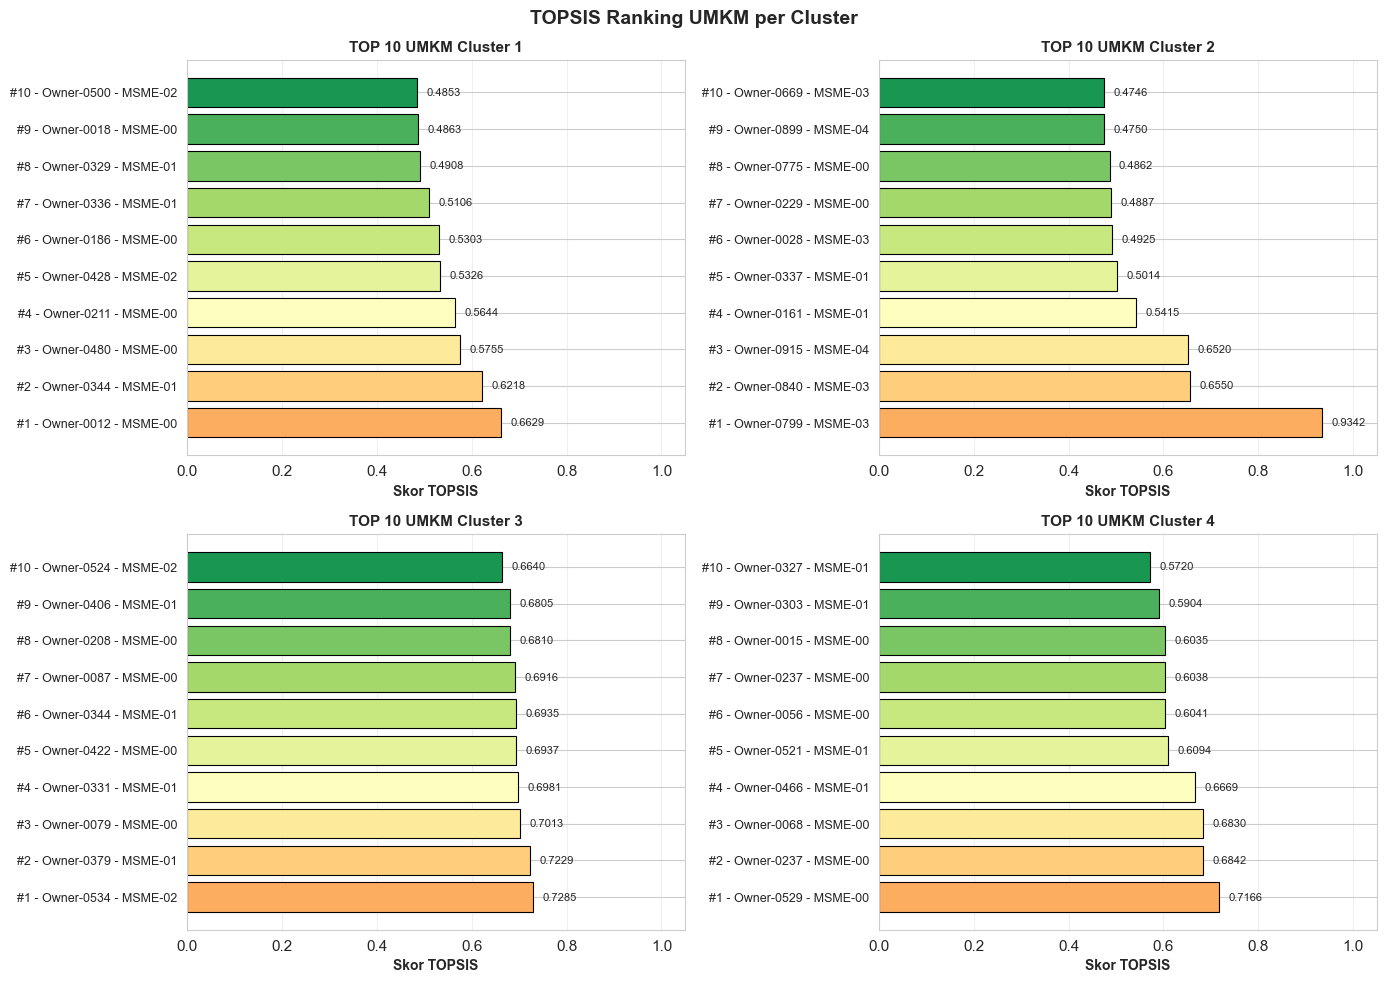

Visualisasi berhasil disimpan: topsis_ranking_per_cluster.png


In [39]:
# ============================================================
# CELL 25: VISUALISASI TOPSIS RANKING PER CLUSTER
# ============================================================

import matplotlib.pyplot as plt

n_clusters = len(topsis_results_per_cluster)

if n_clusters <= 2:
    fig, axes = plt.subplots(1, n_clusters, figsize=(7*n_clusters, 6))
    if n_clusters == 1:
        axes = [axes]
else:
    n_rows = (n_clusters + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5*n_rows))
    axes = axes.flatten()

for plot_idx, cluster_id in enumerate(sorted(topsis_results_per_cluster.keys())):
    df_result = topsis_results_per_cluster[cluster_id]
    ax = axes[plot_idx]
    
    top_n = min(10, len(df_result))
    df_top = df_result.head(top_n).sort_values('skor_topsis', ascending=False)
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_top)))
    bars = ax.barh(range(len(df_top)), df_top['skor_topsis'].values, 
                    color=colors, edgecolor='black', linewidth=0.8)
    
    ax.set_yticks(range(len(df_top)))
    labels = [f"#{int(r)} - {name[:20]}" for r, name in 
              zip(df_top['ranking_topsis'].values, df_top['Identitas_UMKM'].values)]
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Skor TOPSIS', fontsize=10, fontweight='bold')
    ax.set_title(f'TOP {top_n} UMKM Cluster {cluster_id}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='x')
    
    for bar, val in zip(bars, df_top['skor_topsis'].values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
               va='center', fontsize=8)

for idx in range(plot_idx + 1, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('TOPSIS Ranking UMKM per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('topsis_ranking_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualisasi berhasil disimpan: topsis_ranking_per_cluster.png')


In [40]:
# ============================================================
# CELL 26: STATISTIK RINGKAS TOPSIS PER CLUSTER
# ============================================================

print(f'\nSTATISTIK TOPSIS SCORE PER CLUSTER')
print(f'=' * 80)

summary_stats = []

for cluster_id in sorted(topsis_results_per_cluster.keys()):
    df_result = topsis_results_per_cluster[cluster_id]
    scores = df_result['skor_topsis'].values
    
    stats = {
        'Cluster': cluster_id,
        'Jumlah_UMKM': len(df_result),
        'Skor_Min': scores.min(),
        'Skor_Max': scores.max(),
        'Skor_Mean': scores.mean(),
        'Skor_Median': np.median(scores),
        'Skor_Std': scores.std(),
        'Q1': np.percentile(scores, 25),
        'Q3': np.percentile(scores, 75),
    }
    summary_stats.append(stats)

df_summary = pd.DataFrame(summary_stats)
print()
display(df_summary.round(6))

print(f'\nInterpretasi:')
print(f'  - Skor tinggi (0.7-1.0) : UMKM sangat unggul dalam cluster')
print(f'  - Skor sedang (0.5-0.7) : UMKM unggul dalam cluster')
print(f'  - Skor rendah (0.0-0.5) : UMKM perlu peningkatan')



STATISTIK TOPSIS SCORE PER CLUSTER



,Cluster,Jumlah_UMKM,Skor_Min,Skor_Max,Skor_Mean,Skor_Median,Skor_Std,Q1,Q3
0,1,534,0.0196,0.6629,0.2127,0.2100,0.1128,0.1392,0.2659
1,2,145,0.1287,0.9342,0.3661,0.3523,0.0899,0.3085,0.4059
2,3,274,0.0951,0.7285,0.2598,0.2224,0.1329,0.1840,0.2739
3,4,96,0.0523,0.7166,0.2510,0.1860,0.1696,0.1425,0.2889



Interpretasi:
  - Skor tinggi (0.7-1.0) : UMKM sangat unggul dalam cluster
  - Skor sedang (0.5-0.7) : UMKM unggul dalam cluster
  - Skor rendah (0.0-0.5) : UMKM perlu peningkatan


In [41]:
# ============================================================
# CELL 27: INTERPRETASI HASIL TOPSIS
# ============================================================

print(f'''PENJELASAN HASIL RANKING TOPSIS\n
TOPSIS TECHNIQUE FOR ORDER PREFERENCE BY SIMILARITY TO IDEAL SOLUTION\n
Proses TOPSIS untuk ranking UMKM:\n
1. DECISION MATRIX\n
   Data UMKM dalam cluster dengan 4 kriteria (Top-4 berdasarkan EWM)\n
2. NORMALISASI VECTOR\n
   Transformasi data ke skala 0-1 menggunakan Euclidean normalization\n
   Formula: r_ij = x_ij / sqrt(sum(x_ij^2))\n
3. WEIGHTED NORMALIZED MATRIX\n
   Kalikan dengan bobot entropy untuk setiap kriteria\n
   v_ij = w_j * r_ij\n
4. IDEAL SOLUTIONS\n
   - Ideal Positive Solution (A+): nilai maksimum setiap kriteria\n
   - Ideal Negative Solution (A-): nilai minimum setiap kriteria\n
5. SEPARATION MEASURES\n
   Hitung Euclidean distance dari setiap UMKM ke A+ dan A-\n
6. CLOSENESS COEFFICIENT\n
   C_i = D- / (D+ + D-)\n
   Nilai mendekati 1.0 = UMKM ideal (mirip A+)\n
   Nilai mendekati 0.0 = UMKM buruk (mirip A-)\n
7. RANKING\n
   Urutkan UMKM berdasarkan closeness coefficient (descending)\n
INTERPRETASI:\n
─────────────
Skor TOPSIS 0.70-1.00 : UMKM sangat unggul  ✓✓✓\n
Skor TOPSIS 0.50-0.70 : UMKM unggul         ✓✓\n
Skor TOPSIS 0.30-0.50 : UMKM cukup          ✓\n
Skor TOPSIS 0.00-0.30 : UMKM perlu upgrade  ✗\n
KESIMPULAN:\n
───────────
UMKM dengan nilai preferensi TOPSIS tertinggi adalah UMKM paling unggul\n
dalam cluster berdasarkan kombinasi 4 kriteria dengan bobot entropy.\n
Nilai Skor Bobot Entropy yang digunakan:\n
''')

for feat in topsis_features:
    print(f'  {feat:<35} {topsis_weights_norm[feat]:.6f}')

print(f'''\nTOP UMKM di setiap cluster dapat dijadikan BENCHMARK bagi UMKM lainnya\n
dalam cluster yang sama untuk mencapai performance yang lebih baik.''')


PENJELASAN HASIL RANKING TOPSIS

TOPSIS TECHNIQUE FOR ORDER PREFERENCE BY SIMILARITY TO IDEAL SOLUTION

Proses TOPSIS untuk ranking UMKM:

1. DECISION MATRIX

   Data UMKM dalam cluster dengan 4 kriteria (Top-4 berdasarkan EWM)

2. NORMALISASI VECTOR

   Transformasi data ke skala 0-1 menggunakan Euclidean normalization

   Formula: r_ij = x_ij / sqrt(sum(x_ij^2))

3. WEIGHTED NORMALIZED MATRIX

   Kalikan dengan bobot entropy untuk setiap kriteria

   v_ij = w_j * r_ij

4. IDEAL SOLUTIONS

   - Ideal Positive Solution (A+): nilai maksimum setiap kriteria

   - Ideal Negative Solution (A-): nilai minimum setiap kriteria

5. SEPARATION MEASURES

   Hitung Euclidean distance dari setiap UMKM ke A+ dan A-

6. CLOSENESS COEFFICIENT

   C_i = D- / (D+ + D-)

   Nilai mendekati 1.0 = UMKM ideal (mirip A+)

   Nilai mendekati 0.0 = UMKM buruk (mirip A-)

7. RANKING

   Urutkan UMKM berdasarkan closeness coefficient (descending)

INTERPRETASI:

─────────────
Skor TOPSIS 0.70-1.00 : UMKM sangat

## INTERPRETASI HASIL TOPSIS DAN REKOMENDASI

### Memahami Output Detail TOPSIS

#### 1. Matriks Keputusan (Decision Matrix)
Data awal UMKM dengan 4 kriteria sebelum normalisasi. Menunjukkan ukuran masalah:
- Jumlah UMKM (alternatif) di cluster
- Jumlah kriteria yang dievaluasi (selalu 4: Kapasitas, Aset, Omset, Tenaga Kerja)

#### 2. Matriks Normalisasi
Hasil normalisasi vektor untuk membuat skala nilai konsisten (0-1).
- **Rumus**: r_ij = x_ij / sqrt(sum(x_ij^2))
- **Tujuan**: Menghilangkan efek perbedaan unit/skala antar kriteria
- **Range**: Nilai antara 0 dan 1

#### 3. Weighted Normalized Matrix
Matriks normalisasi yang sudah dikalikan dengan bobot entropy setiap kriteria.
- **Rumus**: v_ij = w_j x r_ij
- **w_j**: Bobot relatif pentingnya kriteria j (dari Entropy Weight Method)
- **Tujuan**: Memberikan pengaruh sesuai kontribusi informasi setiap kriteria

#### 4. Solusi Ideal Positif (A+) & Negatif (A-)
Target yang akan dibandingkan dengan setiap UMKM:
- **A+**: Nilai terbaik (max) untuk setiap kriteria pada cluster ini
- **A-**: Nilai terburuk (min) untuk setiap kriteria pada cluster ini
- **Interpretasi**: A+ adalah UMKM ideal, A- adalah UMKM paling bermasalah

#### 5. Jarak ke Solusi Ideal (D+ dan D-)
Pengukuran seberapa jauh UMKM dari solusi ideal:
- **D+**: Jarak Euclidean ke A+ (semakin kecil semakin baik)
- **D-**: Jarak Euclidean ke A- (semakin besar semakin baik)
- **Interpretasi**: UMKM unggul = D+ kecil & D- besar

#### 6. Nilai Preferensi (Closeness Coefficient)
Skor akhir TOPSIS yang digunakan untuk ranking:
- **Rumus**: C_i = D- / (D+ + D-)
- **Range**: 0.0 sampai 1.0
- **Interpretasi**:
  - C_i ~ 1.0: UMKM sangat unggul
  - C_i ~ 0.5: UMKM rata-rata
  - C_i ~ 0.0: UMKM sangat lemah

### Ringkasan Statistik Preferensi
Memberikan gambaran distribusi nilai preferensi dalam cluster:
- **Max**: Nilai tertinggi = UMKM terbaik di cluster
- **Min**: Nilai terendah = UMKM terlemah di cluster
- **Mean**: Rata-rata kualitas UMKM dalam cluster
- **Std Dev**: Variasi kualitas UMKM (semakin besar = semakin beragam)

### Ranking UMKM per Cluster
Urutan final UMKM berdasarkan nilai preferensi:
- **Rank 1**: UMKM dengan preferensi tertinggi (paling unggul)
- **Rank 2-N**: UMKM lainnya secara berurutan
- **Validitas**: Ranking hanya berlaku untuk UMKM dalam cluster yang sama

### Keputusan Manajemen Berdasarkan Hasil

**Untuk UMKM Rank 1-3 (Preferensi > 0.70)**:
- Pertahankan strategi bisnis yang sudah berjalan
- Gunakan sebagai benchmark untuk UMKM lain
- Fokus pada inovasi untuk pertumbuhan lebih lanjut

**Untuk UMKM Rank 4-7 (Preferensi 0.50-0.70)**:
- Identifikasi area untuk improvement
- Belajar dari UMKM dengan rank lebih tinggi
- Fokus pada 1-2 kriteria yang paling tertinggal

**Untuk UMKM Rank > 7 (Preferensi < 0.50)**:
- Perlu evaluasi mendalam terhadap strategi bisnis
- Pertimbangkan restrukturisasi operasional
- Prioritaskan peningkatan pada kriteria terlemah
